# Аттестационный проект: обзор бизнес-показателей маркетплейса

Представлены данные быстрорастущего маркетплейса, который уже нашёл свою нишу, начал приносить прибыль. 
До недавнего времени обходились отчётами в Excel, ориентировались на бухгалтерские сводки и интуицию. Но бизнес растёт, и стало понятно, что нужны настоящие продуктовые данные, системный взгляд и аналитика, которая не просто описывает проект, а развивает его. Команда хочет понять, как чувствует себя продукт: кто приходит, кто остаётся, кто платит, кто уходит. А ещё: на каких каналах держится рост, какие категории товаров приносят деньги, а какие висят мёртвым грузом.

## 1. Данные

Представлено 4 таблицы: информация о пользователях, событиях, заказах и каналах привлечения за 2024 год.


## 2. План проекта                                        

-  Загрузить и предобработать данные.
-  Обзор ключевых метрик.
-  Оценка метрик монетизации и юнит-экономики.
-  Поиск инсайтов, точек роста и сегментация.
  

Главным для "здоровья" продукта является Retention и Activity. Монетизация: Выручка, средний чек, средняя выручка, конверсия, пожизненная ценность клиента. Маркетинговая эффективность: CAC, ROI, PaybackPeriod.

- Retention - процент пользователей, который возвращается к использованию сервиса, продукта.
- Activity - активность клиентов (дневная DAU, недельная WAU, месячная MAU)
- CAC - стоимость привлечения клиента.
- ROI - окупаемость вложений.
- PaybackPeriod - период за который происходит окупаемость.


## 3. Загрузка и предобработка данных

In [1]:
#Загрузка библиотек
import pandas as pd
from scipy.stats import t
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import numpy as np
from scipy import stats as st
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.colors as mcolors
import math
from scipy.stats import bootstrap
from scipy.stats import mannwhitneyu
from IPython.display import display

In [2]:
#Загрузка таблиц
orders = pd.read_csv('______', parse_dates=['order_date', 'order_week', 'order_month'],
                     low_memory=True)
campaign_costs = pd.read_csv('______', parse_dates=['spend_month'],
                    low_memory=False, index_col=0)
users = pd.read_csv('_______', parse_dates=['registration_date', 'cohort_week', 'cohort_month'], 
                    low_memory=True)
events = pd.read_csv('________', parse_dates=['event_date', 'event_week', 'event_month'],
                     low_memory=True)

In [3]:
#Изучение данных датафрейма
def data_overview(df):
    # Вывод первых 5 строк
    display('Первые 5 строк:')
    display(df.head())
    
    # info()
    display('Информация о DataFrame:')
    display(df.info())
    
    # Пропуски абсолютные и относительные
    display('Пропуски:')
    missing = df.isnull().sum()
    display('Абсолютные пропуски:')
    display(missing)
    display('Относительные пропуски:')
    display(missing / len(df) * 100)
    
    # Распределение данных количественных столбцов
    display('Распределение данных количественных столбцов:')
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        display(f'{col}:')
        display(df[col].describe())
    
    # Уникальные значения в категориальных столбцах
    display('Уникальные значения в категориальных столбцах:')
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    for col in categorical_cols:
        display(f'{col}:')
        display(df[col].unique())
    
    # Проверка явных дубликатов
    display('Проверка явных дубликатов:')
    duplicates = df[df.duplicated()]
    if duplicates.empty:
        display('Дубликатов нет.')
    else:
        display('Есть дубликаты:')
        display(duplicates)

In [4]:
# Применение функции для знакомства с orders
# data_overview(orders)

In [5]:
#Проверка дубликатов в столбцах 
duplicates1 = orders[orders.duplicated(subset=['user_id', 'order_date', 'product_name', 'quantity'], keep=False)]
display(duplicates1.head())

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
232,233,203,2024-02-07 22:19:44,Тетрадь общая,1,2829.81,2829.81,Книги и канцтовары,2024-02-05,2024-02-01
233,234,203,2024-02-07 22:19:44,Тетрадь общая,1,2829.81,2829.81,Книги и канцтовары,2024-02-05,2024-02-01
459,460,362,2024-01-26 02:59:13,Свечи зажигания,3,7696.64,23089.92,Автотовары,2024-01-22,2024-01-01
460,461,362,2024-01-26 02:59:13,Свечи зажигания,3,7696.64,23089.92,Автотовары,2024-01-22,2024-01-01
562,563,420,2024-01-13 19:39:50,Чайник электрический,3,6254.47,18763.41,Товары для кухни,2024-01-08,2024-01-01


Были обнаружены неявные дубликаты, задвоенные заказы, под разным order_id. Их необходимо удалить.

In [6]:
#Удвление неявных дубликатов
orders_filtr = orders.drop_duplicates(subset=['user_id', 'order_date', 'product_name', 'quantity'], keep='first', inplace=False).copy()


In [7]:
#Нахождение доли удаленных данных
share = (orders.shape[0] - orders_filtr.shape[0]) / orders.shape[0] * 100
share

0.8610517587779443

Удалила 270 дубликатов из таблицы `orders`, это меньше 1 %.

In [8]:
# Понижение разрядности в столбцах orders 
for column in ['quantity']:
    orders_filtr[column] = orders_filtr[column].fillna(0)
    orders_filtr[column] = pd.to_numeric(orders_filtr[column], errors = 'coerce', downcast='integer')
orders_filtr[['quantity']].dtypes

quantity    int8
dtype: object

In [9]:
# Применение функции для знакомства с campaign_costs
# data_overview(campaign_costs)

In [10]:
#Проверка неявных дубликатов в столбцах 
duplicates2 = campaign_costs[campaign_costs.duplicated(subset=['acq_channel', 'spend_month'], keep=False)]
display(duplicates2)

,acq_channel,spend_month,budget
Unnamed: 0,,,


In [11]:
# Приведение столбца acq_channel к единому стилю
for column in ['acq_channel']:
    campaign_costs[column] = campaign_costs[column].str.lower().str.strip().str.replace(' ', '_') 


In [12]:
# Применение функции для знакомства с users
# data_overview(users)

In [13]:
#Проверка неявных дубликатов в столбцах 
duplicates3 = users[users.duplicated(subset=['user_id', 'registration_date', 'age', 'gender'], keep=False)]
display(duplicates3)

,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month


In [14]:
# Понижение разрядности в столбцах users 
for column in ['age']:
    users[column] = users[column].fillna(0)
    users[column] = pd.to_numeric(users[column], errors = 'coerce', downcast='integer')
users[['age']].dtypes

age    int8
dtype: object

In [15]:
# Приведение столбца acq_channel к единому стилю
for column in ['acq_channel']:
    users[column] = users[column].str.lower().str.strip().str.replace(' ', '_') 


In [16]:
# Применение функции для знакомства с events
# data_overview(events)

In [17]:
# Приведение столбца os к единому стилю
for column in ['os']:
    events[column] = events[column].str.lower().str.strip().str.replace(' ', '_') 


In [18]:
#Проверка неявных дубликатов в столбцах 
duplicates4 = events[events.duplicated(subset=['user_id', 'event_date', 'event_type', 'os', 'device', 'product_name'], keep=False)]
duplicates4.head()

,event_id,user_id,event_date,event_type,os,device,product_name,event_week,event_month
0,3132,100,2024-01-01,page_view,ios,mobile,NaN,2024-01-01,2024-01-01
4,3136,100,2024-01-01,checkout_start,ios,mobile,NaN,2024-01-01,2024-01-01
13,3375,106,2024-01-01,page_view,windows,mobile,NaN,2024-01-01,2024-01-01
25,3176,100,2024-01-01,page_view,ios,mobile,NaN,2024-01-01,2024-01-01
29,3180,100,2024-01-01,checkout_start,ios,mobile,NaN,2024-01-01,2024-01-01


In [19]:
#Удаление неявных дубликатов
events_filtr = events.drop_duplicates(subset=['user_id', 'event_date', 'event_type', 'os', 'product_name'], keep='first', inplace=False).copy()


In [20]:
#Нахождение доли удаленных дубликатов
share_events = (events.shape[0] - events_filtr.shape[0]) / events.shape[0] * 100
share_events

15.553680749345618

Удалила 122 230 дубликата. Составляет 15,55 %.

In [21]:
# Добавление столбца 5% выручки 
orders_filtr['unit_revenue']=round((orders_filtr['unit_price'] * 0.05),2)
orders_filtr['total_revenue']=round((orders_filtr['total_price'] * 0.05),2)


- В таблицах `orders`, `users`, `campaign_costs` отсутствуют пропуски, явные дубликаты, в `events` есть пропуски на определенных событиях, что является нормой.
- Неявные дубликаты были удалены в таблицах `orders` меньше 1 % и `events` 15,55 %.
- Сразу преобразовала столбцы с временными данными в нужный формат.
- Провела предобработку с пониженем разрядности.
- Приведены данные в таблицах `campaign_costs`, `users` в столбцах `acq_channel` и в таблице `events` столбец `os` к единому виду snake case, убранны лишние пробелы.
- Создала столбцы выручки маркетплейса. 

## 4. Обзор ключевых метрик.

Нужно получить целостную картину, оценить текущее состояние — без глубокой сегментации и оценки сложных метрик. Посмотреть на общую динамику ключевых метрик: например, Revenue, ARPU или ARPPU, MAU, WAU, DAU, AOV, Retention, CTR, CR в заказ. Соответствует ли продукт базовым ожиданиям, виден ли рост, есть ли тревожные сигналы. Вывод о динамике основных продуктовых метрик. 

Сразу произведу сравнение по количеству пользователей по таблицам.

In [22]:
#Количество уникальных пользователей в таблице users
users_count = users['user_id'].nunique()
display(users_count)
#Количество уникальных пользователей в таблице events
events_count = events_filtr['user_id'].nunique()
display(events_count)
#Количество уникальных пользователей в таблице order
orders_count = orders_filtr['user_id'].nunique()
display(orders_count)

44151

22138

8922

Посмотрев на уникальных пользователей таблиц, заметно, что половина пользователей не совершает вообще никаких действий после регистрации, больше половины тех пользователей с событий не доходят до покупки. На этом этапе виден большой отток предположительно из-за качества каналов, онбординг, технические сбои. Рассмотрение динамики зарегестрированных пользователей по неделям и месяцам, по дням будет много шума.

### 4.1 Динамика регистраций пользователей.

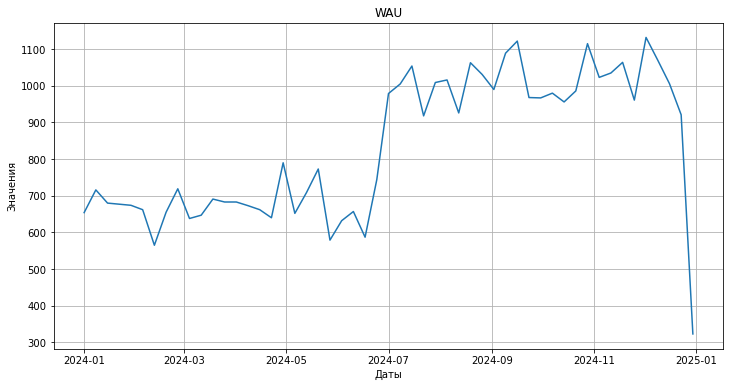

In [23]:
#Расчет WAU по регистраии с приложением 
wau_reg = users.groupby('cohort_week')['user_id'].nunique().reset_index()
# Построение графика в matplotlib
plt.subplots(figsize=(12,6))
plt.plot(wau_reg['cohort_week'], wau_reg['user_id'])
plt.title('WAU')
plt.xlabel('Даты')
plt.ylabel('Значения')
plt.grid()
plt.show()

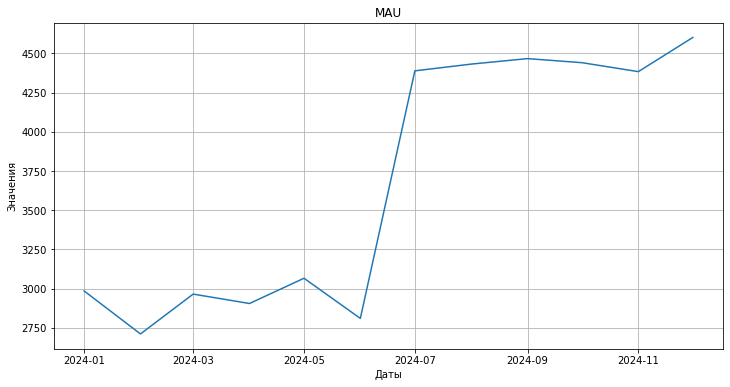

In [24]:
#Расчет MAU по регистраии с приложением 
mau_reg = users.groupby('cohort_month')['user_id'].nunique().reset_index()
# Построение графика в matplotlib
plt.subplots(figsize=(12,6))
plt.plot(mau_reg['cohort_month'], mau_reg['user_id'])
plt.title('MAU')
plt.xlabel('Даты')
plt.ylabel('Значения')
plt.grid()
plt.show()

По регистрации пользователей заметно увеличение количества пользователей, причем резкий скачок в июне, может это была рекламная кампания по привлечению пользователей.

### 4.2 Метрики DAU, WAU и MAU, Stickiness

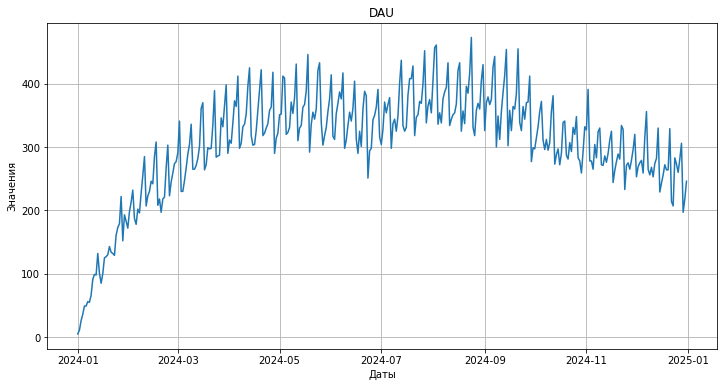

In [25]:
#Расчет DAU по взаимодействию с приложением 
dau = events_filtr.groupby('event_date')['user_id'].nunique().reset_index()
# Построение графика в matplotlib
plt.subplots(figsize=(12,6))
plt.plot(dau['event_date'], dau['user_id'])
plt.title('DAU')
plt.xlabel('Даты')
plt.ylabel('Значения')
plt.grid()
plt.show()

График выглядит очень скачкообразным, поэтому рассмотрение по скользящему среднему.

In [26]:
# Первая дата пользователя 
user_start_dates = (
    events_filtr.groupby('user_id')['event_date']
    .min()
    .reset_index(name='cohort_date')
)
# Количество новых пользователей по дням
users_dynamic = (
    user_start_dates.groupby('cohort_date')['user_id']
    .nunique()
    .reset_index(name='count_users')
)
# Приведение даты
users_dynamic['cohort_date'] = pd.to_datetime(users_dynamic['cohort_date'])

# Добавление календарных дат
users_dynamic = (
    users_dynamic.set_index('cohort_date')
    .asfreq('D', fill_value=0)
    .reset_index()
)
# 7-дневное скользящее среднее
users_dynamic['rolling_users'] = (
    users_dynamic['count_users']
    .rolling(window=7, center=True)
    .mean()
)

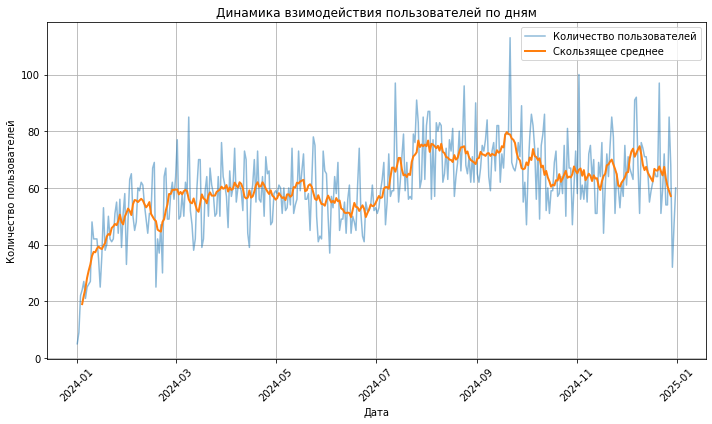

In [27]:
# График
plt.figure(figsize=(10, 6))

plt.plot(
    users_dynamic['cohort_date'],
    users_dynamic['count_users'],
    label='Количество пользователей',
    alpha=0.5
)

plt.plot(
    users_dynamic['cohort_date'],
    users_dynamic['rolling_users'],
    label='Скользящее среднее',
    linewidth=2
)

plt.title('Динамика взимодействия пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Количество пользователей')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

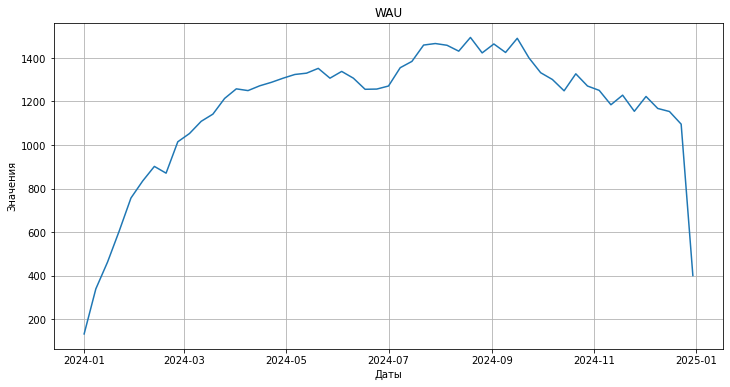

In [28]:
#Расчет WAU по взаимодействию с приложением 
wau = events_filtr.groupby('event_week')['user_id'].nunique().reset_index()
# Построение графика в matplotlib
plt.subplots(figsize=(12,6))
plt.plot(wau['event_week'], wau['user_id'])
plt.title('WAU')
plt.xlabel('Даты')
plt.ylabel('Значения')
plt.grid()
plt.show()

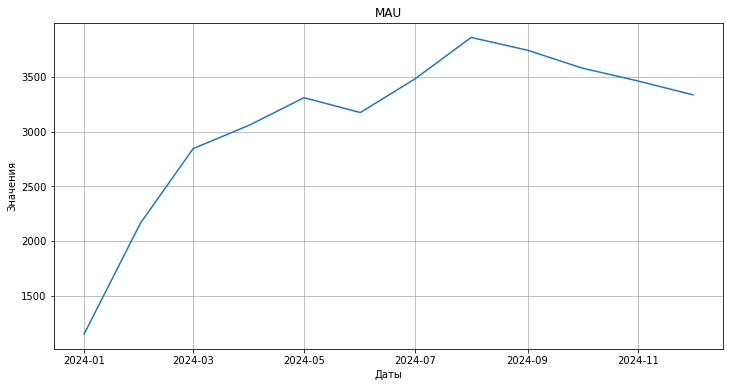

In [29]:
#Расчет MAU по взаимодействию с приложением 
mau = events_filtr.groupby('event_month')['user_id'].nunique().reset_index()
# Построение графика в matplotlib
plt.subplots(figsize=(12,6))
plt.plot(mau['event_month'], mau['user_id'])
plt.title('MAU')
plt.xlabel('Даты')
plt.ylabel('Значения')
plt.grid()
plt.show()

Динамика использования положительная. Скачкообразный DAU показывает пики по выходным, акциям, рассылкам. Скользящий показывает стабильность. Как и по регистрациям видно повышение с июня. 

In [30]:
#Расчет Stickness
dau['event_month'] = dau['event_date'].dt.to_period('M').dt.to_timestamp()
dau_average = dau.groupby('event_month')['user_id'].mean().reset_index()
monthly = pd.merge(dau_average, mau, on='event_month')
monthly['stick'] = (monthly['user_id_x'] / monthly['user_id_y']) * 100
monthly

,event_month,user_id_x,user_id_y,stick
0,2024-01-01,110.129032,1149,9.584772
1,2024-02-01,235.310345,2162,10.883920
2,2024-03-01,302.935484,2844,10.651740
3,2024-04-01,344.733333,3059,11.269478
4,2024-05-01,359.161290,3310,10.850794
5,2024-06-01,343.766667,3174,10.830708
6,2024-07-01,362.903226,3481,10.425258
7,2024-08-01,380.838710,3861,9.863732
8,2024-09-01,363.566667,3744,9.710648
9,2024-10-01,311.000000,3581,8.684725


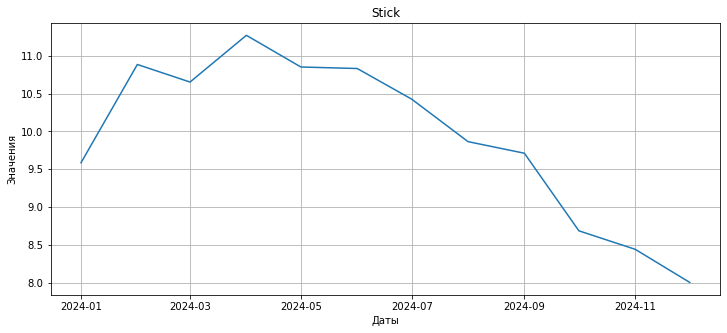

In [31]:
plt.subplots(figsize=(12,5))
plt.plot(monthly['event_month'], monthly['stick'])
plt.title('Stick')
plt.xlabel('Даты')
plt.ylabel('Значения')
plt.grid()
plt.show()

 Месячная аудитория платформы активно расширяется, но ежедневная аудитория стагнирует, что тянет показатель «залипательности» вниз. Необходимо посмотреть на остальные показатели.

### 4.3 Динамика выручки, среднего чека и средней выручки на одного пользователя.

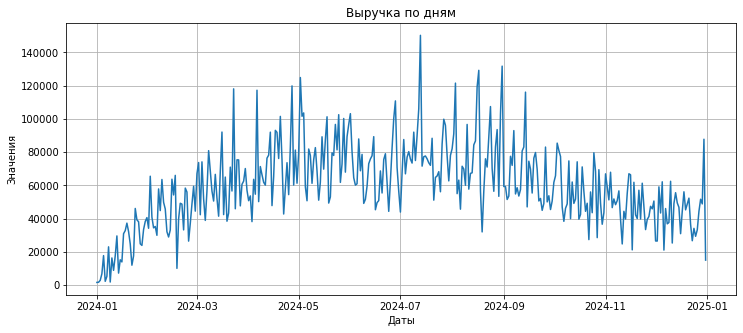

In [32]:
#Расчет выручки по дням 
daily_revenue= orders_filtr.groupby(orders['order_date'].dt.date)['total_revenue'].sum().reset_index()
plt.subplots(figsize=(12,5))
plt.plot(daily_revenue['order_date'], daily_revenue['total_revenue'])
plt.title('Выручка по дням')
plt.xlabel('Даты')
plt.ylabel('Значения')
plt.grid()
plt.show()

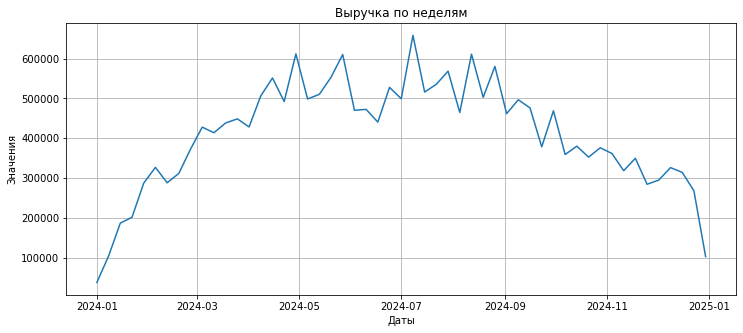

In [33]:
#Расчет выручки по неделям 
weekly_revenue= orders_filtr.groupby('order_week')['total_revenue'].sum().reset_index()
plt.subplots(figsize=(12,5))
plt.plot(weekly_revenue['order_week'], weekly_revenue['total_revenue'])
plt.title('Выручка по неделям')
plt.xlabel('Даты')
plt.ylabel('Значения')
plt.grid()
plt.show()

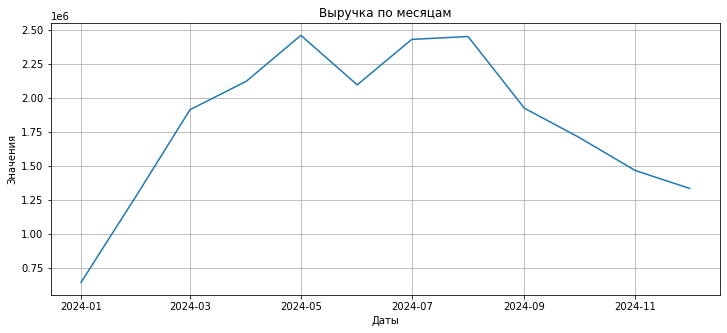

In [34]:
#Расчет выручки по месяцам 
monthly_revenue= orders_filtr.groupby('order_month')['total_revenue'].sum().reset_index()
plt.subplots(figsize=(12,5))
plt.plot(monthly_revenue['order_month'], monthly_revenue['total_revenue'])
plt.title('Выручка по месяцам')
plt.xlabel('Даты')
plt.ylabel('Значения')
plt.grid()
plt.show()

По выручке наблюдается также падение, как и в Stickness. Выручка росла, но начала снижаться. Продукт перешел из фазы роста в фазу стагнации и спада. И снова заметен подъем в июне, но с августа падение.

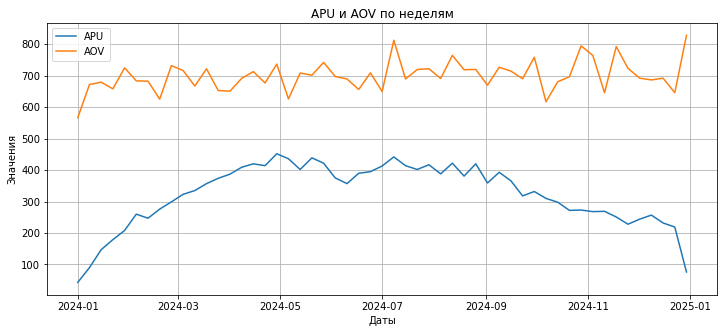

In [35]:
#Расчет AOV и APU по неделям
weekly_aov = orders_filtr.groupby('order_week').agg(
    APU=('user_id','nunique'),
    count_orders = ('order_id', 'nunique'),
    revenue=('total_revenue', 'sum')
).reset_index()
weekly_aov['AOV'] = weekly_aov['revenue']/ weekly_aov['count_orders']
plt.subplots(figsize=(12,5))
plt.plot(weekly_aov['order_week'], weekly_aov['APU'], label='APU')
plt.plot(weekly_aov['order_week'], weekly_aov['AOV'], label='AOV')
plt.title('APU и AOV по неделям')
plt.xlabel('Даты')
plt.ylabel('Значения')
plt.legend()
plt.grid()
plt.show()

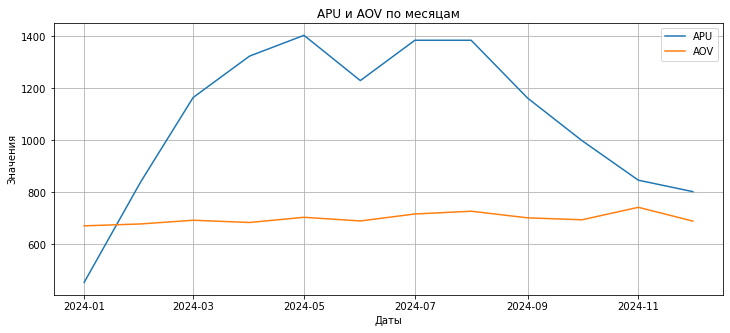

In [36]:
#Расчет AOV и APU по месяцам
monthly_aov = orders_filtr.groupby('order_month').agg(
    APU=('user_id','nunique'),
    count_orders = ('order_id', 'nunique'),
    revenue=('total_revenue', 'sum')
).reset_index()
monthly_aov['AOV'] = monthly_aov['revenue']/ monthly_aov['count_orders']
plt.subplots(figsize=(12,5))
plt.plot(monthly_aov['order_month'], monthly_aov['APU'], label='APU')
plt.plot(monthly_aov['order_month'], monthly_aov['AOV'], label='AOV')
plt.title('APU и AOV по месяцам')
plt.xlabel('Даты')
plt.ylabel('Значения')
plt.legend()
plt.grid()
plt.show()

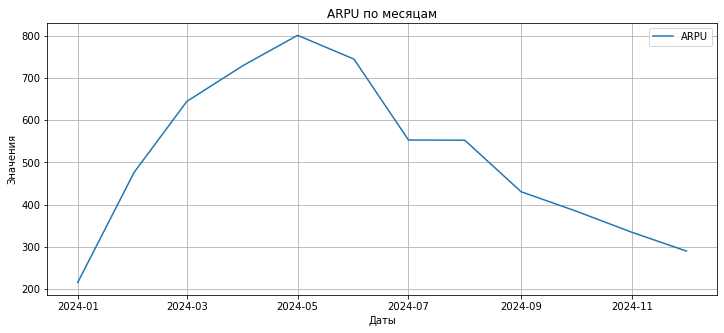

In [37]:
#ARPU расчет
monthy_revenue = pd.merge(monthly_aov, mau_reg, left_on = 'order_month', right_on = 'cohort_month')
monthy_revenue['ARPU'] = monthy_revenue['revenue']/monthy_revenue['user_id']

plt.subplots(figsize=(12,5))
plt.plot(monthy_revenue['order_month'], monthy_revenue['ARPU'], label='ARPU')
plt.title('ARPU по месяцам')
plt.xlabel('Даты')
plt.ylabel('Значения')
plt.legend()
plt.grid()
plt.show()

Показатель платящих пользователей также падает, происходит потеря удержания пользователей. В то время как средняя выручка с пользователя стагнирует. Средняя выручка на одного пользователя (ARPU) также наблюдается падение с мая. 

### 4.4 Удержание пользователей (Retention)

In [38]:
# Фильтр events по событиям
events_filtr_type = events_filtr[events_filtr['event_type']!=('remove_from_cart', 'user_logout')]

In [39]:
# В связи с ошибкой в типе данных, пришлось обратно вернуть int64
events_filtr_type = events_filtr_type.merge(users[['user_id', 'cohort_month']], on='user_id', how='left')


In [40]:
# Группировка данных по cohort_month и event_month
retention=events_filtr_type.groupby(['cohort_month','event_month'])['user_id'].nunique().reset_index()

In [41]:
# Нахождение размера когорты
cohort_size = users.groupby('cohort_month')['user_id'].nunique().to_dict()

In [42]:
# Расчет retention
retention['retention'] = retention.apply(lambda row: row['user_id']/cohort_size.get(row['cohort_month'],1), axis=1)

In [43]:
# Сколько месяцев прошло с начала когорты до текущего события. 
retention['event_month'] = pd.to_datetime(retention['event_month'])
retention['cohort_month'] = pd.to_datetime(retention['cohort_month'])
retention['month_offset'] = retention.apply(lambda row: (row['event_month'].year - row['cohort_month'].year)*12 + 
                                           (row['event_month'].month - row['cohort_month'].month),axis=1)

In [44]:
# Пивотирование таблицы
retention_pivot = retention.pivot_table(
    index='cohort_month',
    columns = 'month_offset',
    values='retention'
)
retention_pivot.round(4)*100

month_offset,0,1,2,3,4,5,6,7,8,9,10,11
cohort_month,,,,,,,,,,,,
2024-01-01,36.92,36.92,17.72,8.17,4.12,1.84,0.87,0.40,0.03,0.07,0.03,0.03
2024-02-01,36.04,40.50,17.89,9.04,4.72,1.84,0.89,0.37,0.11,0.04,0.07,NaN
2024-03-01,37.98,37.61,19.16,9.27,4.28,2.09,0.81,0.27,0.07,0.07,NaN,NaN
2024-04-01,38.45,39.31,19.38,9.36,4.82,2.27,1.07,0.69,0.31,NaN,NaN,NaN
2024-05-01,37.25,36.92,17.19,7.73,3.62,1.63,0.46,0.23,NaN,NaN,NaN,NaN
2024-06-01,33.49,34.31,17.01,7.62,3.77,1.78,0.53,NaN,NaN,NaN,NaN,NaN
2024-07-01,32.00,32.75,14.88,7.09,3.56,1.28,NaN,NaN,NaN,NaN,NaN,NaN
2024-08-01,31.10,30.17,14.20,7.45,3.27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-01,27.54,28.53,13.95,5.71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


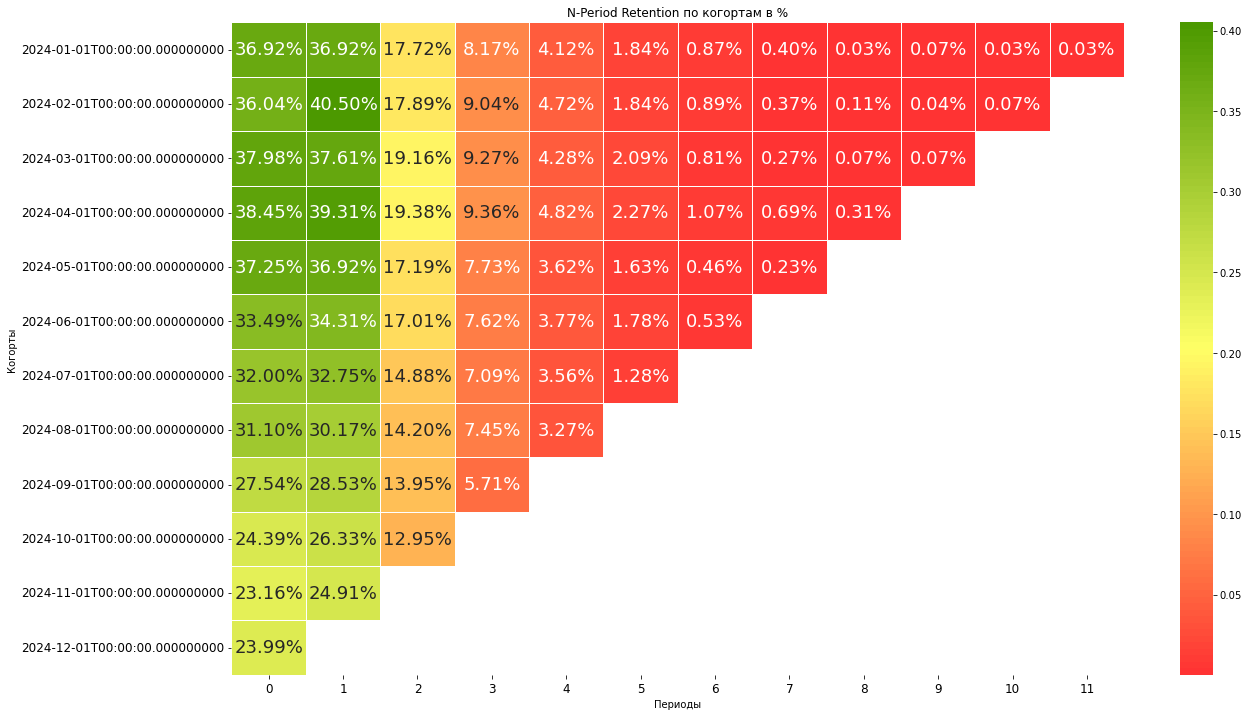

In [45]:
cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900'], N=100)
plt.subplots(figsize=(20,12))
sns.heatmap(retention_pivot,
            cmap=cmap,
            annot=True,
            fmt='.2%',
            linewidth=0.5,
            annot_kws={"size": 18})

# Остальные параметры совпадают с линейными графиками на matplotlib
plt.title('N-Period Retention по когортам в %')
plt.xlabel('Периоды')
plt.ylabel('Когорты')
plt.yticks(rotation=0)
plt.tick_params(labelsize=12) # чтобы сделать подписи данных на оси Y (когорты пользователей) немного крупнее
plt.show()

Видно системное, прогрессирующее падение удержания. Значения крайне низкие. Эти показатели причина падения APU и выручки во втором полугодии. 

### 4.5 Конверсия

In [46]:
#Активные пользователи
active_users_week = events_filtr.groupby('event_week')['user_id'].nunique().reset_index()
active_users_week.columns = ['week','active_users']
#Платящие пользователи
paying_users_week = orders_filtr.groupby('order_week')['user_id'].nunique().reset_index()
paying_users_week.columns = ['week','paying_users']
#Нахождение конверсии
conversion_week = pd.merge(active_users_week, paying_users_week, on='week', how='left')
conversion_week['CR'] = conversion_week['paying_users']/conversion_week['active_users'] * 100
conversion_week.head()

,week,active_users,paying_users,CR
0,2024-01-01,133,43,32.330827
1,2024-01-08,340,90,26.470588
2,2024-01-15,463,147,31.749460
3,2024-01-22,606,179,29.537954
4,2024-01-29,757,208,27.476882


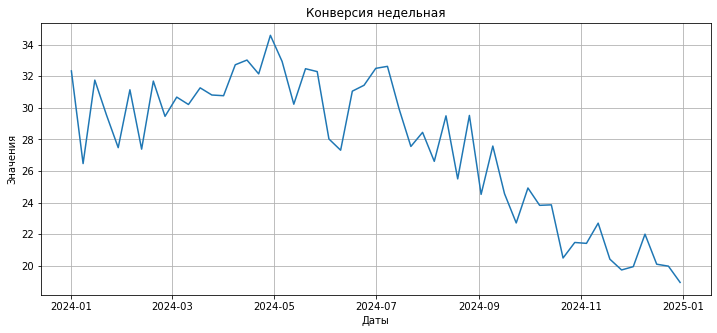

In [47]:
plt.subplots(figsize=(12,5))
plt.plot(conversion_week['week'], conversion_week['CR'])
plt.title('Конверсия недельная')
plt.xlabel('Даты')
plt.ylabel('Значения')
plt.grid()
plt.show()

In [48]:
#Активные пользователи
active_users = events_filtr.groupby('event_month')['user_id'].nunique().reset_index()
active_users.columns = ['month','active_users']
#Платящие пользователи
paying_users = orders_filtr.groupby('order_month')['user_id'].nunique().reset_index()
paying_users.columns = ['month','paying_users']
#Нахождение конверсии
conversion = pd.merge(active_users, paying_users, on='month', how='left')
conversion['CR'] = conversion['paying_users']/conversion['active_users'] * 100
conversion

,month,active_users,paying_users,CR
0,2024-01-01,1149,454,39.512620
1,2024-02-01,2162,839,38.806660
2,2024-03-01,2844,1165,40.963432
3,2024-04-01,3059,1324,43.282118
4,2024-05-01,3310,1404,42.416918
5,2024-06-01,3174,1230,38.752363
6,2024-07-01,3481,1385,39.787417
7,2024-08-01,3861,1385,35.871536
8,2024-09-01,3744,1163,31.063034
9,2024-10-01,3581,999,27.897235


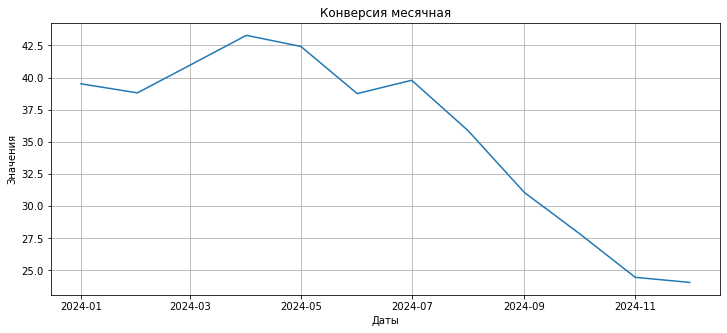

In [49]:
plt.subplots(figsize=(12,5))
plt.plot(conversion['month'], conversion['CR'])
plt.title('Конверсия месячная')
plt.xlabel('Даты')
plt.ylabel('Значения')
plt.grid()
plt.show()

По конверсиям также можно судить, что активность в покупку сильно падает. В июне по динамике регистраций было замечено увеличение пользователей, в конверсиях виден скачок небольшой в этот период, но позже падение.

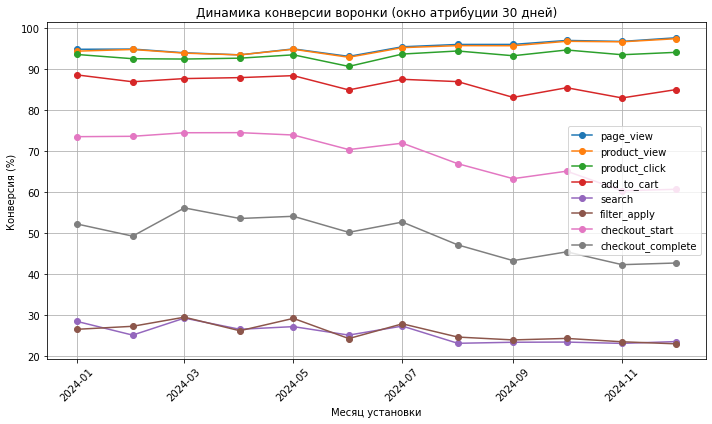

In [50]:
attribution_window = 30

events_filtr_type['diff_days'] = (events_filtr_type['event_month'] - events_filtr_type['cohort_month']).dt.days
events_filtr_type = events_filtr_type[events_filtr_type['diff_days'].between(0, attribution_window)]

event_list = ['page_view', 'product_view', 'product_click', 'add_to_cart', 'search', 'filter_apply', 'checkout_start', 'checkout_complete']
funnel_dynamic = events_filtr_type.groupby('event_month')['user_id'].nunique().reset_index(name='count_user')
plt.figure(figsize=(10, 6))
for event in event_list:
    df_event = events_filtr_type[events_filtr_type['event_type'] == event]
    df_event = df_event.groupby('event_month')['user_id'].nunique().reset_index(name=event)
    funnel_dynamic = funnel_dynamic.merge(df_event, on='event_month', how='left')
    funnel_dynamic[event] = (funnel_dynamic[event] / funnel_dynamic['count_user']) * 100
    plt.plot(funnel_dynamic['event_month'], funnel_dynamic[event], marker='o', label=event)
    
plt.title('Динамика конверсии воронки (окно атрибуции 30 дней)')
plt.xlabel('Месяц установки')
plt.ylabel('Конверсия (%)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


По динамике конверсии наблюдается крайне низкое использование поиска и фильтров. Это мешает эффективно находить нужные товары, что приводит к снижению конверсии в покупку, падание удержания и выручки. 

По всем метрикам заметно, что в начале года идет рост, но к осени и далее идет понижение всех показателей. Происходит потеря способности удержания новых пользователей. Сократилось число платящих пользователей, падение выручки, средний чек стабилен. ARPU снижается, так как активные пользователи перестают покупать. Обнаружен факт с низкой конверсией событий фильтра и поиска.

## 5. Оценка метрик монетизации и юнит-экономики

Необходимо провести анализ монетизации. Определить, сколько зарабатывает продукт и сколько тратит на привлечение. 
Важны как агрегированные метрики (ARPU, AOV), так и показатели эффективности (CAC, ROI, Payback Period).
Сформулируйте первые выводы по результатам анализа метрик. Сделайте это в формате записки для заказчика. Изложите все основные результаты так, чтобы прослеживалась связь между мыслями. Не пишите много — заказчик не будет читать записку полностью, а просто просмотрит. 
Напишите выводы в конце блока, чтобы заказчик мог быстро ознакомиться с основными результатами. 

### 5.1 Средний чек, средняя выручка на одного пользователя, LTV.

In [51]:
#Нахождение количества пользователей в когортах
cohort_sizes = users.groupby('cohort_month')['user_id'].nunique().reset_index(name='reg_users')

# Объединяние заказов и пользователей
df = pd.merge(users[['user_id', 'cohort_month']], orders_filtr[['user_id', 'order_id', 'order_month', 'total_revenue']], how='inner')

# Расчет lifetime 
df['lifetime'] = (df['order_month'].dt.year - df['cohort_month'].dt.year) * 12 + (df['order_month'].dt.month - df['cohort_month'].dt.month)

# Расчет чистой выручки когорты по lifetime
cohort_revenue = df.groupby(['cohort_month', 'lifetime']).agg(
        total_revenue=('total_revenue', 'sum'),
        total_orders=('order_id', 'nunique')  
    ).reset_index()

# Добавление к выручке изначальный размер когорты
df_grouped = pd.merge(cohort_revenue, cohort_sizes, on='cohort_month', how='left')

# Расчет AOV, ARPU и кумулятивный LTV
df_grouped['AOV'] = df_grouped['total_revenue'] / df_grouped['total_orders']
df_grouped['ARPU'] = df_grouped['total_revenue'] / df_grouped['reg_users']
df_grouped['LTV'] = df_grouped.groupby('cohort_month')['ARPU'].cumsum()
df_grouped.head()

,cohort_month,lifetime,total_revenue,total_orders,reg_users,AOV,ARPU,LTV
0,2024-01-01,0,617256.79,923,2985,668.750585,206.786194,206.786194
1,2024-01-01,1,691854.32,1061,2985,652.077587,231.776992,438.563186
2,2024-01-01,2,412043.67,556,2985,741.085737,138.038080,576.601266
3,2024-01-01,3,147712.34,257,2985,574.756187,49.484871,626.086137
4,2024-01-01,4,153252.42,148,2985,1035.489324,51.340844,677.426982


In [52]:
# pivot для среднего чека по когортам и периодам
df_pivot_aov = df_grouped.pivot_table( index='cohort_month', columns='lifetime', values='AOV')

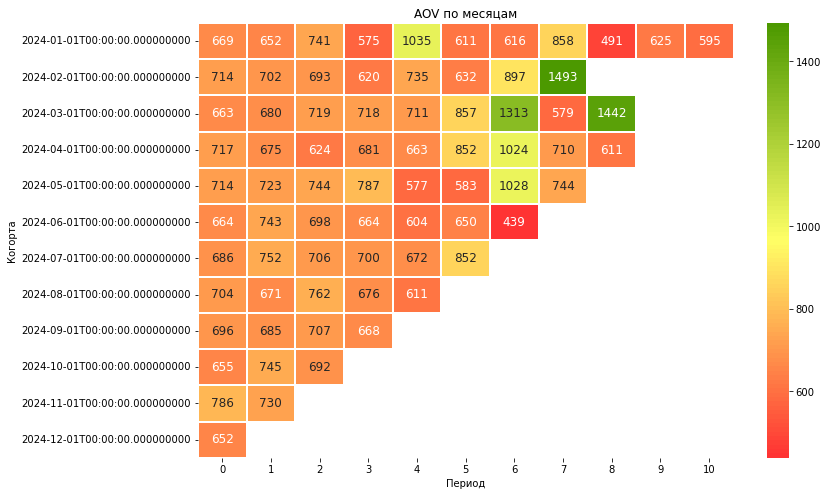

In [53]:
# Создание графика
plt.figure(figsize=(12, 8))

# Построение heatmap AOV с палитрой
sns.heatmap(df_pivot_aov,
          cmap=cmap,
          annot=True,
          fmt='.0f',
          linewidths=2,
          annot_kws={"size": 12})

# Добавление заголовка
plt.title('AOV по месяцам')

# Добавление подписи осей
plt.xlabel('Период')
plt.ylabel('Когорта')
plt.show()

Средний чек остается стабильным. Наблюдаются выбросы, где средний чек до 1500. Значит падение выручки не связано с удешевлением, а связано со снижением количества покупателей. 

In [54]:
# pivot для суммарной выручки по когортам и периодам
df_pivot_arpu = df_grouped.pivot_table( index='cohort_month', columns='lifetime', values='ARPU')

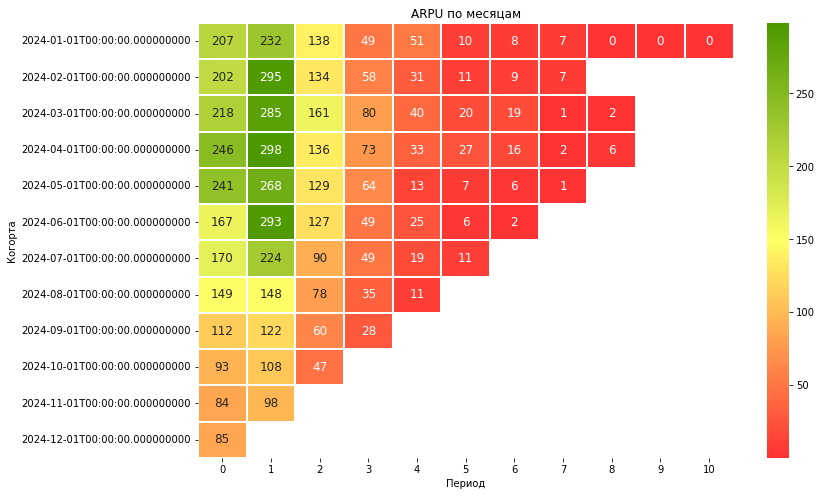

In [55]:
# Создание графика
plt.figure(figsize=(12, 8))

# Построение heatmap ARPPU с палитрой
sns.heatmap(df_pivot_arpu,
          cmap=cmap,
          annot=True,
          fmt='.0f',
          linewidths=2,
          annot_kws={"size": 12})

# Добавление заголовка
plt.title('ARPU по месяцам')

# Добавление подписи осей
plt.xlabel('Период')
plt.ylabel('Когорта')
plt.show()

Средний доход на одного привлеченного пользователя устойчиво снижается, особенно для когорт с июня. Это и видно по Retention, снижение конверсии в покупку. Приток новых пользователей не приводит к росту дохода, они не совершают покупки. 

### 5.2 CAC, ROI, PaybackPeriod

In [56]:
#Создание таблицы CAC
cac = (campaign_costs
       .groupby('spend_month')['budget'].sum().reset_index()
       .merge(df_grouped,
              left_on=['spend_month'],
              right_on=['cohort_month'], how='inner')
       .assign(CAC = lambda x: x['budget']/x['reg_users'])
      )
cac.head()

,spend_month,budget,cohort_month,lifetime,total_revenue,total_orders,reg_users,AOV,ARPU,LTV,CAC
0,2024-01-01,1.177457e+06,2024-01-01,0,617256.79,923,2985,668.750585,206.786194,206.786194,394.457945
1,2024-01-01,1.177457e+06,2024-01-01,1,691854.32,1061,2985,652.077587,231.776992,438.563186,394.457945
2,2024-01-01,1.177457e+06,2024-01-01,2,412043.67,556,2985,741.085737,138.038080,576.601266,394.457945
3,2024-01-01,1.177457e+06,2024-01-01,3,147712.34,257,2985,574.756187,49.484871,626.086137,394.457945
4,2024-01-01,1.177457e+06,2024-01-01,4,153252.42,148,2985,1035.489324,51.340844,677.426982,394.457945


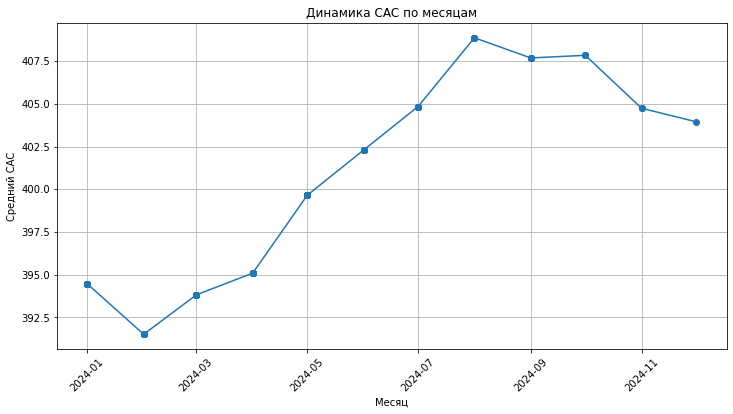

In [57]:
# Построение графика
plt.figure(figsize=(12, 6))
plt.plot(cac['cohort_month'], cac['CAC'], marker='o')
plt.xticks(rotation=45)
plt.xlabel('Месяц')
plt.ylabel('Средний CAC')
plt.title('Динамика CAC по месяцам')
plt.grid(True)
plt.show()

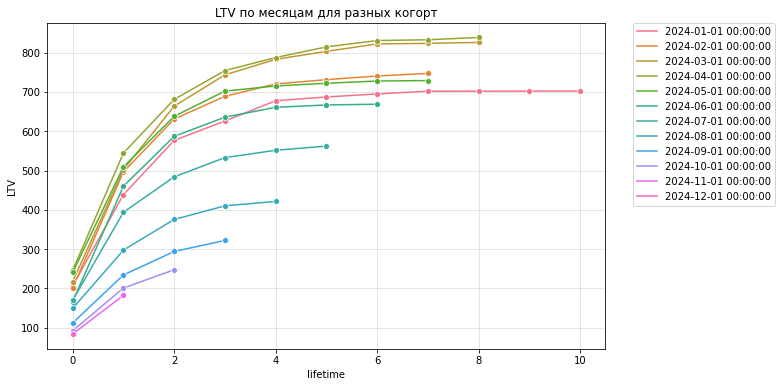

In [58]:
plt.figure(figsize=(10, 6))
# Построение линейного графика с маркерами
sns.lineplot(
        data=cac,
        x='lifetime',
        y='LTV',
        hue='cohort_month',
        marker='o'
    )
# Дополнительные параметры для лучшего отображения графиков
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

# Добавление заголовка
plt.title(f'LTV по месяцам для разных когорт')

# Добавление названия осей
plt.xlabel('lifetime')
plt.ylabel('LTV')

# Добавление полупрозрачной сетки
plt.grid(alpha=.4)
plt.show()

In [59]:
#Расчет ROI
cac['ROI'] = (cac['LTV']-cac['CAC'])/cac['CAC'] * 100

Для лучшей визуализации возьмем 4 когорты: '2024-01-01' - самую раннюю, '2024-04-01' - пик активности, '2024-07-01' - следующая когорта после падения retention, '2024-10-01' - убыточность.

In [60]:
# Словарь с когортами и соответствующими им цветами
first_months_colors = {'2024-01-01': 'blue', '2024-04-01': 'red', '2024-07-01': 'green', '2024-10-01': 'purple'}
# Создаём график
plt.figure(figsize=(10, 6))

<Figure size 720x432 with 0 Axes>

<Figure size 720x432 with 0 Axes>

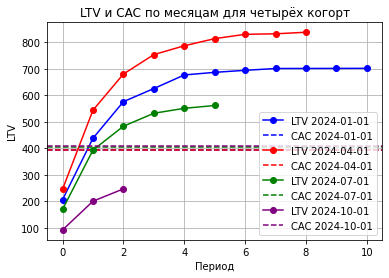

In [61]:
# Построение линий для каждой когорты
for month, color in first_months_colors.items():
    # Создание отфильтрованного датафрейма для текущей когорты
    df_plot = cac[cac['cohort_month']==month]
 
    # Построение LTV с цветом из словаря
    plt.plot(
        df_plot['lifetime'],
        df_plot['LTV'],
        color=color,
        marker='o',
        label=f'LTV {month}'
    )

    # Построение линий для CAC с тем же цветом
    cac_value = df_plot['CAC'].mean()
    plt.axhline(
        y=cac_value,
        color=color,
        linestyle='--',
        label=f'CAC {month}'
    )

# Добавление заголовка
plt.title('LTV и CAC по месяцам для четырёх когорт')

# Добавление подписи осей
plt.xlabel('Период')
plt.ylabel('LTV')

# Добавление легенды
plt.legend()

# Добавление сетки
plt.grid(True)
plt.show()

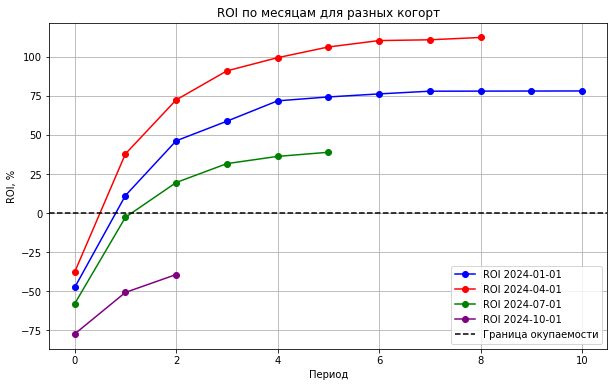

In [62]:
# Создание графика
plt.figure(figsize=(10, 6))

# Построение линий для каждой когорты
for month, color in first_months_colors.items():
    # Создание промежуточного отфильтрованного датафрейма для текущей когорты
    df_plot = cac[cac['cohort_month']==month]

    # Построение динамики ROI по периодам с цветами из словаря
    plt.plot(
        df_plot['lifetime'],
        df_plot['ROI'],
        color=color,
        marker='o',
        label=f'ROI {month}'
    )

# Добавление горизонтальной линий — границы окупаемости
plt.axhline(y=0, color='black', linestyle='--', label='Граница окупаемости')


# Добавление заголовка
plt.title('ROI по месяцам для разных когорт')

# Добавление подписи осей
plt.xlabel('Период')
plt.ylabel('ROI, %')

# Добавление легенды
plt.legend()

# Добавление сетки
plt.grid(True)
plt.show()

Анализ подтверждает ухудшение юнит_экономики. CAC растет, LTV и ROI со второго полугодия снижается 
- Для когорт второй половины года наблюдается снижение LTV, вырос CAC. Графики подтверждают, что LTV поздних когорт падает.
- Срок окупаемости июльской когорты выше, чем у январской. Точка пересечения LTV и CAC январской когорты расположена левее, что указывает на более короткий период окупаемости по сравнению с июльской. Октябрьская находится еще ниже с позиции окупаемости.
- По январской после 6 месяцев наблюдается стагнация.


In [63]:
# Для каждой когорты, периода среднее значение LTV и CAC
df_payback = cac.groupby(['cohort_month','lifetime'])[['LTV', 'CAC']].mean().reset_index()
df_payback.head()

,cohort_month,lifetime,LTV,CAC
0,2024-01-01,0,206.786194,394.457945
1,2024-01-01,1,438.563186,394.457945
2,2024-01-01,2,576.601266,394.457945
3,2024-01-01,3,626.086137,394.457945
4,2024-01-01,4,677.426982,394.457945


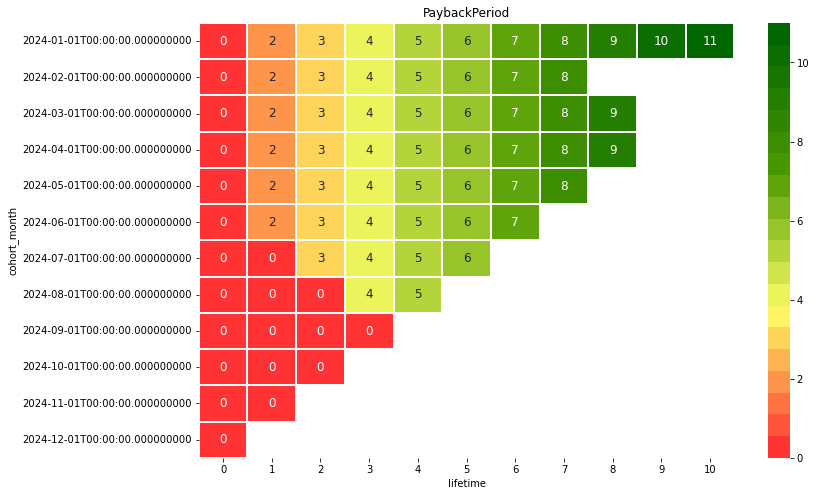

In [64]:
# Расчет Payback Period
df_payback['Payback_Period'] = df_payback.apply(
  lambda row: row['lifetime'] + 1 if row['LTV'] >= row['CAC'] else 0, axis=1)

# Пивотирование данных, чтобы cohort_month были индексами, а lifetime — столбцами
df_pivot = df_payback.pivot(index='cohort_month', columns='lifetime', values='Payback_Period')
cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900', '#006600'], N=20)

# Построение heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(df_pivot,
          cmap=cmap,
          annot=True,
          fmt='.0f',
          linewidths=2,
          annot_kws={"size": 12})


plt.title('PaybackPeriod')
plt.xlabel('lifetime')
plt.ylabel('cohort_month')
plt.show()

Анализ Payback Period подтвеждает резкое ухудшение во втором полугодии. Когорты первого полугодия окупались в 1-2 месяца жизни, начиная с июльской с 3-4 месяца, а с сентября оупаемость отсутствует. Маркетинговые затраты перестали окупаться. 

Вывод:
- Средний чек стабилен.
- Средний доход на всех привлеченных пользователей резко снижается. Пользователи привлеченные во втором полугодии, приносят меньше выручки.
- LTV падает, пользователи приносят меньше денег за свой жизненный цикл. Это заметно и в конверсии, и в удержании.
- CAC остается высоким, а качество привлеченного трафика ухудшилось.
- ROI для ранних когорт положителен. А вот во втором полугодии наблюдается отрицательный. Маркетинговые инвестиции перестали окупаться.
- Payback Period ухудшение. Продукт перестал возвращать вложенные средства в те сроки, что были у ранних когорт.

Причина падения показателей в конверсии, удержании. 

## 6. Поиск инсайтов, точек роста и сегментация

Посмотрите вглубь данных: по каналам, сегментам пользователей, категориям товаров, регионам, типам устройств.
Ищите закономерности, различия, аномалии.
Цель — сформировать обоснованные гипотезы:
- какие сегменты работают лучше остальных,
- какие сегменты работают хуже остальных,
- на каких этапах воронки теряются пользователи,
- какие группы можно или нужно масштабировать,
- куда стоит инвестировать больше внимания или ресурсов.
  
По итогам анализа также:
сформулируйте в виде аналитической записки выводы,
сформулируйте несколько гипотез, которые помогут развить продукт.   
Например, «Если предлагать клиентам на ios персонализированные скидки, то они станут чаще конвертировать в продукт».
При формулировании гипотез опишите, на что вы опираетесь при её формировании. Например, на динамику метрики или на взаимосвязь метрик.

### 6.1 По сегментам

В таблице `users` пользователи разделены на сегменты столбик `buyer_segment`: 'regular', 'rare', 'one_time', 'medium'. Зметила, что во всех сегментах есть пользователи, которые не совершали покупки. Истории этих данных не знаю, с заказчиком не обсудить, решила оставить как есть. Была идея вручную категоризировать данные.

In [65]:
# Объединяние заказов и пользователей
df_segment = pd.merge(users[['user_id', 'cohort_month', 'buyer_segment']], 
                      orders_filtr[['user_id', 'order_id', 'order_month', 'total_revenue']], on='user_id', how='left')
df_segment.head()

,user_id,cohort_month,buyer_segment,order_id,order_month,total_revenue
0,1,2024-01-01,regular,NaN,NaT,NaN
1,2,2024-01-01,rare,NaN,NaT,NaN
2,3,2024-01-01,regular,1.0,2024-01-01,553.91
3,3,2024-01-01,regular,2.0,2024-01-01,567.02
4,3,2024-01-01,regular,3.0,2024-01-01,1089.21


In [66]:
#Нахождение количества пользователей в когортах
segment_sizes = df_segment.groupby(['cohort_month', 'buyer_segment'])['user_id'].nunique().reset_index(name='reg_users')

# Расчет lifetime 
df_segment['lifetime'] = (df_segment['order_month'].dt.year - df_segment['cohort_month'].dt.year) * 12 + (df_segment['order_month'].dt.month - df_segment['cohort_month'].dt.month)

# Расчет чистой выручки когорты по lifetime
segment_revenue = df_segment.groupby(['cohort_month', 'buyer_segment', 'lifetime']).agg(
        total_revenue=('total_revenue', 'sum'),
        total_orders=('order_id', 'nunique')  
    ).reset_index()

# Добавление к выручке изначальный размер когорты
df_grouped_segment = pd.merge(segment_revenue, segment_sizes, on=['cohort_month', 'buyer_segment'], how='left')

# Расчет AOV, ARPU и кумулятивный LTV
df_grouped_segment['AOV'] = df_grouped_segment['total_revenue'] / df_grouped_segment['total_orders']
df_grouped_segment['ARPU'] = df_grouped_segment['total_revenue'] / df_grouped_segment['reg_users']
df_grouped_segment['LTV'] = df_grouped_segment.groupby(['cohort_month','buyer_segment'])['ARPU'].cumsum()
df_grouped_segment.head()

,cohort_month,buyer_segment,lifetime,total_revenue,total_orders,reg_users,AOV,ARPU,LTV
0,2024-01-01,medium,0.0,191767.99,256,1119,749.093711,171.374433,171.374433
1,2024-01-01,medium,1.0,160014.43,255,1119,627.507569,142.997703,314.372136
2,2024-01-01,medium,2.0,97334.62,130,1119,748.727846,86.983575,401.355710
3,2024-01-01,medium,3.0,50027.69,92,1119,543.779239,44.707498,446.063208
4,2024-01-01,medium,4.0,28139.22,32,1119,879.350625,25.146756,471.209964


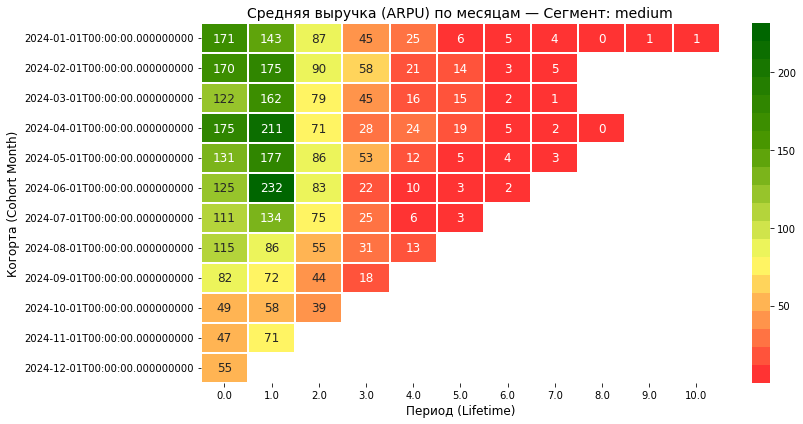

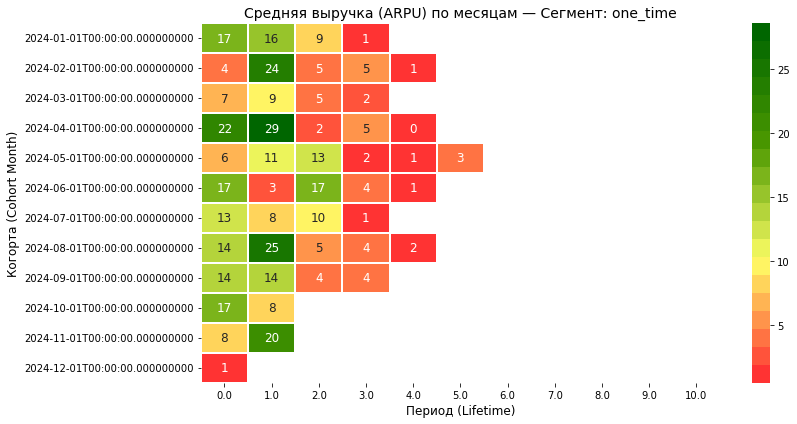

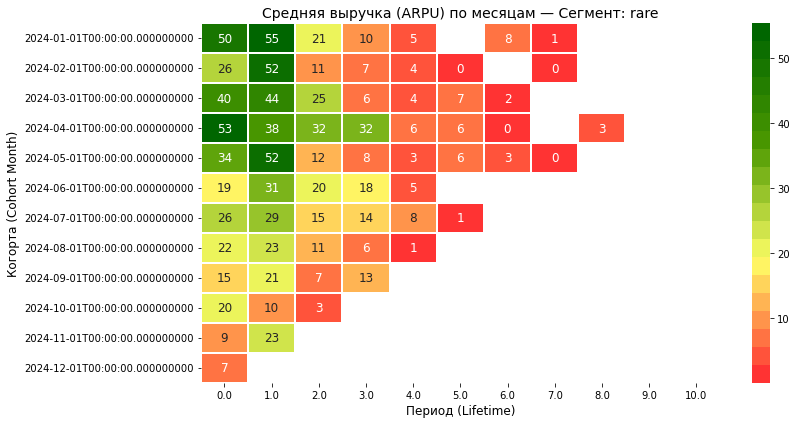

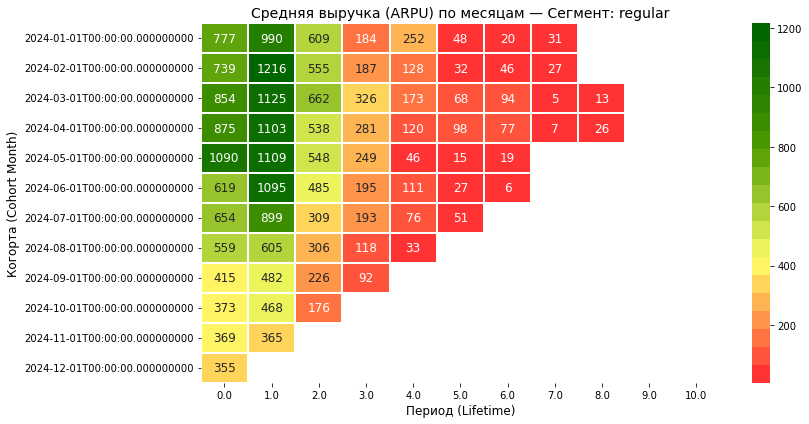

In [67]:
df_pivot_arpu = df_grouped_segment.pivot_table(index=['buyer_segment', 'cohort_month'], columns='lifetime', values='ARPU')

# Список всех уникальных сегментов
segments = df_grouped_segment['buyer_segment'].unique()

# В цикле отдельный heatmap для каждого сегмента
for segment in segments:
    plt.figure(figsize=(12, 6))

    # Фильтруем данные сводной таблицы по конкретному сегменту
    # cross-section (xs) вытаскивает срез по первому уровню индекса
    segment_pivot = df_pivot_arpu.xs(segment, level='buyer_segment')

    # Построение heatmap ARPU с палитрой
    sns.heatmap(
        segment_pivot,
        cmap=cmap, 
        annot=True,
        fmt='.0f',
        linewidths=2,
        annot_kws={'size': 12},
    )

    # Заголовки динамически под каждый сегмент
    plt.title(f'Средняя выручка (ARPU) по месяцам — Сегмент: {segment}', fontsize=14)
    plt.xlabel('Период (Lifetime)', fontsize=12)
    plt.ylabel('Когорта (Cohort Month)', fontsize=12)

    plt.tight_layout()
    plt.show()

- В сегменте `medium` наблюдается падение средней выручки когорт на 3 месяц, а также во втором полугодии. Июньская когорта во втором месяце показывает подъем, но позже все же снижение. 
- В сегменте `one_time` пользователи совершили одну покупку, не приносят дополнительной выручки после первого заказа.
- В сегменте `rare` пользователи приносят низкую среднюю выручку.
- Самый ценнный сегмент `regular` показывает снижение в поздних когортах.
ARPU держался на группе `regular`, но даже их ценность резко снижается для поздних когорт. Все остальные не окупают затраты. 


In [68]:
#Создание таблицы CAC
cac_segment = (campaign_costs
       .groupby('spend_month')['budget'].sum().reset_index()
       .merge(df_grouped_segment,
              left_on=['spend_month'],
              right_on=['cohort_month'], how='inner')
       .assign(CAC = lambda x: x['budget']/x['reg_users'])
      )
#Расчет ROI
cac_segment['ROI'] = (cac_segment['LTV']-cac_segment['CAC'])/cac_segment['CAC'] * 100
cac_segment.head()

,spend_month,budget,cohort_month,buyer_segment,lifetime,total_revenue,total_orders,reg_users,AOV,ARPU,LTV,CAC,ROI
0,2024-01-01,1.177457e+06,2024-01-01,medium,0.0,191767.99,256,1119,749.093711,171.374433,171.374433,1052.240363,-83.713376
1,2024-01-01,1.177457e+06,2024-01-01,medium,1.0,160014.43,255,1119,627.507569,142.997703,314.372136,1052.240363,-70.123543
2,2024-01-01,1.177457e+06,2024-01-01,medium,2.0,97334.62,130,1119,748.727846,86.983575,401.355710,1052.240363,-61.857031
3,2024-01-01,1.177457e+06,2024-01-01,medium,3.0,50027.69,92,1119,543.779239,44.707498,446.063208,1052.240363,-57.608240
4,2024-01-01,1.177457e+06,2024-01-01,medium,4.0,28139.22,32,1119,879.350625,25.146756,471.209964,1052.240363,-55.218410


In [69]:
# Словарь с когортами и соответствующими им цветами
first_months_colors = {'2024-01-01': 'blue', '2024-04-01': 'red', '2024-07-01': 'green', '2024-10-01': 'purple'}
# Создаём график
plt.figure(figsize=(10, 6))

<Figure size 720x432 with 0 Axes>

<Figure size 720x432 with 0 Axes>

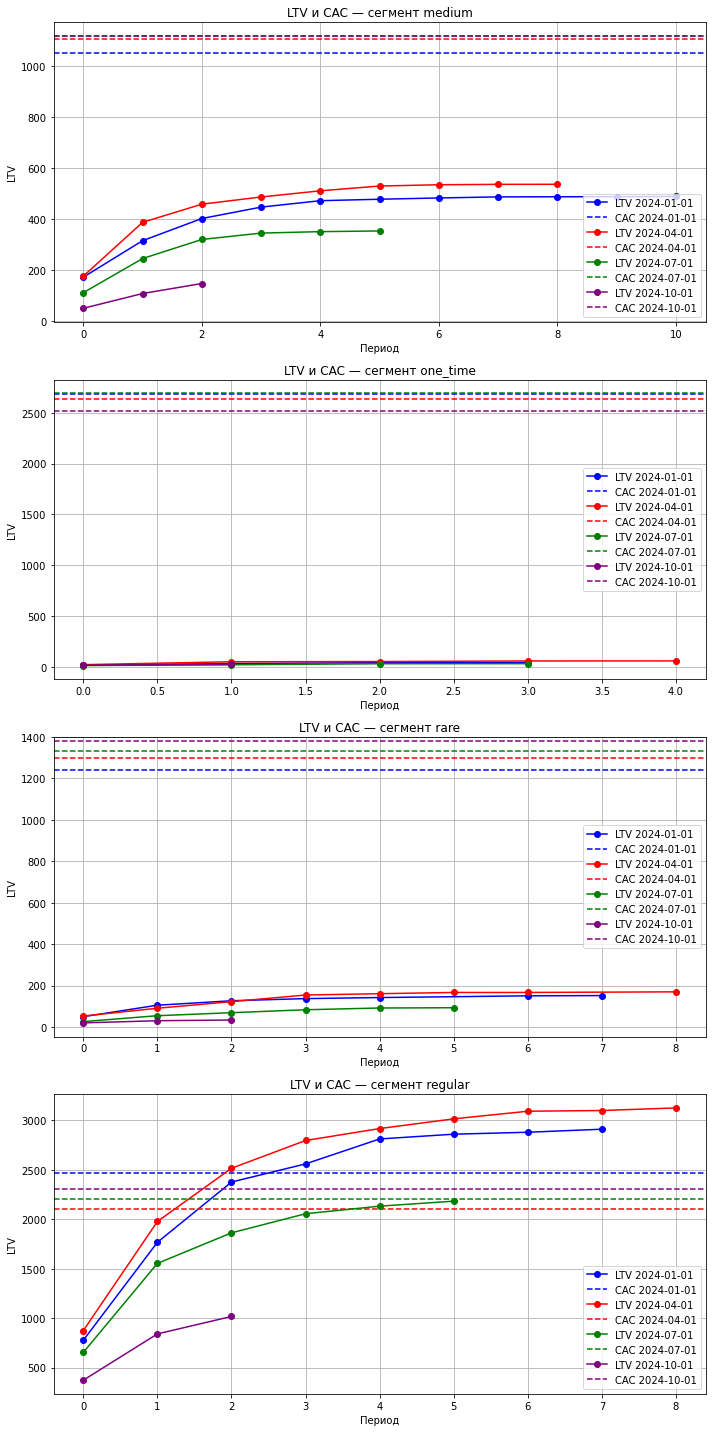

In [70]:
# Список сегментов, которые хотим отобразить
segments = cac_segment['buyer_segment'].unique()  

# Сетка: количество строк = количеству сегментов, 1 столбец
fig, axes = plt.subplots(len(segments), 1, figsize=(10, 5 * len(segments)))

# Если сегментов один, axes может быть не массивом — оборачиваем в список для единообразия
if len(segments) == 1:
    axes = [axes]

# Цикл по сегментам
for idx, segment in enumerate(segments):
    ax = axes[idx]  # текущий подграфик
    
    # Фильтр данных по сегменту
    cac_segment_filtered = cac_segment[cac_segment['buyer_segment'] == segment]
    
    # Цикл по когортам внутри сегмента
    for month, color in first_months_colors.items():
        # Фильтр по когорте
        df_plot = cac_segment_filtered[cac_segment_filtered['cohort_month'] == month]
        
        # Построение LTV
        ax.plot(
            df_plot['lifetime'],
            df_plot['LTV'],
            color=color,
            marker='o',
            label=f'LTV {month}'
        )
        
        # Построение CAC — горизонтальная линия
        cac_value = df_plot['CAC'].mean()
        ax.axhline(
            y=cac_value,
            color=color,
            linestyle='--',
            label=f'CAC {month}'
        )
    
    # Настройка каждого подграфика
    ax.set_title(f'LTV и CAC — сегмент {segment}')
    ax.set_xlabel('Период')
    ax.set_ylabel('LTV')
    ax.legend()
    ax.grid(True)

# Графики
plt.tight_layout()  # автоматическая подгонка отступов
plt.show()

LTV превышает стоимость CAC только в сегменте регулярных покупателей и в ранних когортах. Это наблюдалось и в показателе ARPU.  

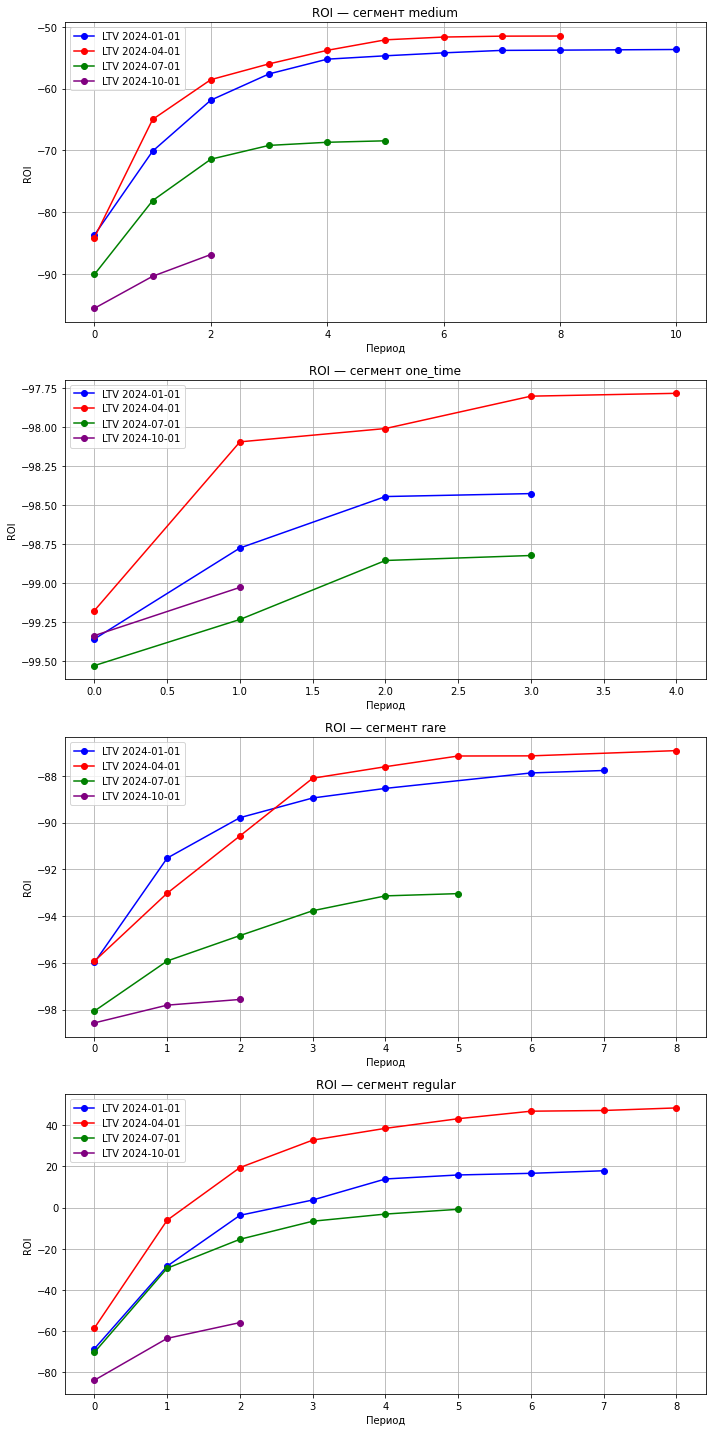

In [71]:
# Список сегментов, которые хотим отобразить
segments = cac_segment['buyer_segment'].unique()  

# Создаём сетку: количество строк = количеству сегментов, 1 столбец
fig, axes = plt.subplots(len(segments), 1, figsize=(10, 5 * len(segments)))

# Если сегментов один, axes может быть не массивом — оборачиваем в список для единообразия
if len(segments) == 1:
    axes = [axes]

# Цикл по сегментам
for idx, segment in enumerate(segments):
    ax = axes[idx]  # текущий подграфик
    
    # Фильтруем данные по сегменту
    cac_segment_filtered = cac_segment[cac_segment['buyer_segment'] == segment]
    
    # Цикл по когортам внутри сегмента
    for month, color in first_months_colors.items():
        # Фильтруем по когорте
        df_plot = cac_segment_filtered[cac_segment_filtered['cohort_month'] == month]
        
        # Строим ROI
        ax.plot(
            df_plot['lifetime'],
            df_plot['ROI'],
            color=color,
            marker='o',
            label=f'LTV {month}'
        )
        
           # Настройка каждого подграфика
    ax.set_title(f'ROI — сегмент {segment}')
    ax.set_xlabel('Период')
    ax.set_ylabel('ROI')
    ax.legend()
    ax.grid(True)

# Показываем все графики
plt.tight_layout()  # автоматическая подгонка отступов
plt.show()

ROI в плюсе только в сегменте `regular`, остальные сегменты не окупаются. 

В связи с тем, что не понятен порядок шагов пользователя, события могут совершаться хаотично, сначала считала с добавлением регистрации, но не понятно на каком этапе это происходит. Приняла решение убрать совсем этот шаг из воронки. Одна из гипотез: Если стандартизировать путь пользователя, сделав регистрацию обязательным шагом перед оформлением заказа, подсказать следующий шаг пользователю, то конверсия в оплаченный заказ вырастет.

In [72]:
# Создание события покупки
purchases = orders_filtr[['user_id', 'order_month']].copy()  

# Переименование колонки с временем, чтобы она совпадала с таблицей событий
purchases = purchases.rename(columns={'order_month': 'event_month'})

# Добавление колонки с названием события
purchases['event_type'] = 'purchase'

# из events_filtr только нужные для воронки колонки
events_short = events_filtr[['user_id', 'event_month', 'event_type']]

# Склейка таблицы 
df_all_events = pd.concat([events_short, purchases], ignore_index=True)

df_funnel = df_all_events.merge(
    users[['user_id', 'cohort_month', 'buyer_segment']], 
    on='user_id', 
    how='left'
)
df_funnel.head()

,user_id,event_month,event_type,cohort_month,buyer_segment
0,100,2024-01-01,page_view,2024-01-01,regular
1,100,2024-01-01,product_view,2024-01-01,regular
2,100,2024-01-01,product_click,2024-01-01,regular
3,100,2024-01-01,add_to_cart,2024-01-01,regular
4,100,2024-01-01,checkout_start,2024-01-01,regular


In [73]:
funnel_steps = ['page_view', 'product_view', 'add_to_cart', 'checkout_start', 'checkout_complete', 'purchase']

In [74]:
# Фильтрация только нужных шагов 
df_funnel_step_segment = df_funnel[df_funnel['event_type'].isin(funnel_steps)]
df_funnel_step_segment.head()

,user_id,event_month,event_type,cohort_month,buyer_segment
0,100,2024-01-01,page_view,2024-01-01,regular
1,100,2024-01-01,product_view,2024-01-01,regular
3,100,2024-01-01,add_to_cart,2024-01-01,regular
4,100,2024-01-01,checkout_start,2024-01-01,regular
5,33,2024-01-01,page_view,2024-01-01,rare


In [75]:
# Пустой словарь для хранения результатов по каждого сегмента
segment_funnels_dict = {}

# Запускаем цикл по всем уникальным сегментам
for segment_name in df_funnel_step_segment['buyer_segment'].unique():
    
    # 1. Фильтруем данные строго по текущей ОС и делаем явную копию (.copy())
    df_segment_table = df_funnel_step_segment[df_funnel_step_segment['buyer_segment'] == segment_name].copy()
    
    # 2. Считаем уникальных пользователей на каждом шаге
    df_segment_steps = (
        df_segment_table.groupby('event_type')['user_id']
        .nunique()
        .reindex(funnel_steps)
        .reset_index(name='users_n')
    )
           
    # 3. Считаем конверсию от первого шага (записываем в df_os_steps!)
    df_segment_steps['conversion_from_first_%'] = round(
        (df_segment_steps['users_n'] / df_segment_steps.loc[0, 'users_n'] * 100), 2
    )
    
    # 4. Считаем пошаговую конверсию (step-by-step) (записываем в df_os_steps!)
    df_segment_steps['conversion_from_previous_%'] = round(
        (df_segment_steps['users_n'] / df_segment_steps['users_n'].shift(1) * 100), 2
    )
       
    # Добавим колонку с именем ОС, чтобы в итоговой таблице было понятно, чья это воронка
    df_segment_steps['buyer_segment'] = segment_name
    
    # 5. Сохраняем получившийся агрегированный датафрейм в словарь
    segment_funnels_dict[segment_name] = df_segment_steps
    
# Соединяем все рассчитанные воронки вместе
df_final_funnel_segment = pd.concat(segment_funnels_dict.values(), ignore_index=True)

# Выводим результат на экран
df_final_funnel_segment

,event_type,users_n,conversion_from_first_%,conversion_from_previous_%,buyer_segment
0,page_view,5326.0,100.00,NaN,regular
1,product_view,5324.0,99.96,99.96,regular
2,add_to_cart,5161.0,96.90,96.94,regular
3,checkout_start,4730.0,88.81,91.65,regular
4,checkout_complete,4295.0,80.64,90.80,regular
5,purchase,3716.0,69.77,86.52,regular
6,page_view,5589.0,100.00,NaN,rare
7,product_view,5575.0,99.75,99.75,rare
8,add_to_cart,4934.0,88.28,88.50,rare
9,checkout_start,3608.0,64.56,73.13,rare


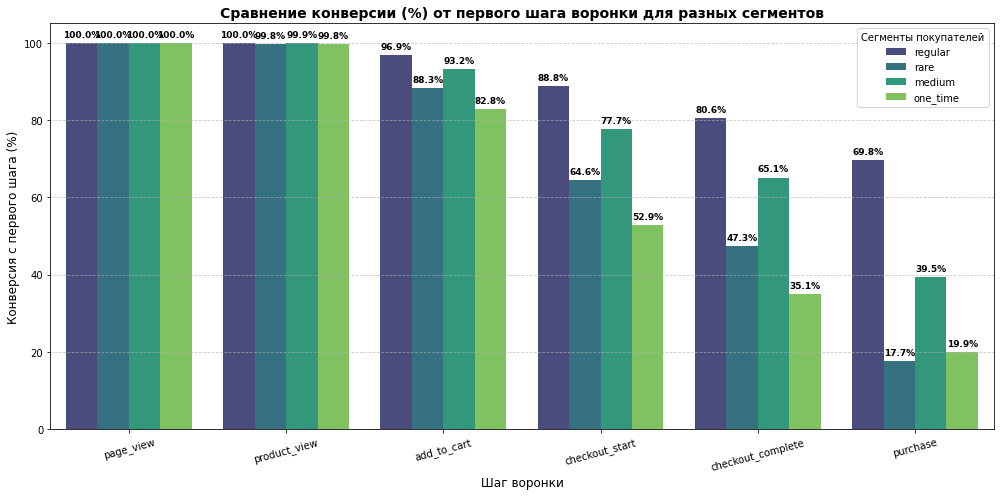

In [76]:
plt.figure(figsize=(14, 7))

# Столбчатая диаграмма от первого шага
ax = sns.barplot(
    data=df_final_funnel_segment,
    x='event_type',
    y='conversion_from_first_%',
    hue='buyer_segment',            
    palette='viridis'    # Цветовая схема
)

plt.title('Сравнение конверсии (%) от первого шага воронки для разных сегментов', fontsize=14, fontweight='bold')
plt.xlabel('Шаг воронки', fontsize=12)
plt.ylabel('Конверсия с первого шага (%)', fontsize=12)
plt.xticks(rotation=15) 
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.legend(title='Сегменты покупателей')

# Добавление подписей
rects = [rect for rect in ax.get_children() if isinstance(rect, plt.Rectangle)][:-1]

for i, rect in enumerate(rects):
    v = rect.get_height()
    x = rect.get_x() + rect.get_width() / 2  # находим точный центр столбика  
    
    if 0 < v <= 100:
        plt.text(x, v + 1, f"{v:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

- Для самых лояльных пользователей `regular` конверсия в оплату составляет 69,8 %. Сильгое падение в шаге покупка.
- У сегмента `rare` ниже конверсия на всех этапах воронки, особенно заметно от корзины к оформлению и внутри оформления. Конверсия в оплату сильно уступает реглярным пользователям и даже одноразовому сегменту 17,7%.
- Конверсия сегмента `medium` на шагах ниже, чем у сегмента `regular`, но выше `rare`. Потери начиная с начала оформления заказа, покупка 39,5 %.
- В одноразовом сегменте самая низкая конверсия на всех этапах воронки - добавление в корзину и переход к оформлению. Но конверсия в покупку 19,9 %. Судя по LTV они дешевые и небольшие. 

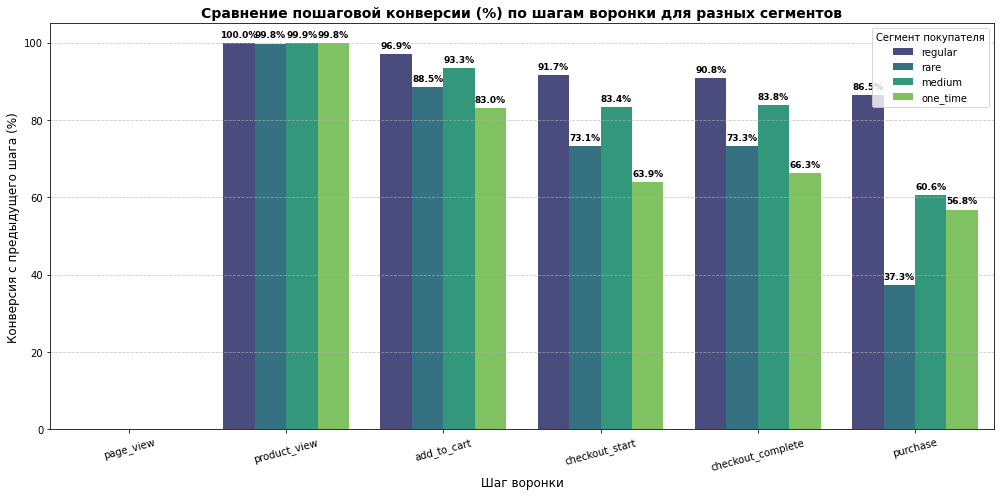

In [77]:
plt.figure(figsize=(14, 7))

# Построение графика
ax = sns.barplot(
    data=df_final_funnel_segment,
    x='event_type',
    y='conversion_from_previous_%',
    hue='buyer_segment',            
    palette='viridis'   
)

plt.title('Сравнение пошаговой конверсии (%) по шагам воронки для разных сегментов', fontsize=14, fontweight='bold')
plt.xlabel('Шаг воронки', fontsize=12)
plt.ylabel('Конверсия с предыдущего шага (%)', fontsize=12)
plt.xticks(rotation=15) 
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.legend(title='Сегмент покупателя')

# Добавление подписей
rects = [rect for rect in ax.get_children() if isinstance(rect, plt.Rectangle)][:-1]

for i, rect in enumerate(rects):
    v = rect.get_height()
    x = rect.get_x() + rect.get_width() / 2  # находим точный центр столбика  
    
    if 0 < v <= 100:
        plt.text(x, v + 1, f"{v:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')
        
plt.tight_layout()
plt.show()

- Для самых лояльных пользователей `regular` конверсия в оплату составляет 86,5 %. Не наблюдаются резкие падения на других шагах.
- У сегмента `rare` ниже конверсия на всех этапах воронки, особенно заметно от корзины к оформлению и внутри оформления. Редкие покупатели менее зантересованы, реже добавляют товары в корзину. Конверсия в оплату сильно уступает реглярным пользователям.
- Конверсия сегмента `medium` на шагах ниже, чем у сегмента `regular`, но выше `rare`. Потеря сильная заметна в конверсии покупка.
- В массовом сегменте низкая конверсия на всех этапах воронки - добавление в корзину и переход к оформлению. Судя по LTV они дешевые и небольшие. 

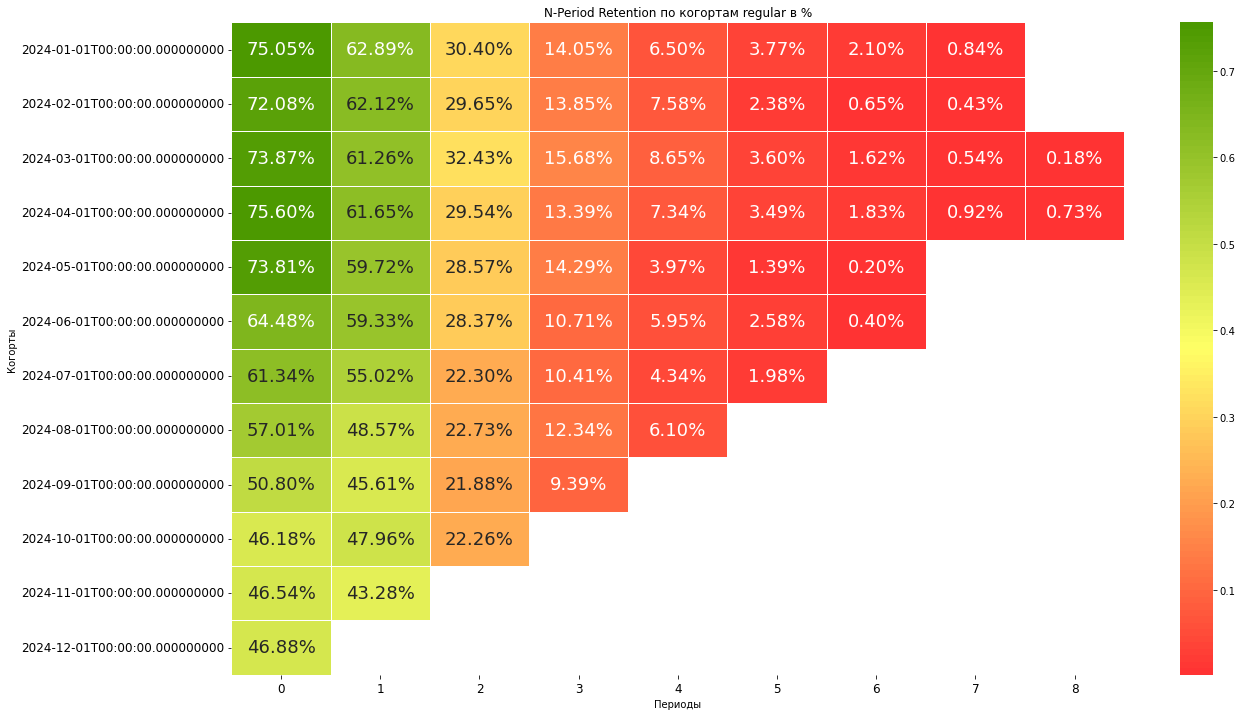

In [78]:
df_retention_regular=df_funnel[df_funnel['buyer_segment'] == 'regular']
#Группировка данных по cohort_month и event_month
retention_regular=df_retention_regular.groupby(['cohort_month','event_month'])['user_id'].nunique().reset_index()
#Нахождение размера когорты
cohort_size = users[users['buyer_segment']=='regular'].groupby('cohort_month')['user_id'].nunique().to_dict()
#Расчет retention
retention_regular['retention'] = retention_regular.apply(lambda row: row['user_id']/cohort_size.get(row['cohort_month'],1), axis=1)
#Сколько месяцев прошло с начала когорты до текущего события. 
retention_regular['event_month'] = pd.to_datetime(retention_regular['event_month'])
retention_regular['cohort_month'] = pd.to_datetime(retention_regular['cohort_month'])
retention_regular['month_offset'] = retention_regular.apply(lambda row: (row['event_month'].year - row['cohort_month'].year)*12 + 
                                           (row['event_month'].month - row['cohort_month'].month),axis=1)
#Пивотирование таблицы
retention_pivot = retention_regular.pivot_table(
    index='cohort_month',
    columns = 'month_offset',
    values='retention'
)
retention_pivot.round(4)*100


cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900'], N=100)
plt.subplots(figsize=(20,12))
sns.heatmap(retention_pivot,
            cmap=cmap,
            annot=True,
            fmt='.2%',
            linewidth=0.5,
            annot_kws={"size": 18})

# Остальные параметры совпадают с линейными графиками на matplotlib
plt.title('N-Period Retention по когортам regular в %')
plt.xlabel('Периоды')
plt.ylabel('Когорты')
plt.yticks(rotation=0)
plt.tick_params(labelsize=12) # чтобы сделать подписи данных на оси Y (когорты пользователей) немного крупнее
plt.show()

Анализ удержания показывает устойчивое ухудшение показателей для когорт, привлеченных после мая. к 3-4 месяцу Retention падает до 10-20%. Это является ключевой причиной падения LTV. Поздние когорты реже становятся регулярными, регулярные пользователи стали менее лояльными и активными. 

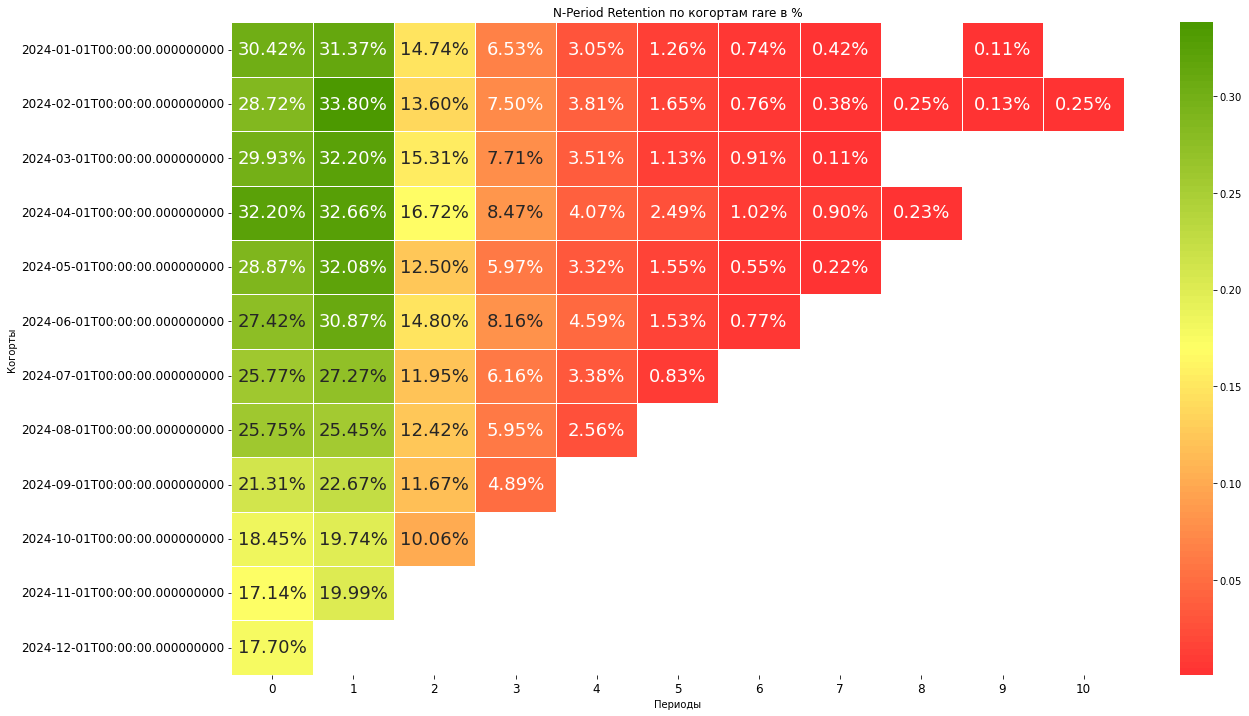

In [79]:
df_retention_rare=df_funnel[df_funnel['buyer_segment'] == 'rare']
#Группировка данных по cohort_month и event_month
retention_rare=df_retention_rare.groupby(['cohort_month','event_month'])['user_id'].nunique().reset_index()
#Нахождение размера когорты
cohort_size = users[users['buyer_segment']=='rare'].groupby('cohort_month')['user_id'].nunique().to_dict()
#Расчет retention
retention_rare['retention'] = retention_rare.apply(lambda row: row['user_id']/cohort_size.get(row['cohort_month'],1), axis=1)
#Сколько месяцев прошло с начала когорты до текущего события. 
retention_rare['event_month'] = pd.to_datetime(retention_rare['event_month'])
retention_rare['cohort_month'] = pd.to_datetime(retention_rare['cohort_month'])
retention_rare['month_offset'] = retention_rare.apply(lambda row: (row['event_month'].year - row['cohort_month'].year)*12 + 
                                           (row['event_month'].month - row['cohort_month'].month),axis=1)
#Пивотирование таблицы
retention_pivot = retention_rare.pivot_table(
    index='cohort_month',
    columns = 'month_offset',
    values='retention'
)
retention_pivot.round(4)*100


cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900'], N=100)
plt.subplots(figsize=(20,12))
sns.heatmap(retention_pivot,
            cmap=cmap,
            annot=True,
            fmt='.2%',
            linewidth=0.5,
            annot_kws={"size": 18})

# Остальные параметры совпадают с линейными графиками на matplotlib
plt.title('N-Period Retention по когортам rare в %')
plt.xlabel('Периоды')
plt.ylabel('Когорты')
plt.yticks(rotation=0)
plt.tick_params(labelsize=12) # чтобы сделать подписи данных на оси Y (когорты пользователей) немного крупнее
plt.show()

Удержание крайне низкое, еще и ухудшается для поздних групп. Поздние когорты еще менее активны. 

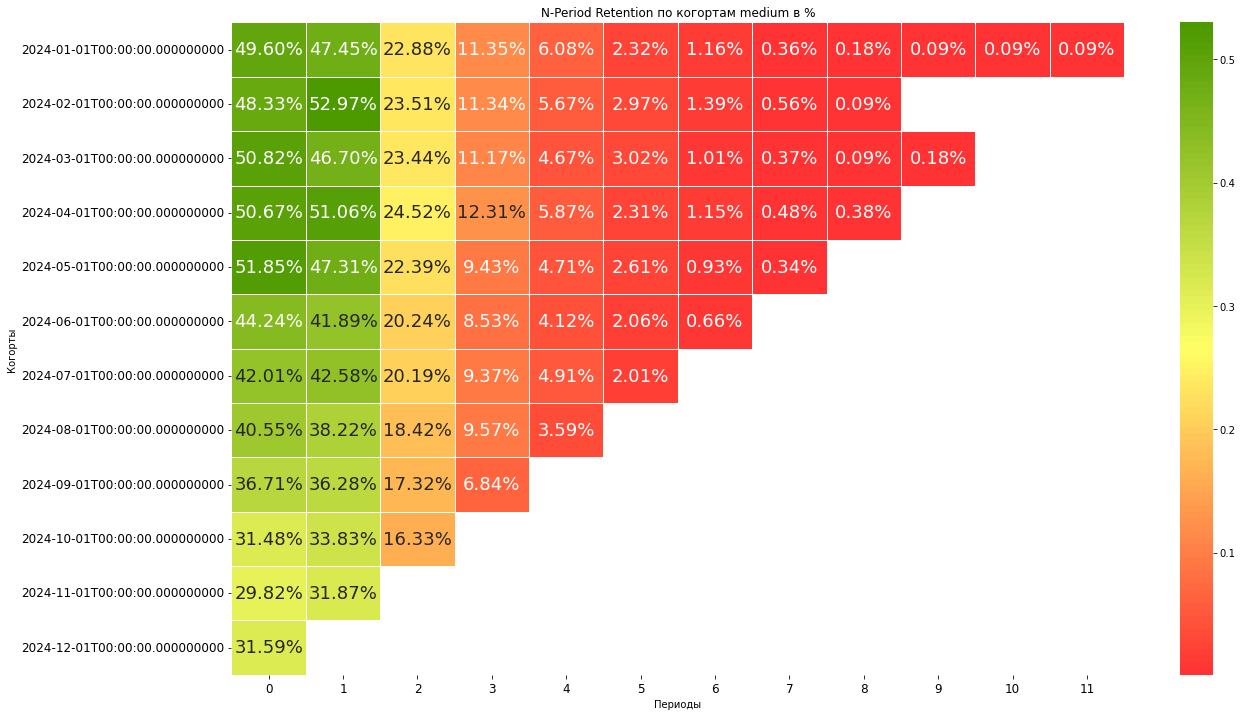

In [80]:
df_retention_medium=df_funnel[df_funnel['buyer_segment'] == 'medium']
#Группировка данных по cohort_month и event_month
retention_medium=df_retention_medium.groupby(['cohort_month','event_month'])['user_id'].nunique().reset_index()
#Нахождение размера когорты
cohort_size = users[users['buyer_segment']=='medium'].groupby('cohort_month')['user_id'].nunique().to_dict()
#Расчет retention
retention_medium['retention'] = retention_medium.apply(lambda row: row['user_id']/cohort_size.get(row['cohort_month'],1), axis=1)
#Сколько месяцев прошло с начала когорты до текущего события. 
retention_medium['event_month'] = pd.to_datetime(retention_medium['event_month'])
retention_medium['cohort_month'] = pd.to_datetime(retention_medium['cohort_month'])
retention_medium['month_offset'] = retention_medium.apply(lambda row: (row['event_month'].year - row['cohort_month'].year)*12 + 
                                           (row['event_month'].month - row['cohort_month'].month),axis=1)
#Пивотирование таблицы
retention_pivot = retention_medium.pivot_table(
    index='cohort_month',
    columns = 'month_offset',
    values='retention'
)
retention_pivot.round(4)*100


cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900'], N=100)
plt.subplots(figsize=(20,12))
sns.heatmap(retention_pivot,
            cmap=cmap,
            annot=True,
            fmt='.2%',
            linewidth=0.5,
            annot_kws={"size": 18})

# Остальные параметры совпадают с линейными графиками на matplotlib
plt.title('N-Period Retention по когортам medium в %')
plt.xlabel('Периоды')
plt.ylabel('Когорты')
plt.yticks(rotation=0)
plt.tick_params(labelsize=12) # чтобы сделать подписи данных на оси Y (когорты пользователей) немного крупнее
plt.show()

Также наблюдается падение и низкое удержание, как и в сегменте `regular`.

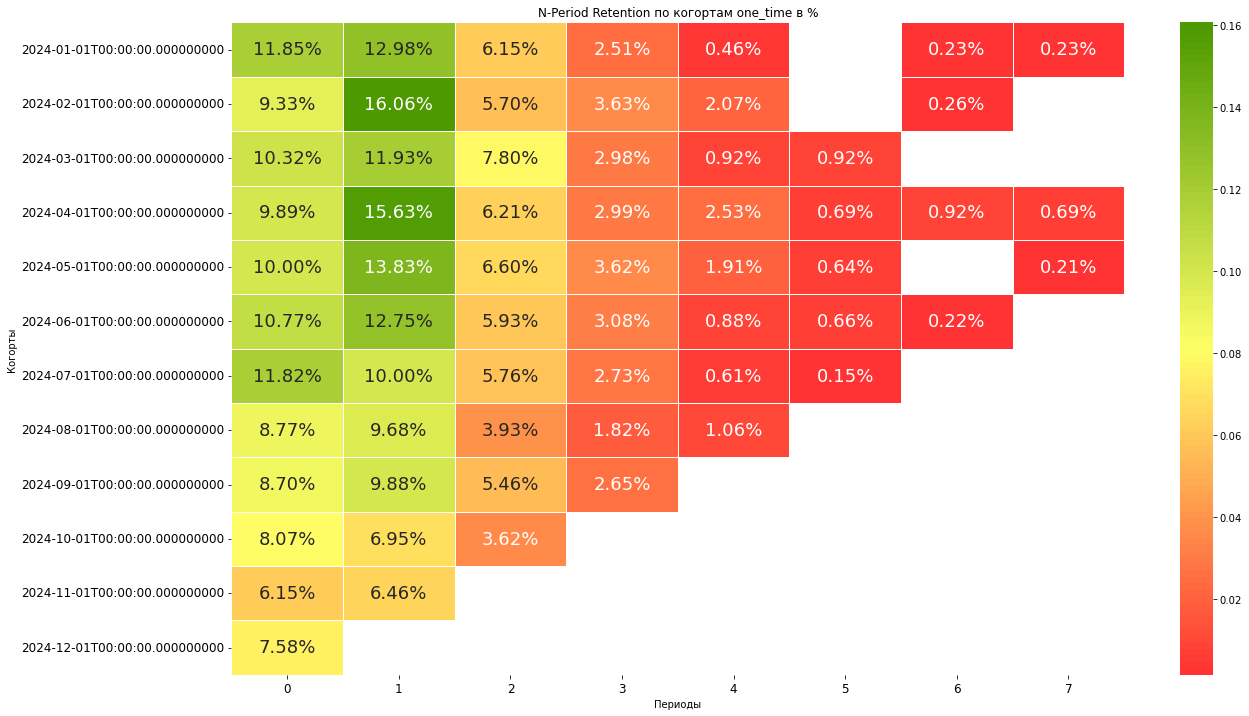

In [81]:
df_retention_one=df_funnel[df_funnel['buyer_segment'] == 'one_time']
#Группировка данных по cohort_month и event_month
df_retention_one=df_retention_one.groupby(['cohort_month','event_month'])['user_id'].nunique().reset_index()
#Нахождение размера когорты
cohort_size = users[users['buyer_segment']=='one_time'].groupby('cohort_month')['user_id'].nunique().to_dict()
#Расчет retention
df_retention_one['retention'] = df_retention_one.apply(lambda row: row['user_id']/cohort_size.get(row['cohort_month'],1), axis=1)
#Сколько месяцев прошло с начала когорты до текущего события. 
df_retention_one['event_month'] = pd.to_datetime(df_retention_one['event_month'])
df_retention_one['cohort_month'] = pd.to_datetime(df_retention_one['cohort_month'])
df_retention_one['month_offset'] = df_retention_one.apply(lambda row: (row['event_month'].year - row['cohort_month'].year)*12 + 
                                           (row['event_month'].month - row['cohort_month'].month),axis=1)
#Пивотирование таблицы
retention_pivot = df_retention_one.pivot_table(
    index='cohort_month',
    columns = 'month_offset',
    values='retention'
)
retention_pivot.round(4)*100


cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900'], N=100)
plt.subplots(figsize=(20,12))
sns.heatmap(retention_pivot,
            cmap=cmap,
            annot=True,
            fmt='.2%',
            linewidth=0.5,
            annot_kws={"size": 18})

# Остальные параметры совпадают с линейными графиками на matplotlib
plt.title('N-Period Retention по когортам one_time в %')
plt.xlabel('Периоды')
plt.ylabel('Когорты')
plt.yticks(rotation=0)
plt.tick_params(labelsize=12) # чтобы сделать подписи данных на оси Y (когорты пользователей) немного крупнее
plt.show()

Сегмент показывает экстремально низкое удержание. Продукт полностью теряет одноразовых покупателей через 1-2 месяца. 

Анализ Retention по сегментам подтверждает системное падение лояльности пользователей, привлеченных во втором полугодии. Даже среди регулярных пользователей удержание упало в первые месяцы. Поздние когорты поэтому и имеют низкий LTV.Продукт перестал удерживать даже самых активных пользователей.  

#### 6.1.1. Топ товаров в сегментах

In [82]:
df_category=df_segment.merge(orders_filtr[['user_id','order_id','category_name']], on=['user_id','order_id'], how='left')
df_category.head()

,user_id,cohort_month,buyer_segment,order_id,order_month,total_revenue,lifetime,category_name
0,1,2024-01-01,regular,NaN,NaT,NaN,NaN,NaN
1,2,2024-01-01,rare,NaN,NaT,NaN,NaN,NaN
2,3,2024-01-01,regular,1.0,2024-01-01,553.91,0.0,Инструменты и садовый инвентарь
3,3,2024-01-01,regular,2.0,2024-01-01,567.02,0.0,Инструменты и садовый инвентарь
4,3,2024-01-01,regular,3.0,2024-01-01,1089.21,0.0,Инструменты и садовый инвентарь


In [83]:
df_category_group = df_category.groupby(['buyer_segment', 'category_name'])['order_id'].count().reset_index(name='category_count')
df_category_group.head()

,buyer_segment,category_name,category_count
0,medium,Автотовары,249
1,medium,Аксессуары для гаджетов,345
2,medium,Бытовая техника,233
3,medium,Декор и освещение,232
4,medium,Детская одежда,332


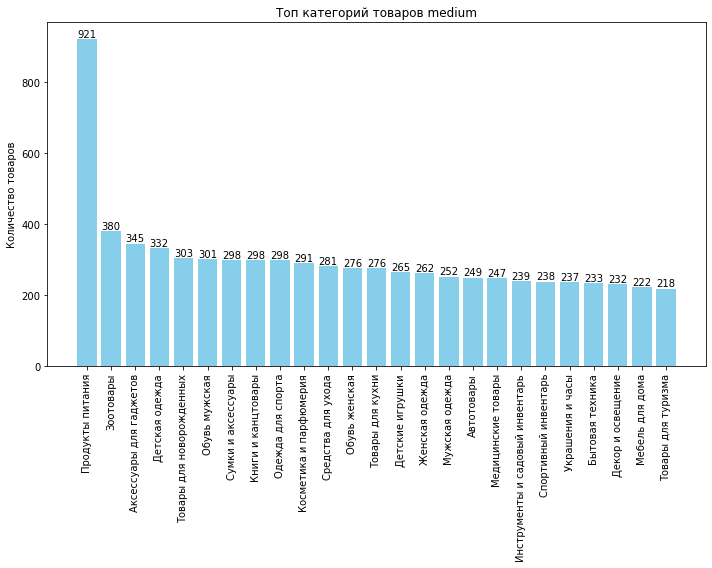

In [84]:
df_category_medium = df_category_group[df_category_group['buyer_segment']=='medium'].sort_values(by='category_count', ascending=False)
# Построение графика классической воронки 
plt.figure(figsize=(10, 8))
plt.bar(df_category_medium['category_name'], df_category_medium['category_count'], color='skyblue')
plt.title('Топ категорий товаров medium')
plt.ylabel('Количество товаров')
plt.xticks(rotation=90)
plt.tight_layout()
for i, v in enumerate(df_category_medium['category_count']):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.show()

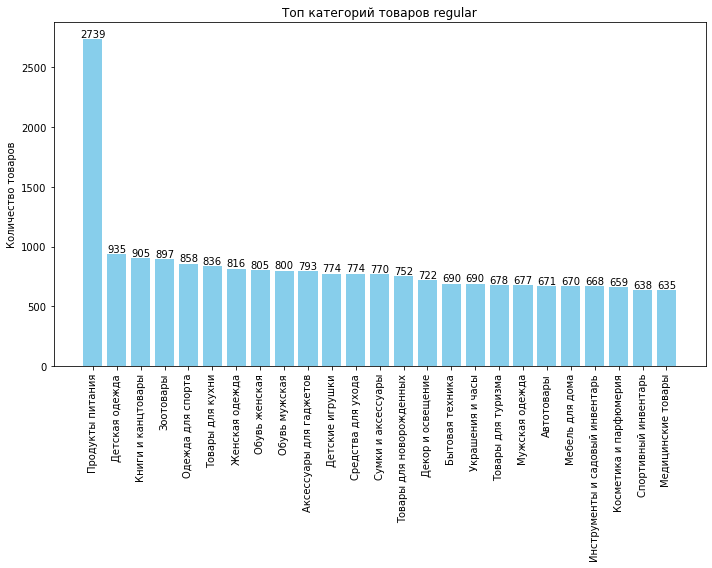

In [85]:
df_category_regular = df_category_group[df_category_group['buyer_segment']=='regular'].sort_values(by='category_count', ascending=False)
# Построение графика классической воронки 
plt.figure(figsize=(10, 8))
plt.bar(df_category_regular['category_name'], df_category_regular['category_count'], color='skyblue')
plt.title('Топ категорий товаров regular')
plt.ylabel('Количество товаров')
plt.xticks(rotation=90)
plt.tight_layout()
for i, v in enumerate(df_category_regular['category_count']):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.show()

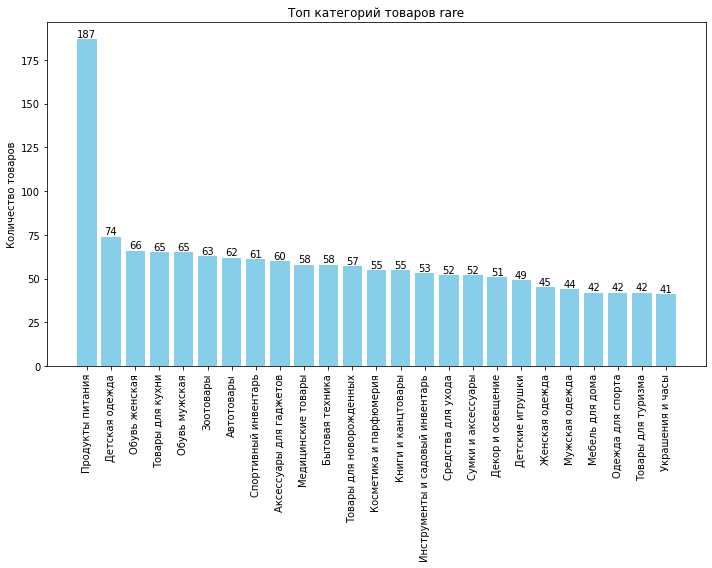

In [86]:
df_category_rare = df_category_group[df_category_group['buyer_segment']=='rare'].sort_values(by='category_count', ascending=False)
# Построение графика классической воронки 
plt.figure(figsize=(10, 8))
plt.bar(df_category_rare['category_name'], df_category_rare['category_count'], color='skyblue')
plt.title('Топ категорий товаров rare')
plt.ylabel('Количество товаров')
plt.xticks(rotation=90)
plt.tight_layout()
for i, v in enumerate(df_category_rare['category_count']):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.show()

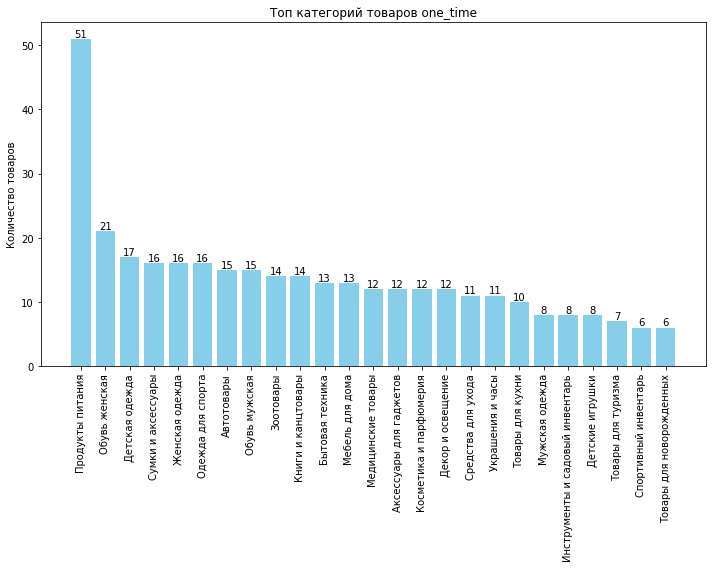

In [87]:
df_category_one = df_category_group[df_category_group['buyer_segment']=='one_time'].sort_values(by='category_count', ascending=False)
# Построение графика классической воронки 
plt.figure(figsize=(10, 8))
plt.bar(df_category_one['category_name'], df_category_one['category_count'], color='skyblue')
plt.title('Топ категорий товаров one_time')
plt.ylabel('Количество товаров')
plt.xticks(rotation=90)
plt.tight_layout()
for i, v in enumerate(df_category_one['category_count']):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.show()

Катагория продукты питания является лидером среди всех сегментов, особенно у `regular`. Эта категория стимулирует повторные покупки и является ключевой. Также детская одежда во всех категориях в топе. Зоотовары в сегментах `regular` и` medium`. Редко покупаемые товары: украшения и часы, товары для туризма, мебель для дома.

#### 6.1.2. Топ выручки товаров по сегментам

In [88]:
df_category_revenue = df_category.groupby(['buyer_segment','category_name'])['total_revenue'].sum().reset_index(name='category_revenue')
df_category_revenue.head()

,buyer_segment,category_name,category_revenue
0,medium,Автотовары,267689.75
1,medium,Аксессуары для гаджетов,171743.17
2,medium,Бытовая техника,503160.41
3,medium,Декор и освещение,159186.50
4,medium,Детская одежда,77563.64


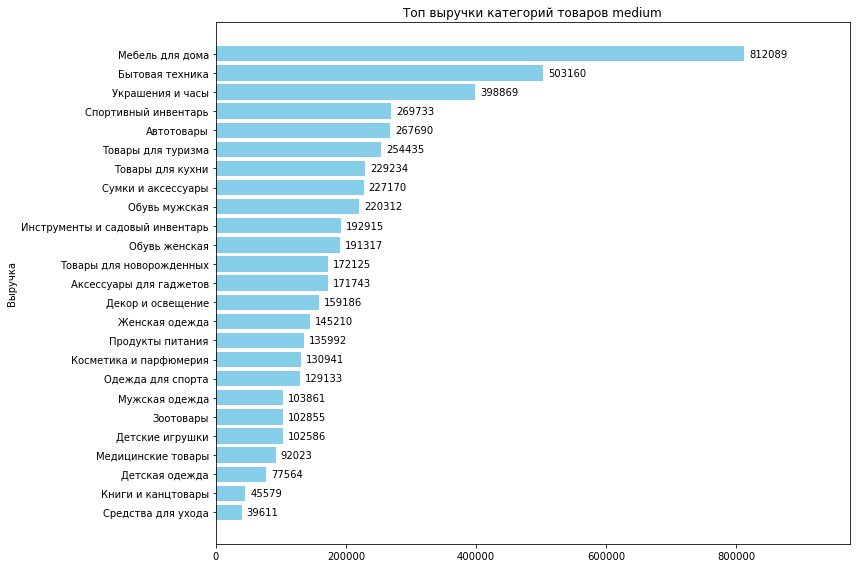

In [89]:
df_category_revenue_medium = df_category_revenue[df_category_revenue['buyer_segment']=='medium'].sort_values(by='category_revenue', ascending=True)
# Построение графика классической воронки 
plt.figure(figsize=(12, 8))
bars = plt.barh(df_category_revenue_medium['category_name'], df_category_revenue_medium['category_revenue'], color='skyblue')
plt.title('Топ выручки категорий товаров medium')
plt.ylabel('Выручка')
plt.xticks()
plt.tight_layout()
plt.bar_label(bars, padding=5, fmt='%.0f')
plt.xlim(0, df_category_revenue_medium['category_revenue'].max() * 1.2)
plt.show()

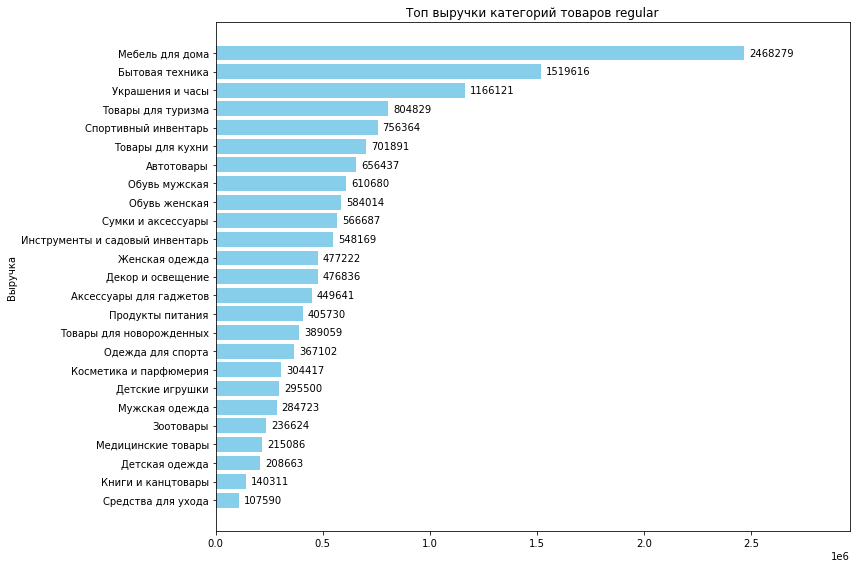

In [90]:
df_category_revenue_regular = df_category_revenue[df_category_revenue['buyer_segment']=='regular'].sort_values(by='category_revenue', ascending=True)
# Построение графика классической воронки 
plt.figure(figsize=(12, 8))
bars = plt.barh(df_category_revenue_regular['category_name'], df_category_revenue_regular['category_revenue'], color='skyblue')
plt.title('Топ выручки категорий товаров regular')
plt.ylabel('Выручка')
plt.xticks()
plt.tight_layout()
plt.bar_label(bars, padding=5, fmt='%.0f')
plt.xlim(0, df_category_revenue_regular['category_revenue'].max() * 1.2)
plt.show()

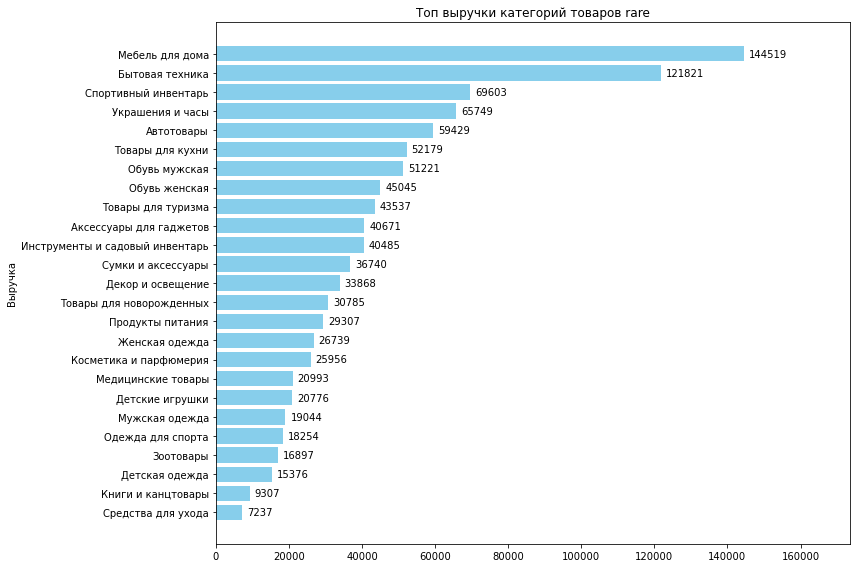

In [91]:
df_category_revenue_rare = df_category_revenue[df_category_revenue['buyer_segment']=='rare'].sort_values(by='category_revenue', ascending=True)
# Построение графика классической воронки 
plt.figure(figsize=(12, 8))
bars = plt.barh(df_category_revenue_rare['category_name'], df_category_revenue_rare['category_revenue'], color='skyblue')
plt.title('Топ выручки категорий товаров rare')
plt.ylabel('Выручка')
plt.xticks()
plt.tight_layout()
plt.bar_label(bars, padding=5, fmt='%.0f')
plt.xlim(0, df_category_revenue_rare['category_revenue'].max() * 1.2)
plt.show()

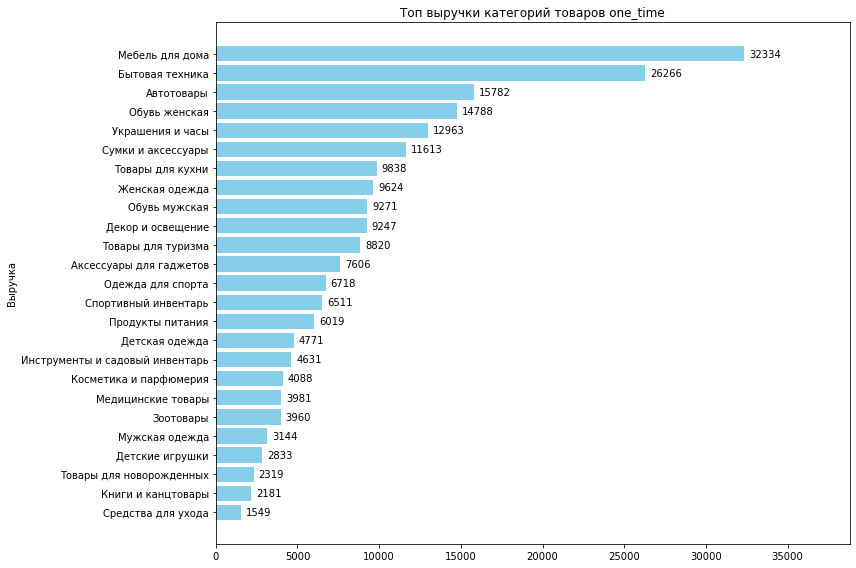

In [92]:
df_category_revenue_one = df_category_revenue[df_category_revenue['buyer_segment']=='one_time'].sort_values(by='category_revenue', ascending=True)
# Построение графика классической воронки 
plt.figure(figsize=(12, 8))
bars = plt.barh(df_category_revenue_one['category_name'], df_category_revenue_one['category_revenue'], color='skyblue')
plt.title('Топ выручки категорий товаров one_time')
plt.ylabel('Выручка')
plt.xticks()
plt.tight_layout()
plt.bar_label(bars, padding=5, fmt='%.0f')
plt.xlim(0, df_category_revenue_one['category_revenue'].max() * 1.2)
plt.show()

Анализ показал, что высокий денежный вклад показывают категории: мебель для дома, бытовая техника, украшения, спортинвентарь. Продукты питания, несмотря на лидерство по количеству заказов, приносят умеренную выручку и служат удержанием. 

In [93]:
df_aov = pd.merge(df_category_revenue, df_category_group, on=['buyer_segment','category_name'], how='left')
df_aov['AOV'] = df_aov['category_revenue']/df_aov['category_count']
df_aov.head()

,buyer_segment,category_name,category_revenue,category_count,AOV
0,medium,Автотовары,267689.75,249,1075.059237
1,medium,Аксессуары для гаджетов,171743.17,345,497.806290
2,medium,Бытовая техника,503160.41,233,2159.486738
3,medium,Декор и освещение,159186.50,232,686.148707
4,medium,Детская одежда,77563.64,332,233.625422


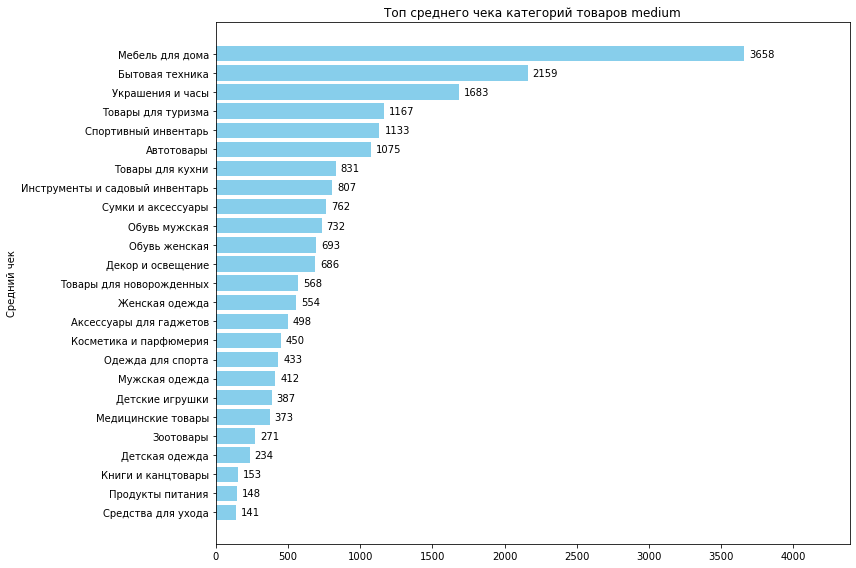

In [94]:
df_aov_medium = df_aov[df_aov['buyer_segment']=='medium'].sort_values(by='AOV', ascending=True)
# Построение графика классической воронки 
plt.figure(figsize=(12, 8))
bars = plt.barh(df_aov_medium['category_name'], df_aov_medium['AOV'], color='skyblue')
plt.title('Топ среднего чека категорий товаров medium')
plt.ylabel('Средний чек')
plt.xticks()
plt.tight_layout()
plt.bar_label(bars, padding=5, fmt='%.0f')
plt.xlim(0, df_aov_medium['AOV'].max() * 1.2)
plt.show()

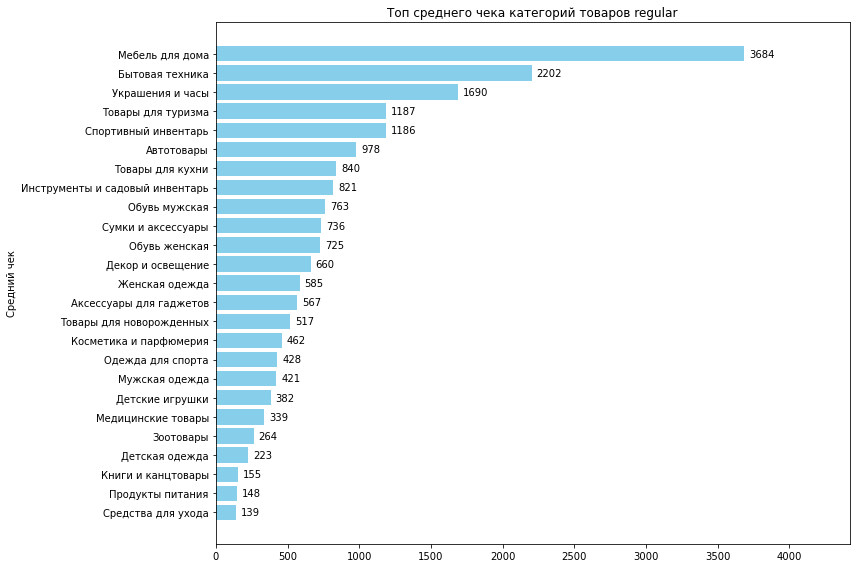

In [95]:
df_aov_regular = df_aov[df_aov['buyer_segment']=='regular'].sort_values(by='AOV', ascending=True)
# Построение графика классической воронки 
plt.figure(figsize=(12, 8))
bars = plt.barh(df_aov_regular['category_name'], df_aov_regular['AOV'], color='skyblue')
plt.title('Топ среднего чека категорий товаров regular')
plt.ylabel('Средний чек')
plt.xticks()
plt.tight_layout()
plt.bar_label(bars, padding=5, fmt='%.0f')
plt.xlim(0, df_aov_regular['AOV'].max() * 1.2)
plt.show()

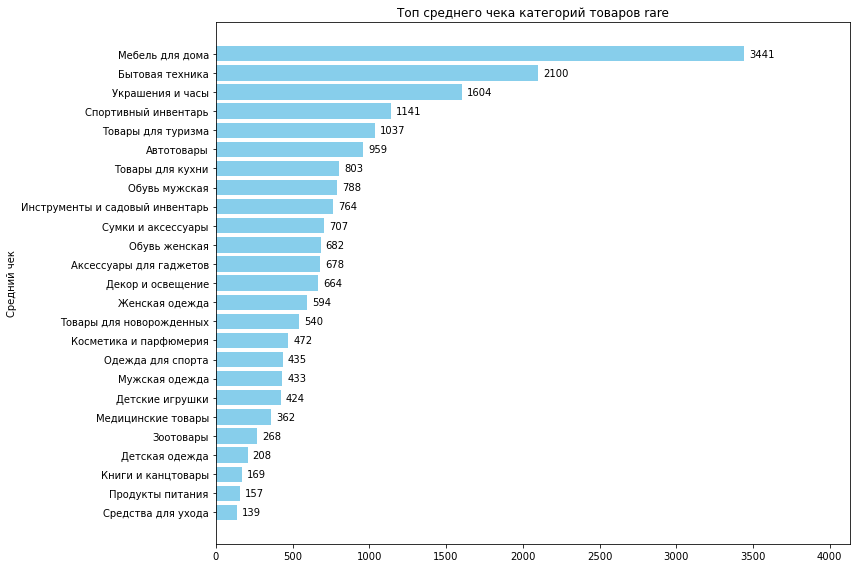

In [96]:
df_aov_rare = df_aov[df_aov['buyer_segment']=='rare'].sort_values(by='AOV', ascending=True)
# Построение графика классической воронки 
plt.figure(figsize=(12, 8))
bars = plt.barh(df_aov_rare['category_name'], df_aov_rare['AOV'], color='skyblue')
plt.title('Топ среднего чека категорий товаров rare')
plt.ylabel('Средний чек')
plt.xticks()
plt.tight_layout()
plt.bar_label(bars, padding=5, fmt='%.0f')
plt.xlim(0, df_aov_rare['AOV'].max() * 1.2)
plt.show()

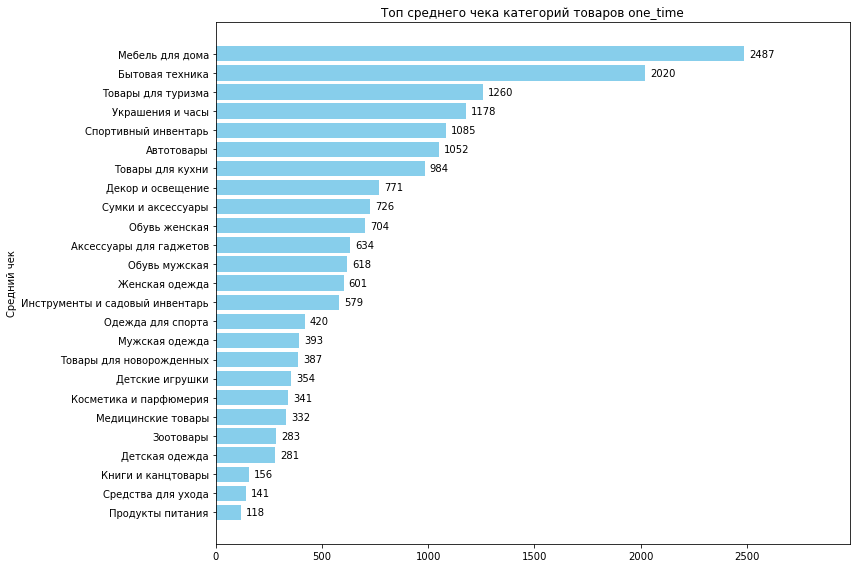

In [97]:
df_aov_one = df_aov[df_aov['buyer_segment']=='one_time'].sort_values(by='AOV', ascending=True)
# Построение графика классической воронки 
plt.figure(figsize=(12, 8))
bars = plt.barh(df_aov_one['category_name'], df_aov_one['AOV'], color='skyblue')
plt.title('Топ среднего чека категорий товаров one_time')
plt.ylabel('Средний чек')
plt.xticks()
plt.tight_layout()
plt.bar_label(bars, padding=5, fmt='%.0f')
plt.xlim(0, df_aov_one['AOV'].max() * 1.2)
plt.show()

Высокомаржинальные категории - мебель, бытовая техника, укращения и часы. Это те товары, которые покупаются редко, но дорого. И есть сегмент недорого, но часто - продукты питания, средства для ухода, книги и канцтовары, детская одежда, зоотовары. В этих категориях нужено увеличивать средний чек. 


По всему анализу по сегментам можно сказать, что `regular` единственный прибыльный сегмент. Это видно по показателям LTV, CAC, ROI. Все остальные сегменты не окупают затраты. По воронке у сегментов `rare` и `one_time` потери на ранних этапах. У `regular` и `medium` на финальной оплате. Удержание у всех сегментов падает. Продукт теряет способность возвращать пользователей даже после нескольких покупок. Пользуются популярностью такие товары: продукты питания, детские товары, но выручка с них низкая, а мебель, техника, украшения пользуются меньшим спросом, но выручка с них заметнее выше. 

### 6.2. По каналам

In [98]:
campaign_costs['acq_channel'].unique()

array(['affiliate', 'direct', 'email_marketing', 'social_media',
       'google_ads', 'seo', 'tiktok'], dtype=object)

In [99]:
users['acq_channel'].unique()

array(['google_ads', 'email_marketing', 'affiliate', 'seo',
       'social_media', 'tiktok'], dtype=object)

Обнаружена проблема с оплатой по каналу, которому ни один пользователь не был привлечен. Это может быть и технический сбой, если это печатная реклама, ввести отслеживающие коды. 

In [100]:
# Объединяние заказов и пользователей
df_channel = pd.merge(users[['user_id', 'cohort_month', 'acq_channel']], 
                      orders_filtr[['user_id', 'order_id', 'order_month', 'total_revenue']], how='left')
df_channel.head()

,user_id,cohort_month,acq_channel,order_id,order_month,total_revenue
0,1,2024-01-01,google_ads,NaN,NaT,NaN
1,2,2024-01-01,email_marketing,NaN,NaT,NaN
2,3,2024-01-01,google_ads,1.0,2024-01-01,553.91
3,3,2024-01-01,google_ads,2.0,2024-01-01,567.02
4,3,2024-01-01,google_ads,3.0,2024-01-01,1089.21


In [101]:
#Нахождение количества пользователей в когортах
channel_sizes = df_channel.groupby(['cohort_month', 'acq_channel'])['user_id'].nunique().reset_index(name='reg_users')

# Расчет lifetime 
df_channel['lifetime'] = (df_channel['order_month'].dt.year - df_channel['cohort_month'].dt.year)* 12 + (df_channel['order_month'].dt.month - df_channel['cohort_month'].dt.month)

# Расчет чистой выручки когорты по lifetime
channel_revenue = df_channel.groupby(['cohort_month', 'acq_channel', 'lifetime']).agg(
        total_revenue=('total_revenue', 'sum'),
        total_orders=('order_id', 'nunique')  
    ).reset_index()

# Добавление к выручке изначальный размер когорты
df_grouped_channel = pd.merge(channel_revenue, channel_sizes, on=['cohort_month', 'acq_channel'], how='left')

# Расчет AOV, ARPU и кумулятивный LTV
df_grouped_channel['AOV'] = df_grouped_channel['total_revenue'] / df_grouped_channel['total_orders']
df_grouped_channel['ARPU'] = df_grouped_channel['total_revenue'] / df_grouped_channel['reg_users']
df_grouped_channel['LTV'] = df_grouped_channel.groupby(['cohort_month','acq_channel'])['ARPU'].cumsum()
df_grouped_channel.head()

,cohort_month,acq_channel,lifetime,total_revenue,total_orders,reg_users,AOV,ARPU,LTV
0,2024-01-01,affiliate,0.0,147274.64,240,575,613.644333,256.129809,256.129809
1,2024-01-01,affiliate,1.0,220799.01,342,575,645.611140,383.998278,640.128087
2,2024-01-01,affiliate,2.0,108788.12,177,575,614.622147,189.196730,829.324817
3,2024-01-01,affiliate,3.0,38450.73,88,575,436.940114,66.870835,896.195652
4,2024-01-01,affiliate,4.0,25742.05,31,575,830.388710,44.768783,940.964435


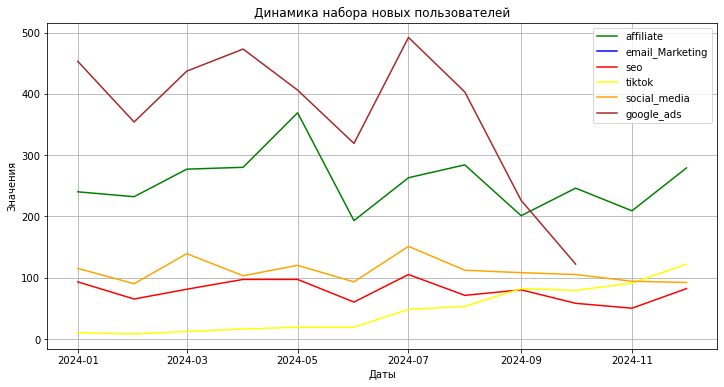

In [102]:
#Определение динамики набора новых пользователей
dinamika = df_channel[df_channel['lifetime']==0].groupby(['cohort_month','acq_channel'])['user_id'].count().reset_index()
# строим график в matplotlib
plt.subplots(figsize=(12,6))
plt.plot(dinamika[dinamika['acq_channel'] == 'affiliate']['cohort_month'], 
         dinamika[dinamika['acq_channel'] == 'affiliate']['user_id'], color='green')
plt.plot(dinamika[dinamika['acq_channel'] == 'email_Marketing']['cohort_month'], 
         dinamika[dinamika['acq_channel'] == 'email_Marketing']['user_id'], color='blue')
plt.plot(dinamika[dinamika['acq_channel'] == 'seo']['cohort_month'], 
         dinamika[dinamika['acq_channel'] == 'seo']['user_id'], color='red')
plt.plot(dinamika[dinamika['acq_channel'] == 'tiktok']['cohort_month'], 
         dinamika[dinamika['acq_channel'] == 'tiktok']['user_id'], color='yellow')
plt.plot(dinamika[dinamika['acq_channel'] == 'social_media']['cohort_month'], 
         dinamika[dinamika['acq_channel'] == 'social_media']['user_id'], color='orange')
plt.plot(dinamika[dinamika['acq_channel'] == 'google_ads']['cohort_month'], 
         dinamika[dinamika['acq_channel'] == 'google_ads']['user_id'], color='brown')
plt.title('Динамика набора новых пользователей')
plt.legend(['affiliate', 'email_Marketing', 'seo', 'tiktok', 'social_media', 'google_ads'])
plt.xlabel('Даты')
plt.ylabel('Значения')
plt.grid()
plt.show()

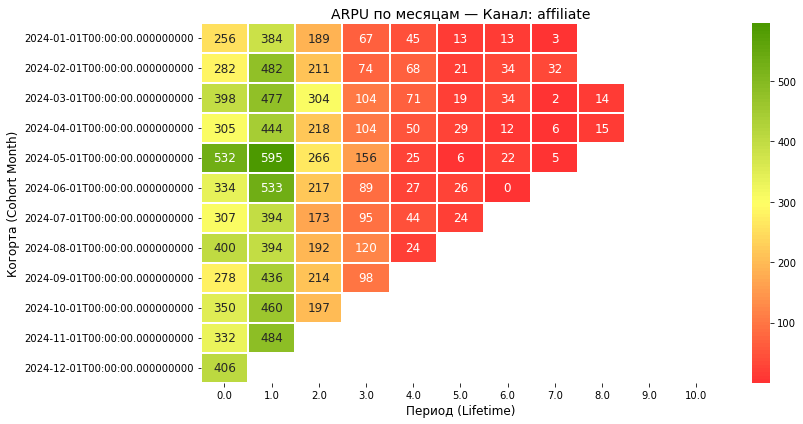

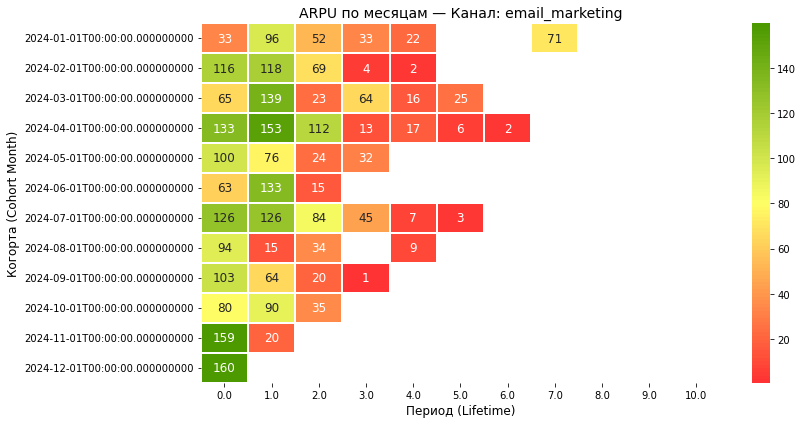

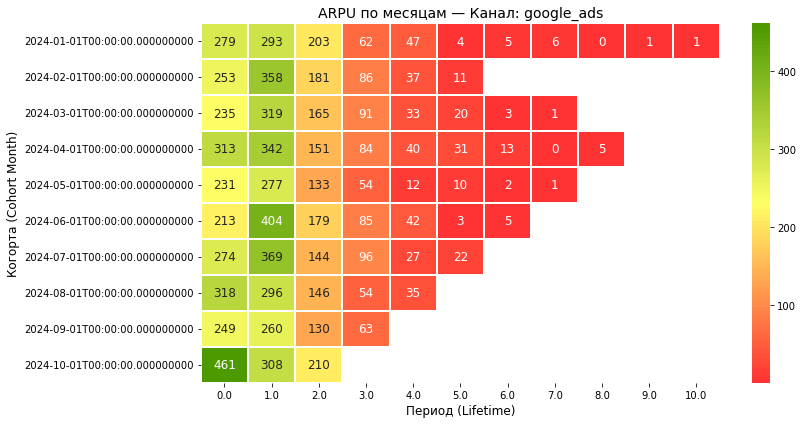

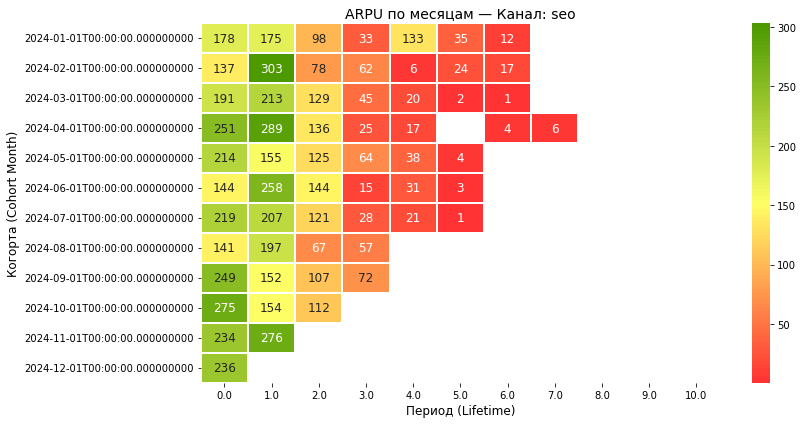

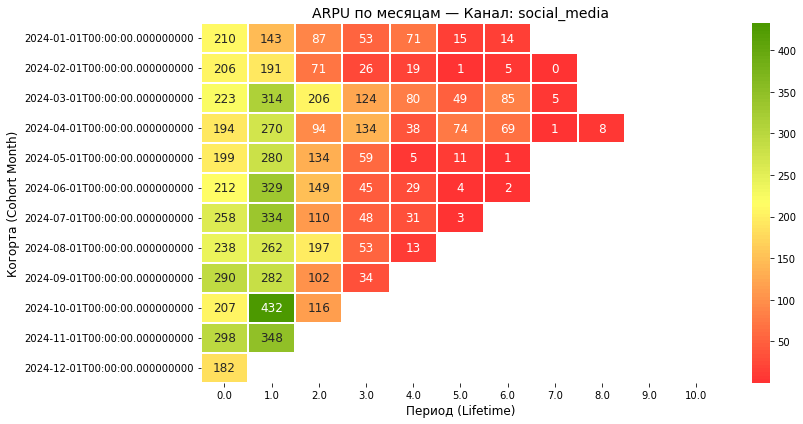

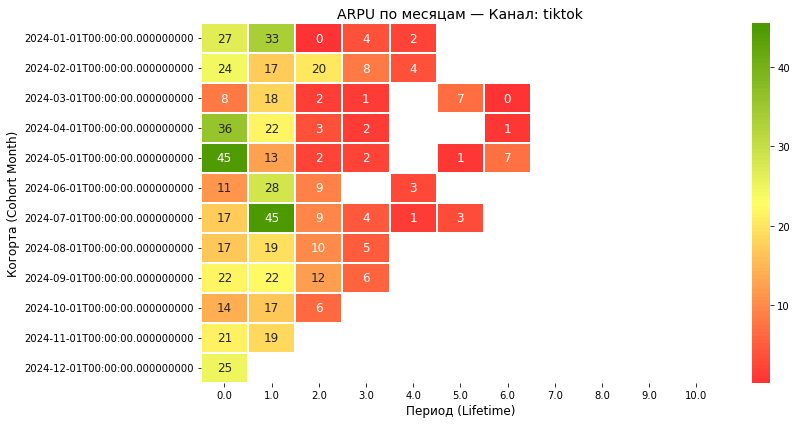

In [103]:
df_pivot_arpu = df_grouped_channel.pivot_table(index=['acq_channel', 'cohort_month'], columns='lifetime', values='ARPU')

# Список всех уникальных сегментов
channels = df_grouped_channel['acq_channel'].unique()

# В цикле отдельный heatmap для каждого сегмента
for channel in channels:
    plt.figure(figsize=(12, 6))

    # Фильтруем данные сводной таблицы по конкретному сегменту
    # cross-section (xs) вытаскивает срез по первому уровню индекса
    channel_pivot = df_pivot_arpu.xs(channel, level='acq_channel')

    # Построение heatmap ARPU с палитрой
    sns.heatmap(
        channel_pivot,
        cmap=cmap, 
        annot=True,
        fmt='.0f',
        linewidths=2,
        annot_kws={'size': 12},
    )

    # Настраиваем заголовки динамически под каждый сегмент
    plt.title(f'ARPU по месяцам — Канал: {channel}', fontsize=14)
    plt.xlabel('Период (Lifetime)', fontsize=12)
    plt.ylabel('Когорта (Cohort Month)', fontsize=12)

    plt.tight_layout()
    plt.show()

Каналы Affiliate и Goodle Ads являются основными каналами привлечения. Они дают наибольшее количество пользователей и при этом показывает наибольший ARPU. Заметно сильное снижение привлечения пользователей на канале Goodle Ads. Social media по объему привлечения пользователей третий, но ARPU ниже. SEO после июня начинает привлекать больше пользователей, это первая положительная тенденция второго полугодия, ARPU даже растет. TikTok наращивает во втором полугодии зарегистрированных пользователей, но  ARPU снижается бытро. И Email Marketing у поздних когорт наблюдается рост ARPU, но падает после 3-4 месяцев. 

In [104]:
#Создание таблицы CAC
cac_channel = (campaign_costs
       .groupby(['spend_month', 'acq_channel'])['budget'].sum().reset_index()
       .merge(df_grouped_channel,
              left_on=['spend_month', 'acq_channel'],
              right_on=['cohort_month', 'acq_channel'], how='inner')
       .assign(CAC = lambda x: x['budget']/x['reg_users'])
      )
#Расчет ROI
cac_channel['ROI'] = (cac_channel['LTV']-cac_channel['CAC'])/cac_channel['CAC'] * 100
cac_channel.head()

,spend_month,acq_channel,budget,cohort_month,lifetime,total_revenue,total_orders,reg_users,AOV,ARPU,LTV,CAC,ROI
0,2024-01-01,affiliate,179343.3875,2024-01-01,0.0,147274.64,240,575,613.644333,256.129809,256.129809,311.901543,-17.881199
1,2024-01-01,affiliate,179343.3875,2024-01-01,1.0,220799.01,342,575,645.611140,383.998278,640.128087,311.901543,105.234023
2,2024-01-01,affiliate,179343.3875,2024-01-01,2.0,108788.12,177,575,614.622147,189.196730,829.324817,311.901543,165.893143
3,2024-01-01,affiliate,179343.3875,2024-01-01,3.0,38450.73,88,575,436.940114,66.870835,896.195652,311.901543,187.332869
4,2024-01-01,affiliate,179343.3875,2024-01-01,4.0,25742.05,31,575,830.388710,44.768783,940.964435,311.901543,201.686367


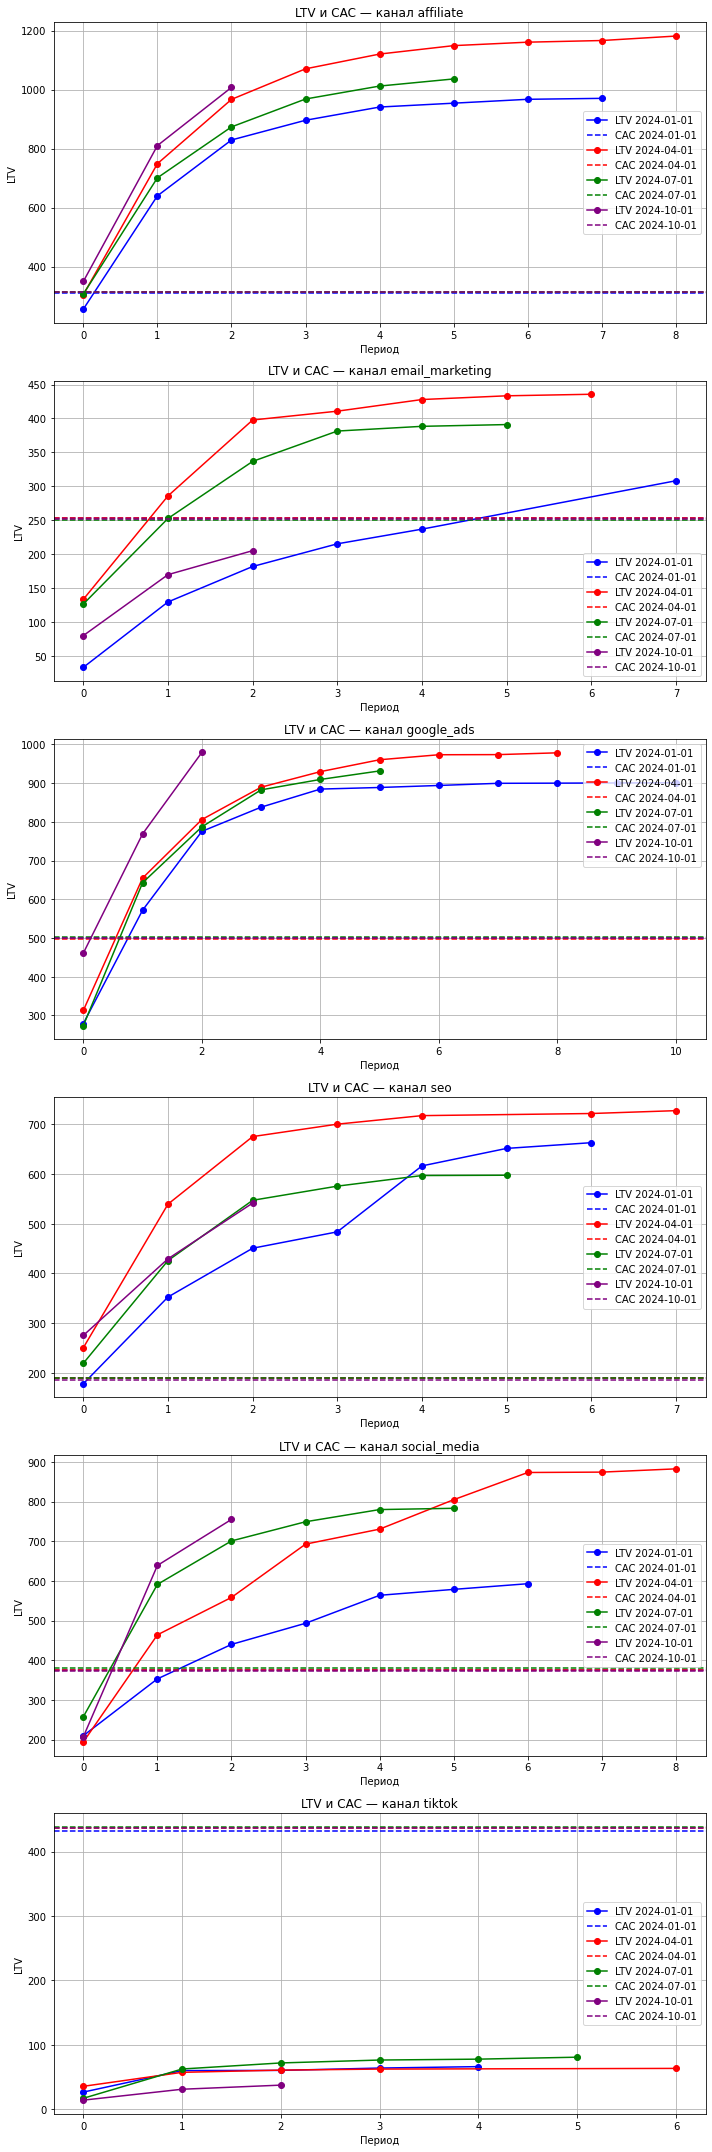

In [105]:
# Словарь с когортами и соответствующими им цветами
first_months_colors = {'2024-01-01': 'blue', '2024-04-01': 'red', '2024-07-01': 'green', '2024-10-01': 'purple'}

# Список каналов, которые хотим отобразить
channels = cac_channel['acq_channel'].unique()  

# Создаём сетку: количество строк = количеству каналов, 1 столбец
fig, axes = plt.subplots(len(channels), 1, figsize=(10, 5 * len(channels)))

# Если каналов один, axes может быть не массивом — оборачиваем в список для единообразия
if len(channels) == 1:
    axes = [axes]

# Цикл по каналам
for idx, channel in enumerate(channels):
    ax = axes[idx]  # текущий подграфик
    
    # Фильтруем данные по каналу
    cac_channel_filtered = cac_channel[cac_channel['acq_channel'] == channel]
    
    # Цикл по когортам внутри канала
    for month, color in first_months_colors.items():
        # Фильтруем по когорте
        df_plot = cac_channel_filtered[cac_channel_filtered['cohort_month'] == month]
        
        # Строим LTV
        ax.plot(
            df_plot['lifetime'],
            df_plot['LTV'],
            color=color,
            marker='o',
            label=f'LTV {month}'
        )
        
        # Строим CAC — горизонтальная линия
        cac_value = df_plot['CAC'].mean()
        ax.axhline(
            y=cac_value,
            color=color,
            linestyle='--',
            label=f'CAC {month}'
        )
    
    # Настройка каждого подграфика
    ax.set_title(f'LTV и CAC — канал {channel}')
    ax.set_xlabel('Период')
    ax.set_ylabel('LTV')
    ax.legend()
    ax.grid(True)

# Показываем все графики
plt.tight_layout()  # автоматическая подгонка отступов
plt.show()

Парадоксальное ухудшение юнит_экономики в октябрьской когорте при улучшении показателей внутри каналов (не считая TikTok) скорей всего объясняется изменением структуры трафика. Очень выросла доля убыточного канала TikTok. CAC в TikTok выше, чем в других канал, кроме Google Ads.

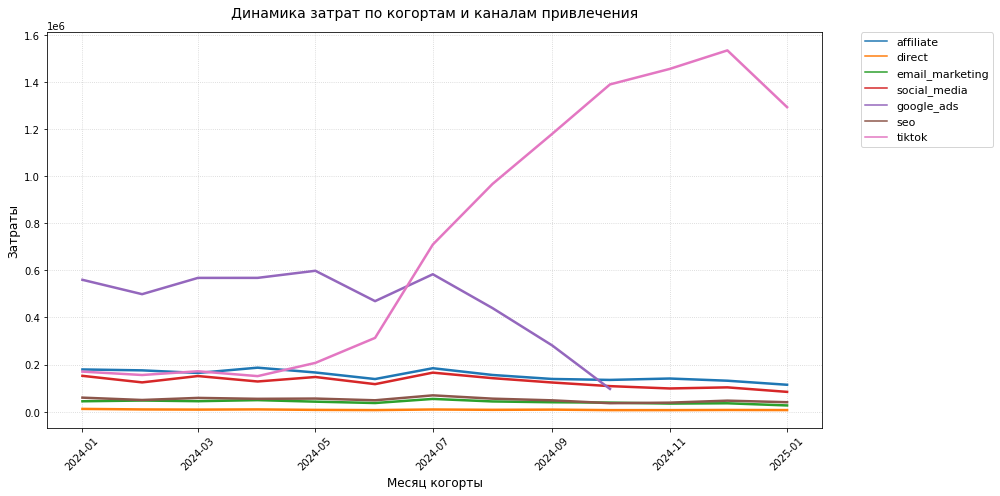

In [106]:
# Создаем просторный график
plt.figure(figsize=(14, 7))

# Строим линии динамики CAC по каналам
# linewidth=2.5 делает линии чуть толще и заметнее
sns.lineplot(
    data=campaign_costs,
    x='spend_month',
    y='budget',
    hue='acq_channel',
    linewidth=2.5
)


# Оформление графических элементов
plt.title('Динамика затрат по когортам и каналам привлечения', fontsize=14, pad=15)
plt.xlabel('Месяц когорты', fontsize=12)
plt.ylabel('Затраты', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=45)

# Выносим легенду направо, чтобы она не закрывала линии
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=11)

# Автоматически корректируем отступы, учитывая вынесенную легенду
plt.tight_layout()
plt.show()

Заметен сильный рост в абсолютных тратах по каналу TikTok. Из-за него произошло падение LTV, ROI. Необходима корректировка перераспределение маркетингового бюджета.

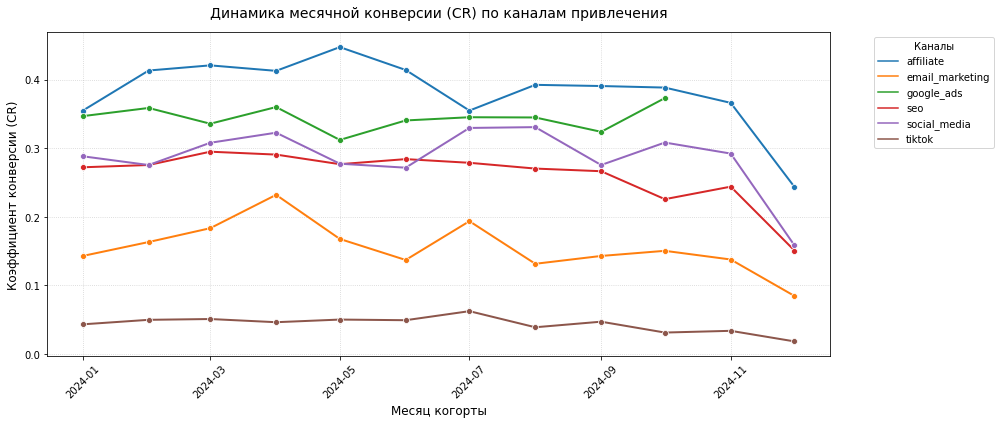

In [107]:
reg_df = df_channel.groupby(['cohort_month', 'acq_channel'])['user_id'].nunique().reset_index(name='reg_user')

pay_df = df_channel[df_channel['total_revenue'] > 0].groupby(['cohort_month', 'acq_channel'])['user_id'].nunique().reset_index(name='pay_user')


df_conversion = reg_df.merge(pay_df, on=['cohort_month', 'acq_channel'], how='left')
df_conversion['CR'] = df_conversion['pay_user']/df_conversion['reg_user']

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=df_conversion,
    x='cohort_month',
    y='CR',
    hue='acq_channel',
    marker='o',
    linewidth=2
)

# 4. Настраиваем оформление
plt.title('Динамика месячной конверсии (CR) по каналам привлечения', fontsize=14, pad=15)
plt.xlabel('Месяц когорты', fontsize=12)
plt.ylabel('Коэффициент конверсии (CR)', fontsize=12)

# Поворачиваем даты на оси X, чтобы они не сливались
plt.xticks(rotation=45)
plt.grid(True, linestyle=':', alpha=0.6)

# 5. Выносим легенду вправо, чтобы она не перекрывала линии графика
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Каналы')

# Автоматически корректируем отступы
plt.tight_layout()
plt.show()

Лидерами остаются Affiliate с быстрой окупаемостью и выоким LTV, и Google Ads с высокой конверсией, падающим бюджетом, но конверсия все же заметно снижается. Снижающееся эффективность каналов SEO, Social Media и Email Marketing конверсия падает. Канал TikTok конверсия крайне низкая, подтверждает убыточность. После июня видимо произошло перераспределение бюджета в торону TikTok, сокращение Google Ads. Юнит-экономика упала из-за низкой конверсии в покупку, отсутсвия оккупаемости.   

### 6.3. По регионам

In [108]:
# Объединяние регионов и пользователей
df_channel = pd.merge(df_channel, users[['user_id', 'cohort_month', 'acq_channel', 'region']], how='left')
df_channel.head()

,user_id,cohort_month,acq_channel,order_id,order_month,total_revenue,lifetime,region
0,1,2024-01-01,google_ads,NaN,NaT,NaN,NaN,Москва
1,2,2024-01-01,email_marketing,NaN,NaT,NaN,NaN,Москва
2,3,2024-01-01,google_ads,1.0,2024-01-01,553.91,0.0,Санкт-Петербург
3,3,2024-01-01,google_ads,2.0,2024-01-01,567.02,0.0,Санкт-Петербург
4,3,2024-01-01,google_ads,3.0,2024-01-01,1089.21,0.0,Санкт-Петербург


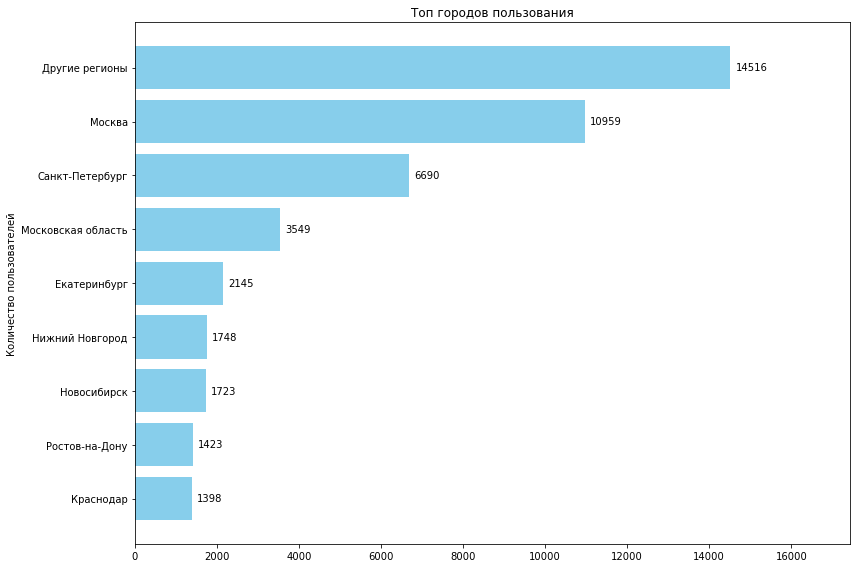

In [109]:
df_channel_region= df_channel.groupby('region')['user_id'].nunique().reset_index(name='count_user')
df_channel_region = df_channel_region.sort_values(by='count_user', ascending=True)
# Построение графика классической воронки 
plt.figure(figsize=(12, 8))
bars = plt.barh(df_channel_region['region'], df_channel_region['count_user'], color='skyblue')
plt.title('Топ городов пользования')
plt.ylabel('Количество пользователей')
plt.xticks()
plt.tight_layout()
plt.bar_label(bars, padding=5, fmt='%.0f')
plt.xlim(0, df_channel_region['count_user'].max() * 1.2)
plt.show()

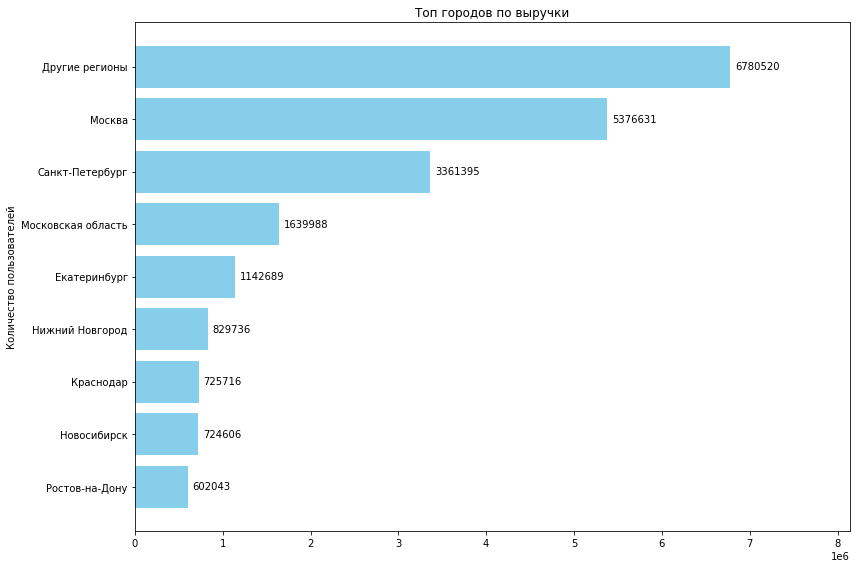

In [110]:
df_channel_region_revenue= df_channel.groupby('region')['total_revenue'].sum().reset_index(name='revenue_sum')
df_channel_region_revenue = df_channel_region_revenue.sort_values(by='revenue_sum', ascending=True)
# Построение графика классической воронки 
plt.figure(figsize=(12, 8))
bars = plt.barh(df_channel_region_revenue['region'], df_channel_region_revenue['revenue_sum'], color='skyblue')
plt.title('Топ городов по выручки')
plt.ylabel('Количество пользователей')
plt.xticks()
plt.tight_layout()
plt.bar_label(bars, padding=5, fmt='%.0f')
plt.xlim(0, df_channel_region_revenue['revenue_sum'].max() * 1.2)
plt.show()

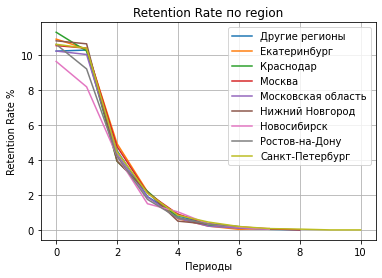

In [111]:
param_name = 'region'

table1 = df_channel.groupby(param_name)['user_id'].nunique().reset_index()
table1.rename(columns={'user_id':'total_user_count'}, inplace=True)

table2 = df_channel.groupby([param_name, 'lifetime'])['user_id'].nunique().reset_index()
table2.rename(columns={'user_id':'period_user_count'}, inplace=True)


table_final = pd.merge(table2, table1, how='left', on= param_name)
table_final['retention'] = 100*(table_final['period_user_count']/table_final['total_user_count'])

for c in table_final[param_name].unique():
    plt.plot(
        table_final[table_final[param_name] == c]['lifetime'],
        table_final[table_final[param_name] == c]['retention']
    )


plt.title(f'Retention Rate по {param_name}')
plt.legend(table_final[param_name].unique())
plt.xlabel('Периоды')
plt.ylabel('Retention Rate %')
plt.grid()
plt.show()

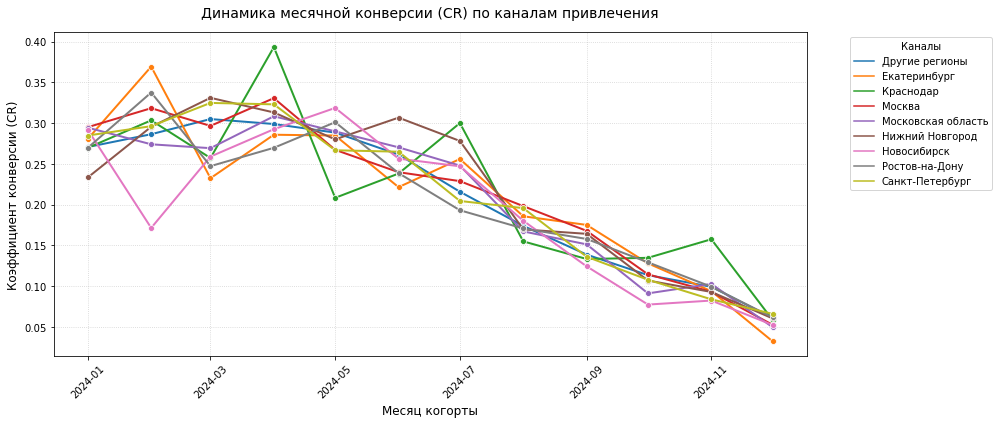

In [112]:
reg_df_region = df_channel.groupby(['region', 'cohort_month'])['user_id'].nunique().reset_index(name='reg_user')

pay_df_region = df_channel[df_channel['total_revenue'] > 0].groupby(['region', 'cohort_month'])['user_id'].nunique().reset_index(name='pay_user')


df_conversion_region = reg_df_region.merge(pay_df_region, on=['region', 'cohort_month'], how='left')
df_conversion_region['CR'] = df_conversion_region['pay_user']/df_conversion_region['reg_user']

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=df_conversion_region,
    x='cohort_month',
    y='CR',
    hue='region',
    marker='o',
    linewidth=2
)

# 4. Настраиваем оформление
plt.title('Динамика месячной конверсии (CR) по каналам привлечения', fontsize=14, pad=15)
plt.xlabel('Месяц когорты', fontsize=12)
plt.ylabel('Коэффициент конверсии (CR)', fontsize=12)

# Поворачиваем даты на оси X, чтобы они не сливались
plt.xticks(rotation=45)
plt.grid(True, linestyle=':', alpha=0.6)

# 5. Выносим легенду вправо, чтобы она не перекрывала линии графика
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Каналы')

# Автоматически корректируем отступы
plt.tight_layout()
plt.show()

Анализ топ-регионов по количеству пользователей, выручке не выявил существенных различий в эффективности. Лидерами являются: другие регионы, Москва, Санкт Петербург, Московская область. Удержание падает, конверсия падает. 

### 6.4 По оси и девайсам

Я не смогла привязать ось и девайсы к покупкам. Поэтому решила рассмотреть удержание и воронки действия пользователей.

In [113]:
funnel_steps = ['page_view', 'product_view', 'add_to_cart', 'checkout_start', 'checkout_complete', 'purchase']

In [114]:
# Фильтрация только нужных шагов 
df_funnel_step_os = events_filtr_type[events_filtr_type['event_type'].isin(funnel_steps)]
df_funnel_step_os.head()

,event_id,user_id,event_date,event_type,os,device,product_name,event_week,event_month,cohort_month,diff_days
0,3132,100,2024-01-01,page_view,ios,mobile,NaN,2024-01-01,2024-01-01,2024-01-01,0.0
1,3133,100,2024-01-01,product_view,ios,mobile,Шорты для тренировок,2024-01-01,2024-01-01,2024-01-01,0.0
3,3135,100,2024-01-01,add_to_cart,ios,mobile,Балетки классические,2024-01-01,2024-01-01,2024-01-01,0.0
4,3136,100,2024-01-01,checkout_start,ios,mobile,NaN,2024-01-01,2024-01-01,2024-01-01,0.0
5,1239,33,2024-01-01,page_view,ios,desktop,NaN,2024-01-01,2024-01-01,2024-01-01,0.0


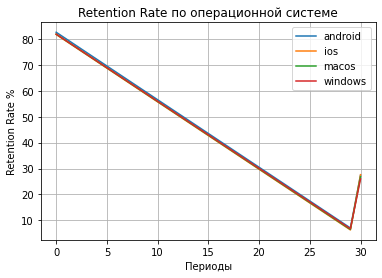

In [115]:
table1 = df_funnel_step_os.groupby('os')['user_id'].nunique().reset_index()
table1.rename(columns={'user_id':'total_user_count'}, inplace=True)

table2 =  df_funnel_step_os.groupby(['os', 'diff_days'])['user_id'].nunique().reset_index()
table2.rename(columns={'user_id':'period_user_count'}, inplace=True)


table_merged = pd.merge(table2, table1, how='left', on='os')
table_merged['retention'] = 100*(table_merged['period_user_count']/table_merged['total_user_count'])


for platform in table_merged['os'].unique():
    # для каждой os по оси X покажем номера периодов (diff_days), а по оси Y — значение Retention
    plt.plot(
        table_merged[table_merged['os'] == platform]['diff_days'],
        table_merged[table_merged['os'] == platform]['retention']
    )

# добавим название графика, легенду, подписи осей и сетку
plt.title('Retention Rate по операционной системе')
plt.legend(table_merged['os'].unique())
plt.xlabel('Периоды')
plt.ylabel('Retention Rate %')
plt.grid()
plt.show()

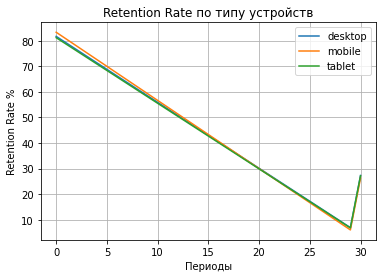

In [116]:
table1 = df_funnel_step_os.groupby('device')['user_id'].nunique().reset_index()
table1.rename(columns={'user_id':'total_user_count'}, inplace=True)

table2 =  df_funnel_step_os.groupby(['device', 'diff_days'])['user_id'].nunique().reset_index()
table2.rename(columns={'user_id':'period_user_count'}, inplace=True)


table_merged = pd.merge(table2, table1, how='left', on='device')
table_merged['retention'] = 100*(table_merged['period_user_count']/table_merged['total_user_count'])


for platform in table_merged['device'].unique():
    # для каждого device по оси X покажем номера периодов (diff_days), а по оси Y — значение Retention
    plt.plot(
        table_merged[table_merged['device'] == platform]['diff_days'],
        table_merged[table_merged['device'] == platform]['retention']
    )

# добавим название графика, легенду, подписи осей и сетку
plt.title('Retention Rate по типу устройств')
plt.legend(table_merged['device'].unique())
plt.xlabel('Периоды')
plt.ylabel('Retention Rate %')
plt.grid()
plt.show()

Наблюдается удержание падения по всем типам устройств и операционным системам.

In [117]:
# Создаем пустой словарь для хранения результатов по каждой ОС
os_funnels_dict = {}

# Запуск цикла по всем уникальным операционным системам в данных
for os_name in df_funnel_step_os['os'].unique():
    
    # Фильтр данных по ОС 
    df_os = df_funnel_step_os[df_funnel_step_os['os'] == os_name].copy()
    
    # Подсчет уникальных пользователей на каждом шаге
    df_os_steps = (
        df_os.groupby('event_type')['user_id']
        .nunique()
        .reindex(funnel_steps)
        .reset_index(name='users_n')
    )
           
    # Расчет конверсии от первого шага 
    df_os_steps['conversion_from_first_%'] = round(
        (df_os_steps['users_n'] / df_os_steps.loc[0, 'users_n'] * 100), 2
    )
    
    # Расчет пошаговой конверсии (step-by-step) 
    df_os_steps['conversion_from_previous_%'] = round(
        (df_os_steps['users_n'] / df_os_steps['users_n'].shift(1) * 100), 2
    )
       
    # Добавление колонки с именем ОС, чтобы в итоговой таблице было понятно, чья это воронка
    df_os_steps['os'] = os_name
    
    # Сохранение агрегированного датафрейма в словарь
    os_funnels_dict[os_name] = df_os_steps
    
# Соединение рассчитанные воронки 
df_final_funnel = pd.concat(os_funnels_dict.values(), ignore_index=True)

# Вывод результата на экран
df_final_funnel

,event_type,users_n,conversion_from_first_%,conversion_from_previous_%,os
0,page_view,4027.0,100.00,NaN,ios
1,product_view,4022.0,99.88,99.88,ios
2,add_to_cart,3646.0,90.54,90.65,ios
3,checkout_start,2944.0,73.11,80.75,ios
4,checkout_complete,2203.0,54.71,74.83,ios
5,purchase,NaN,NaN,NaN,ios
6,page_view,4088.0,100.00,NaN,windows
7,product_view,4080.0,99.80,99.80,windows
8,add_to_cart,3732.0,91.29,91.47,windows
9,checkout_start,2964.0,72.50,79.42,windows


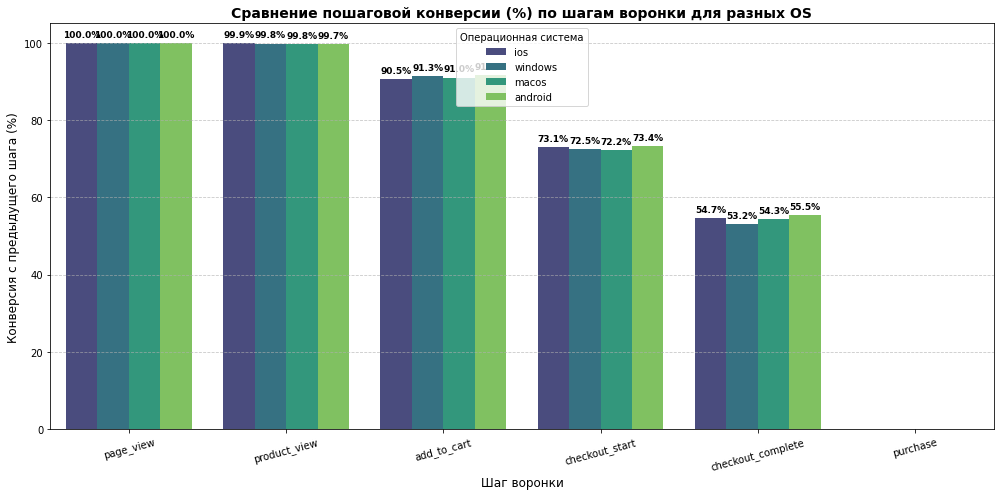

In [118]:
plt.figure(figsize=(14, 7))

# Столбчатая диаграмма для пошаговой конверсии
ax = sns.barplot(
    data=df_final_funnel,
    x='event_type',
    y='conversion_from_first_%',
    hue='os',            
    palette='viridis'    
)

# Оформление
plt.title('Сравнение пошаговой конверсии (%) по шагам воронки для разных OS', fontsize=14, fontweight='bold')
plt.xlabel('Шаг воронки', fontsize=12)
plt.ylabel('Конверсия с предыдущего шага (%)', fontsize=12)
plt.xticks(rotation=15) 
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.legend(title='Операционная система')

current_rects = [rect for rect in ax.get_children() if isinstance(rect, plt.Rectangle)][:-1]

# Сортировка столбиков по их реальной координате X на экране (слева направо)
current_rects = sorted(current_rects, key=lambda r: r.get_x())

# Отсортированные столбики текущего графика
for rect in current_rects:
    v = rect.get_height()
    x = rect.get_x() + rect.get_width() / 2  # Точный центр текущего столбика  
    
    if 0 < v <= 100:
        plt.text(x, v + 1, f"{v:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

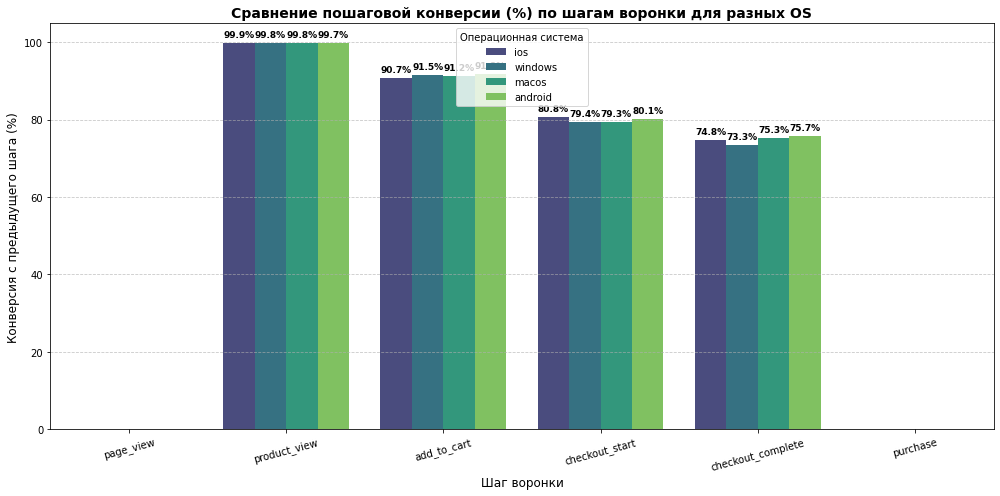

In [119]:
plt.figure(figsize=(14, 7))

# Столбчатая диаграмма для пошаговой конверсии
ax = sns.barplot(
    data=df_final_funnel,
    x='event_type',
    y='conversion_from_previous_%',
    hue='os',            # Разделение по цветам для разных ОС
    palette='viridis'    # Цветовая схема
)

# Оформление
plt.title('Сравнение пошаговой конверсии (%) по шагам воронки для разных OS', fontsize=14, fontweight='bold')
plt.xlabel('Шаг воронки', fontsize=12)
plt.ylabel('Конверсия с предыдущего шага (%)', fontsize=12)
plt.xticks(rotation=15) 
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.legend(title='Операционная система')

current_rects = [rect for rect in ax.get_children() if isinstance(rect, plt.Rectangle)][:-1]

# Сортировка столбиков по их реальной координате X на экране (слева направо)
current_rects = sorted(current_rects, key=lambda r: r.get_x())

# Отсортированные столбики текущего графика
for rect in current_rects:
    v = rect.get_height()
    x = rect.get_x() + rect.get_width() / 2  # Точный центр текущего столбика  
    
    if 0 < v <= 100:
        plt.text(x, v + 1, f"{v:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

По операционной системе по воронкам не выявило значимых расхождений. Падение конверсии наблюдается на всех системах.

In [120]:
# Пустой словарь для хранения результатов по каждому устройству
device_funnels_dict = {}

# Запуск цикла по всем уникальным устройствам в данных
for device_name in df_funnel_step_os['device'].unique():
    
    # Фильтр данных по текущему устройству и явная копия
    df_device = df_funnel_step_os[df_funnel_step_os['device'] == device_name].copy()
    
    # Подсчет уникальных пользователей на каждом шаге
    df_device_steps = (
        df_device.groupby('event_type')['user_id']
        .nunique()
        .reindex(funnel_steps)
        .reset_index(name='users_n')
    )
           
    # Подсчет конверсии от первого шага 
    df_device_steps['conversion_from_first_%'] = round(
        (df_device_steps['users_n'] / df_device_steps.loc[0, 'users_n'] * 100), 2
    )
    
    # Расчет пошаговой конверсии (step-by-step) 
    df_device_steps['conversion_from_previous_%'] = round(
        (df_device_steps['users_n'] / df_device_steps['users_n'].shift(1) * 100), 2
    )
       
    # Добавление колонки с названием девайса, чтобы в итоговой таблице было понятно, чья это воронка
    df_device_steps['device'] = device_name
    
    # Сохранение агрегированного датафрейма в словарь
    device_funnels_dict[device_name] = df_device_steps
    
# Соединение рассчитанных воронок вместе
df_final_funnel_device = pd.concat(device_funnels_dict.values(), ignore_index=True)

# Вывод результата на экран
df_final_funnel_device

,event_type,users_n,conversion_from_first_%,conversion_from_previous_%,device
0,page_view,5412.0,100.00,NaN,mobile
1,product_view,5398.0,99.74,99.74,mobile
2,add_to_cart,4928.0,91.06,91.29,mobile
3,checkout_start,3891.0,71.90,78.96,mobile
4,checkout_complete,2867.0,52.97,73.68,mobile
5,purchase,NaN,NaN,NaN,mobile
6,page_view,5415.0,100.00,NaN,desktop
7,product_view,5405.0,99.82,99.82,desktop
8,add_to_cart,4926.0,90.97,91.14,desktop
9,checkout_start,3999.0,73.85,81.18,desktop


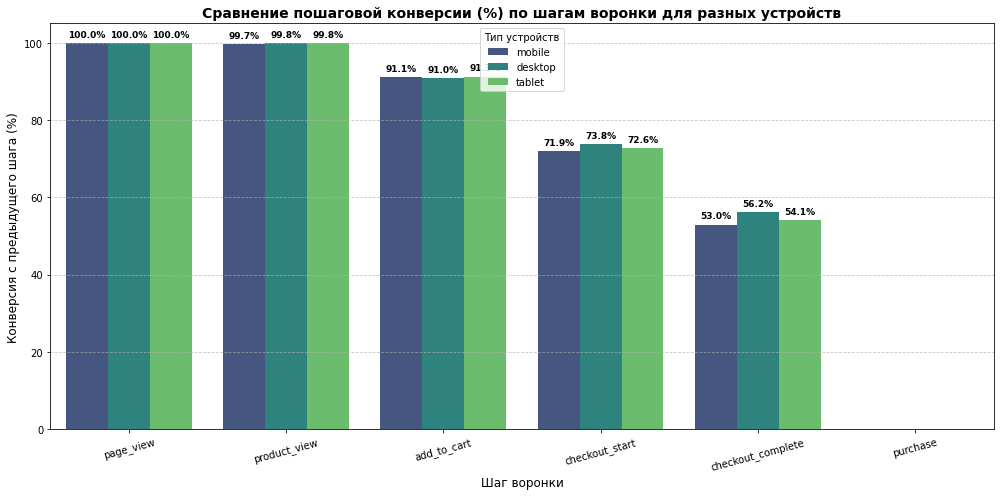

In [121]:
plt.figure(figsize=(14, 7))

# Столбчатая диаграмма для пошаговой конверсии
ax = sns.barplot(
    data=df_final_funnel_device,
    x='event_type',
    y='conversion_from_first_%',
    hue='device',            
    palette='viridis'    
)

# Оформление
plt.title('Сравнение пошаговой конверсии (%) по шагам воронки для разных устройств', fontsize=14, fontweight='bold')
plt.xlabel('Шаг воронки', fontsize=12)
plt.ylabel('Конверсия с предыдущего шага (%)', fontsize=12)
plt.xticks(rotation=15) 
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.legend(title='Тип устройств')

current_rects = [rect for rect in ax.get_children() if isinstance(rect, plt.Rectangle)][:-1]

# Сортировка столбиков по их реальной координате X на экране (слева направо)
current_rects = sorted(current_rects, key=lambda r: r.get_x())

# Отсортированные столбики текущего графика
for rect in current_rects:
    v = rect.get_height()
    x = rect.get_x() + rect.get_width() / 2  # Точный центр текущего столбика  
    
    if 0 < v <= 100:
        plt.text(x, v + 1, f"{v:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

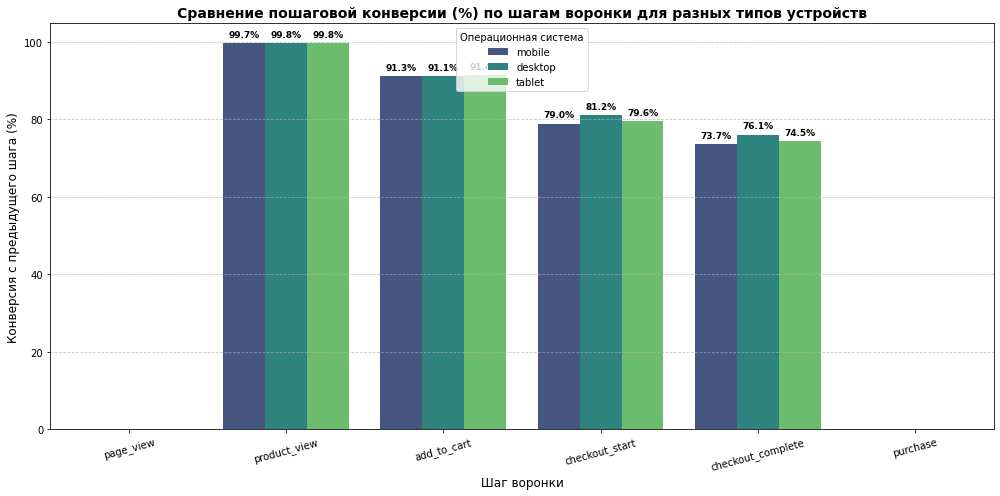

In [122]:
plt.figure(figsize=(14, 7))

# Столбчатая диаграмма для пошаговой конверсии
ax = sns.barplot(
    data=df_final_funnel_device,
    x='event_type',
    y='conversion_from_previous_%',
    hue='device',            
    palette='viridis'   
)

# Оформление
plt.title('Сравнение пошаговой конверсии (%) по шагам воронки для разных типов устройств', fontsize=14, fontweight='bold')
plt.xlabel('Шаг воронки', fontsize=12)
plt.ylabel('Конверсия с предыдущего шага (%)', fontsize=12)
plt.xticks(rotation=15) 
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.legend(title='Операционная система')

current_rects = [rect for rect in ax.get_children() if isinstance(rect, plt.Rectangle)][:-1]

# Сортировка столбиков по их реальной координате X на экране (слева направо)
current_rects = sorted(current_rects, key=lambda r: r.get_x())

# Отсортированные столбики текущего графика
for rect in current_rects:
    v = rect.get_height()
    x = rect.get_x() + rect.get_width() / 2  # Точный центр текущего столбика  
    
    if 0 < v <= 100:
        plt.text(x, v + 1, f"{v:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

По типу устройства воронка показала ухушение устройства мобильного по сравнению с другими.

In [123]:
df_page_views = events_filtr[events_filtr['event_type'] == 'page_view'] 
# 2. Оставляем только уникальных пользователей, чтобы строки в заказах не размножались
user_devices = df_page_views[['user_id', 'os', 'device']].drop_duplicates(subset=['user_id'])
orders_filtr = orders_filtr.merge(user_devices, on='user_id', how='left')
orders_filtr=orders_filtr.merge(users[['user_id','cohort_month']], on='user_id', how='left')
orders_filtr.head()

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month,unit_revenue,total_revenue,os,device,cohort_month
0,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01,276.96,553.91,android,mobile,2024-01-01
1,2,3,2024-01-19 01:52:52,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01,567.02,567.02,android,mobile,2024-01-01
2,3,3,2024-01-19 01:52:52,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01,544.60,1089.21,android,mobile,2024-01-01
3,4,3,2024-01-25 13:59:38,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-22,2024-01-01,276.96,553.91,android,mobile,2024-01-01
4,5,3,2024-01-25 13:59:38,Чай черный,1,2099.59,2099.59,Продукты питания,2024-01-22,2024-01-01,104.98,104.98,android,mobile,2024-01-01


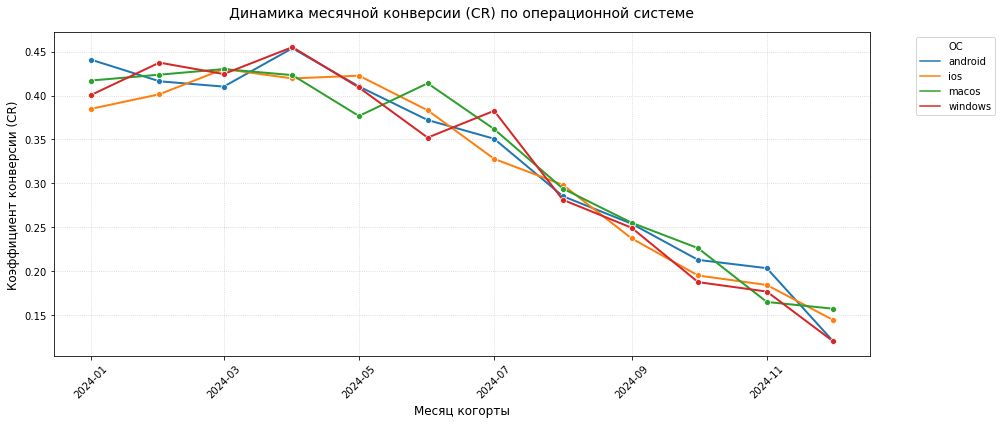

In [124]:
events_new = events_filtr.merge(users[['user_id','cohort_month']], on='user_id', how='left')
activ_df_os = events_new.groupby(['os', 'cohort_month'])['user_id'].nunique().reset_index(name='activ_user')

pay_df_os = orders_filtr[orders_filtr['total_revenue'] > 0].groupby(['os', 'cohort_month'])['user_id'].nunique().reset_index(name='pay_user')


df_conversion_os = activ_df_os.merge(pay_df_os, on=['os', 'cohort_month'], how='left')
df_conversion_os['CR'] = df_conversion_os['pay_user']/df_conversion_os['activ_user']

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=df_conversion_os,
    x='cohort_month',
    y='CR',
    hue='os',
    marker='o',
    linewidth=2
)

# 4. Настраиваем оформление
plt.title('Динамика месячной конверсии (CR) по операционной системе', fontsize=14, pad=15)
plt.xlabel('Месяц когорты', fontsize=12)
plt.ylabel('Коэффициент конверсии (CR)', fontsize=12)

# Поворачиваем даты на оси X, чтобы они не сливались
plt.xticks(rotation=45)
plt.grid(True, linestyle=':', alpha=0.6)

# 5. Выносим легенду вправо, чтобы она не перекрывала линии графика
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='ОС')

# Автоматически корректируем отступы
plt.tight_layout()
plt.show()

Все платформы показывают спад, подтверждается системный характер падения. 

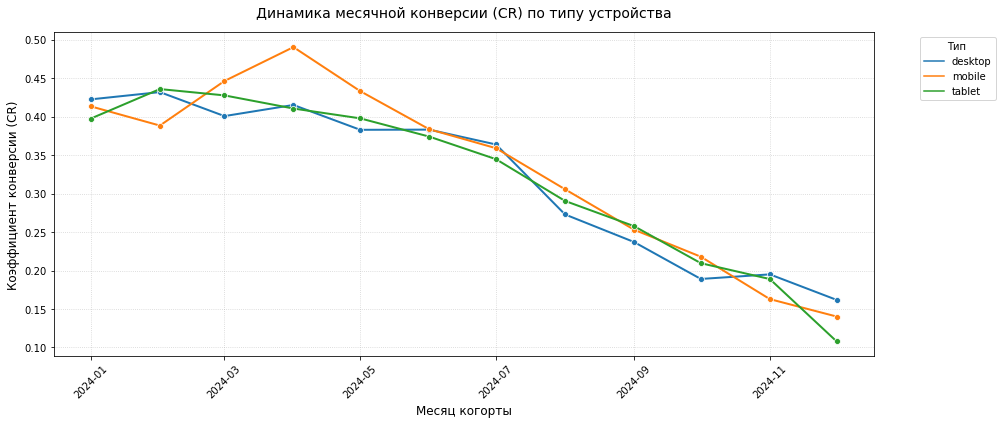

In [125]:
activ_df_device = events_new.groupby(['device', 'cohort_month'])['user_id'].nunique().reset_index(name='activ_user')

pay_df_device = orders_filtr[orders_filtr['total_revenue'] > 0].groupby(['device', 'cohort_month'])['user_id'].nunique().reset_index(name='pay_user')


df_conversion_device = activ_df_device.merge(pay_df_device, on=['device', 'cohort_month'], how='left')
df_conversion_device['CR'] = df_conversion_device['pay_user']/df_conversion_device['activ_user']

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=df_conversion_device,
    x='cohort_month',
    y='CR',
    hue='device',
    marker='o',
    linewidth=2
)

# 4. Настраиваем оформление
plt.title('Динамика месячной конверсии (CR) по типу устройства', fontsize=14, pad=15)
plt.xlabel('Месяц когорты', fontsize=12)
plt.ylabel('Коэффициент конверсии (CR)', fontsize=12)

# Поворачиваем даты на оси X, чтобы они не сливались
plt.xticks(rotation=45)
plt.grid(True, linestyle=':', alpha=0.6)

# 5. Выносим легенду вправо, чтобы она не перекрывала линии графика
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Тип ')

# Автоматически корректируем отступы
plt.tight_layout()
plt.show()

Все типы устройств показывают также снижение конверсии.

## 7. Вывод

- Кто приходит – приток пользователей рос до июня, а затем начал снижаться. 
- Кто остаётся – regular в январе на второй месяц оставалось 58%, а у once – только 12%. После июня удержание падает у всех сегментов.
- Кто платит – регулярные покупатели (regular) платят чаще и больше, а одноразовые (once) приносят мало выручки.
- Кто уходит – падение retention уже на 2-3 месяцы жизни когорт, особенно у once и rare, у поздних когорт (октябрь–декабрь) отток происходит ещё быстрее.

1. Какие сегменты работают лучше остальных

Лучше всех работают регулярные покупатели `regular`:
· Наибольшая выручка: ARPU в первый месяц жизни когорты достигал до 1090 руб. (в первом полугодии), а накопленный LTV за 6 месяцев > 2500 руб.
· Высокая конверсия на всех этапах воронки.
· Удержание у regular выше, чем у других сегментов (хотя и падает к концу года).
· Положительная юнит-экономика (LTV > CAC).

На втором месте – средние покупатели `medium`: их ARPU (до 175 руб. в первые месяцы) и LTV (~ 500 руб.) ниже `regular`.

2. Какие сегменты работают хуже остальных

Хуже всех – одноразовые покупатели `one_time`:
· ARPU в первый месяц – до 22 руб., накопленный LTV близок к нулю.
· Конверсия в добавление в корзину и начало оформления крайне низкая.
· Удержание на третий месяц падает до 0%.
· Этот сегмент убыточен (LTV << CAC) и не окупает затраты на привлечение.

Почти так же хуже – редкие покупатели `rare`:
· ARPU до 53 руб., LTV < 200 руб.
· Удержание низкое, большинство не совершают третью покупку.
· Также убыточны.

Средние покупатели `medium` находятся на грани окупаемости, но тоже вносят небольшой положительный вклад.

3. На каких этапах воронки теряются пользователи

· На этапе «добавление в корзину → начало оформления» – потери наиболее заметны у `one_time` и `rare`. 
· На этапе «завершение оформления → оплата» –  падение у `regular` и `medium`. 
· На этапе «просмотр → добавление в корзину» – также значительные потери у `one_time`. 

4. Какие группы можно и нужно масштабировать

Масштабировать – регулярных покупателей `regular` необходимо увеличивать их долю среди всех пользователей. 
Для этого нужно:
· Конвертировать `one_time` → `rare` → `medium` → `regular` через программы лояльности, напоминания о брошенной корзине, скидки за повторные покупки.
· Улучшать удержание существующих `regular` (сейчас оно падает).

Хорошо бы масштабировать – средних покупателей `medium`, они находятся близко к `regular` и при небольшом стимулировании (бонус за 5-ю покупку) могут перейти в `regular`.

5. Куда стоит инвестировать больше внимания и ресурсов

- Улучшение финального этапа оплаты – самый быстрый способ повысить конверсию (особенно у `regular` и `medium`). 
- Программы стимулирования повторных покупок – для конвертации `one_time` в `rare`, `rare` в `medium`, `medium` в `regular`. Еmail/push-кампании, промокоды, кешбэк.
- Оптимизация этапа «корзина → оформление» – показывать итоговую стоимость сразу.


Гипотезы

Гипотеза 1.Увеличение частоты покупок через программу лояльности с накопительными бонусами приведет к восстановлению Retention и увеличению. ARPU и Retention упали, регулярные пользователи перестали возвращаться.

Гипотеза 2. Автоматический промокод на второй заказ увеличит конверсию `one_time` в `rare` в 3 раза. Сильное падение Retention. Не заинтересованность пользователей во второй покупке.


В связи с тем,что было замечено с июня доля TikTok в бюджете резко выросла, при этом низкий ARPU и конверсия минимальны, Google Ads и Affiliate, наоборот, имеют выше показатели, но бюджет Google Ads упал после июля, в связи с прекращением его деятельности в РФ. 

# Новые вводные (после этапа 4)
Команда продукта рассмотрела твои гипотезы и на основании этого решила влиять на конверсию при помощи финансовых стимуляций. Так как ситуация со снижением выручки срочная и безотлагательная, пока ты продолжал изучать данные, они подключили другого аналитика для подготовки дизайн документа, но само проведение эксперимента на тебе.


При формировании выводов допиши рекомендации по итогам теста и, если необходимо, опиши проблемы, присутствующие в эксперименте.


## Новые данные:
```python
pa_marketplace_events_AB = pd.read_csv('______')
pa_marketplace_orders_AB = pd.read_csv('______')
pa_marketplace_users_AB = pd.read_csv('_______')
```
## Результаты сплита лежат в таблице:
```python
pa_marketplace_AB_split_users = pd.read_csv('______')
```
* user_id – id клиента
* group – группа, в которую попал клиент


# Дизайн эксперимента: Бонус на первую покупку для пользователей TikTok
## 1. Контекст и цель эксперимента
- **Бизнес-контекст:** Команда продукта запускает эксперимент, направленный на повышение конверсии среди пользователей, привлечённых через канал TikTok. Для стимулирования первой покупки пользователям будет предоставлен бонус на первую покупку.
- **Цель:** Проверить, влияет ли предоставление бонуса на первую покупку на конверсию и выручку среди пользователей TikTok.
- **Гипотеза:** Предоставление бонуса на первую покупку новым пользователям, привлеченным через TikTok, приведет к увеличению конверсии в первую покупку
---
## 2. Формат эксперимента
- **Тип эксперимента:** Сплит-роллинг (rolling split)
- **Канал:** Только пользователи, пришедшие с TikTok
- **Группы:**
    - **Контрольная (A):** пользователи TikTok без бонуса
    - **Тестовая (B):** пользователи TikTok с бонусом на первую покупку
- **Распределение:** Равномерное распределение новых пользователей TikTok между группами по дате регистрации
- **Период проведения:** 3 недели (фиксировано)
---
## 3. Ключевые метрики
### Основная метрика
- **Конверсия в первую покупку** - доля пользователей, зарегистрировавшихся с TikTok и совершивших первую покупку
- *Цель:* увеличить конверсию с помощью бонуса
- *Критерий успеха:* статистически значимый рост конверсии в тестовой группе
### Вспомогательные метрики
- **ARPU** (средняя выручка на пользователя TikTok)
- **ARPPU** (средняя выручка на покупателя TikTok)
- **AOV** (средний чек TikTok)
### Барьерная метрика
- **Общая выручка от пользователей TikTok**
---
## 4. Размеры групп и запуск
- **Целевая аудитория:** только пользователи TikTok
- **Размеры групп:** определяются по фактическому трафику TikTok за период эксперимента
- **Комментарий:** запуск без предварительного расчёта мощности и MDE из-за срочности задачи


In [126]:
# Считывание данных из CSV-файла
event_test = pd.read_csv('_____', parse_dates=['event_date', 'event_week', 'event_month'])
order_test = pd.read_csv('_____', parse_dates=['order_date', 'order_week', 'order_month'])
user_test = pd.read_csv('______', parse_dates=['registration_date', 'cohort_week', 'cohort_month'])
split_uers = pd.read_csv('_____')

In [127]:
order_test['revenue'] = order_test['total_price'] * 0.05

In [128]:
#Проверка пересечения двух тестов
intersection = split_uers.groupby('user_id').agg({'group':'nunique'}).query('group > 1').index
intersection

Int64Index([], dtype='int64', name='user_id')

Пересечение не найдено между группами.

In [129]:
user_test_group = pd.merge(user_test, split_uers, on='user_id', how='inner')
# Применение функции для знакомства с orders
# data_overview(user_test_group)

Таблица `user_test_group` содержит данные о пользователях с 01-01-2025 по 26-01-2025гг, канал привелечения TikTok, группы `control`, `treatment`. Сложности теста могут быть из-за начала теста в дни новогодних праздников, каникул. Это нужно будет учесть в выводе.

In [130]:
event_test_group = pd.merge(event_test, split_uers, on='user_id', how='inner')
# Применение функции для знакомства с orders
# data_overview(event_test_group)

In [131]:
order_test_group = pd.merge(order_test, split_uers, on='user_id', how='inner')
# Применение функции для знакомства с orders
# data_overview(order_test_group)

In [132]:
#равномерность распределения пользователей по группам теста
test_group_interface = user_test_group.groupby('group')['user_id'].nunique().reset_index()
pA = test_group_interface.loc[test_group_interface['group'] == 'control', 'user_id'].nunique()
pB = test_group_interface.loc[test_group_interface['group'] == 'treatment', 'user_id'].nunique()

p = ((pA - pB) / pA) * 100
display(f'Процентная разница в количестве пользователей в группах A и B: {p}')

'Процентная разница в количестве пользователей в группах A и B: 0.0'

Пользователи распределены равномерно. Нужно рассмотреть выбросы для выбора тестов.

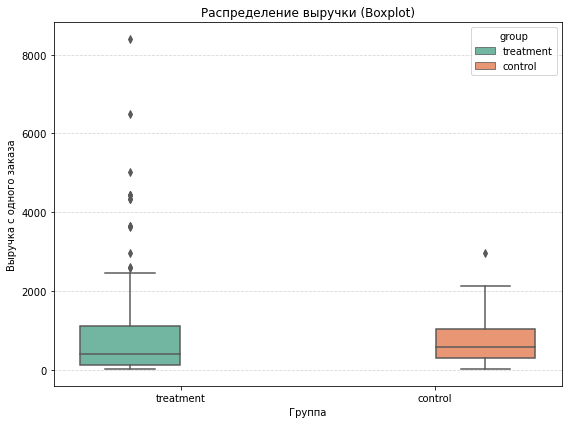

In [133]:
plt.figure(figsize=(8, 6))

# Боксплот по исходным заказам
sns.boxplot(
    data=order_test_group, 
    x='group', 
    y='revenue', 
    hue='group', 
    palette='Set2'
)

plt.title('Распределение выручки (Boxplot)')
plt.xlabel('Группа')
plt.ylabel('Выручка с одного заказа')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Убираем легенду
ax.get_legend().remove()

plt.tight_layout()
plt.show()

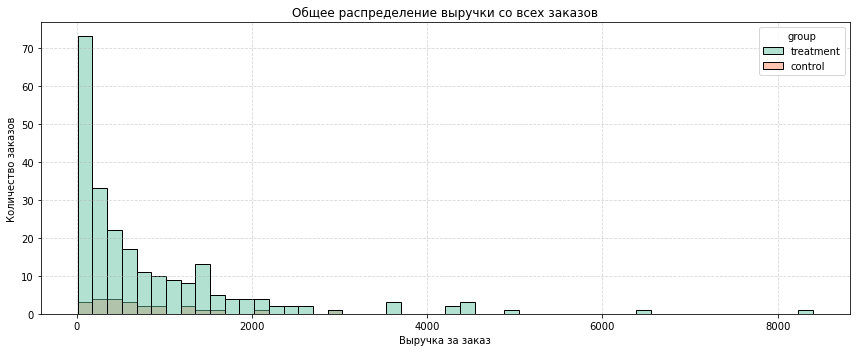

In [134]:
plt.figure(figsize=(12, 5))

sns.histplot(
    data=order_test_group, 
    x='revenue', 
    hue='group', 
    bins=50, 
    palette='Set2', 
    multiple='layer'
)

plt.title('Общее распределение выручки со всех заказов')
plt.xlabel('Выручка за заказ')
plt.ylabel('Количество заказов')
plt.grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Графики показывают наличие экстремальных выбросов в тестовой группе. Выбросы нельзя удалять для отражения поведения пользователей. 
- для ключевой метрики конверсии буду использовать z-test;
- для расчетов ARPPU, AOV буду использовать тест Манна-Уитни, чтобы результат не искажался из-за больших выбросов;
- для расчета ARPU, общей выручки бутстрап.

### 1. Ключевая метрика

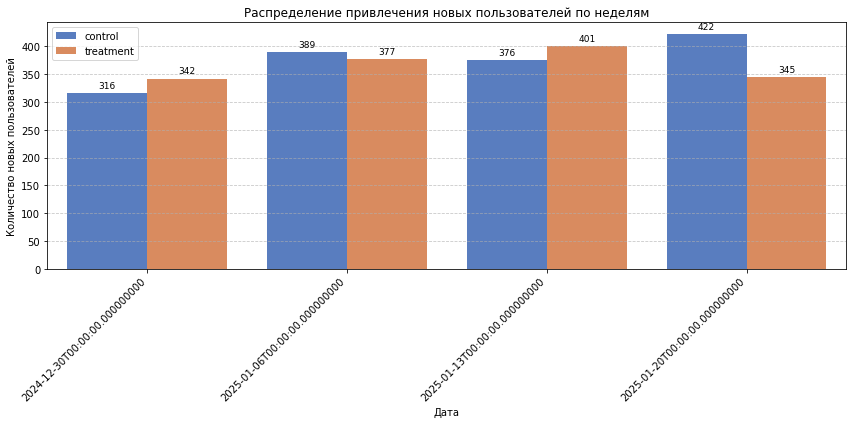

In [135]:
# Построение графика
daily_users = user_test_group.groupby(['cohort_week', 'group'])['user_id'].nunique().reset_index()

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=daily_users, 
    x='cohort_week', 
    y='user_id', 
    hue='group',
    palette='muted' 
)
# Подписи над каждым столбиком
for container in ax.containers:
    ax.bar_label(
        container, 
        padding=3,          
        fontsize=9,         
        rotation=0          
    )
plt.title('Распределение привлечения новых пользователей по неделям')
plt.xlabel('Дата')
plt.ylabel('Количество новых пользователей')

plt.xticks(rotation=45, ha='right') 
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

Видно привлечение хорошее по каналу TikTok по неделям. 

In [136]:
#Зарегистрированные пользователи
reg_users = user_test_group.groupby('group')['user_id'].nunique().reset_index(name='reg_users')
# Пользователи, совершившие первый заказ
first_orders = order_test_group.groupby(['group', 'user_id'])['order_date'].min().reset_index()
buy_users = first_orders.groupby('group')['user_id'].nunique().reset_index(name='buy_users')
buy_users
#Объединение таблиц для CR
coversion_test = pd.merge(reg_users, buy_users, on='group', how='left')
coversion_test['CR'] = coversion_test['buy_users']/coversion_test['reg_users'] *100
coversion_test

,group,reg_users,buy_users,CR
0,control,1503,16,1.064538
1,treatment,1465,110,7.508532


In [137]:
order_test_group['user_id'].nunique()

126

Гипотезы: Ho (нулевая гипотеза) - доля пользователей, зарегистрировавшихся с TikTok и совершивших первую покупку,то есть конверсия в первую покупку в контрольной и тестовой группах не различается или различие не статистически значимые между тестовой и контрольной группами. p_value > alpha. Н1 (альтернативная гипотеза) - конверсия в первую покупку различается между тестовой и контрольной группами. p_value < alpha. alpha=0,05.

In [138]:
# Расчет конверсий
conv_control = coversion_test[coversion_test['group']=='control']['CR'].values[0]
conv_test = coversion_test[coversion_test['group']=='treatment']['CR'].values[0]
dep_test = coversion_test[coversion_test['group']=='treatment']['buy_users'].values[0]
dep_control = coversion_test[coversion_test['group']=='control']['buy_users'].values[0]
reg_test = coversion_test[coversion_test['group']=='treatment']['reg_users'].values[0]
reg_control = coversion_test[coversion_test['group']=='control']['reg_users'].values[0]
# Расчет изменений (Lift)
abs_lift = conv_test - conv_control
rel_lift = (conv_test / conv_control - 1) * 100

# Проверка статистической значимости (Z-тест для долей)
# [успехи_тест, успехи_контроль], [всего_тест, всего_контроль]
z_stat, p_value = proportions_ztest([dep_test, dep_control], [reg_test, reg_control])

# Формирование итогового отчета в DataFrame
report_df = pd.DataFrame({
    'Метрика': ['Конверсия Reg-to-Dep (%)'],
    'Control (A)': [round(conv_control, 3)],
    'Test (B)': [round(conv_test, 3)],
    'Absolute Lift (% п.)': [round(abs_lift, 3)],
    'Relative Lift (%)': [round(rel_lift, 2)],
    'p-value': [round(p_value, 5)]
})

print("Итоговые результаты по ключевой метрике:")
display(report_df)

Итоговые результаты по ключевой метрике:


,Метрика,Control (A),Test (B),Absolute Lift (% п.),Relative Lift (%),p-value
0,Конверсия Reg-to-Dep (%),1.065,7.509,6.444,605.33,0.0


Полученное значение p-value меньше стандартного порога значимости (alpha = 0.05) (0% против 5%). Нулевую гипотезу отвергаем. Это означает, что конверсия в первую покупку действительно увеличилась. То что тест проводился в новогодние каникулы, могло повлиять на абсолютное значение, но разница значима.

### 2. Вспомогательные метрики

#### 2.1 ARPPU

Гипотеза: Ho (нулевая гипотеза) - средняя сумма выручки на одного платящего пользователя в контрольной и тестовой группе не различается или различия не статистически значимые между тестовой и контрольной группами. p_value > alpha. Н1 (альтернативная гипотеза) - средняя сумма выручки на одного платящего пользователя различается между тестовой и контрольной группами. p_value < alpha.

In [139]:
#Столбец с нужным типом дата
order_test_group['order_dt'] = pd.to_datetime(order_test_group['order_date']).dt.normalize()

In [140]:
# Подсчет суммы выручки (revenue) для каждого уникального user_id в каждой группе
order_data = order_test_group.groupby(['group', 'user_id'])['revenue'].sum().reset_index()

In [141]:
# Список всех уникальных групп с сортировкой
groups = sorted(order_data['group'].unique())

# Словарь для хранения данных по группам
group_data = {}
for group in groups:
   group_data[group] = order_data[order_data['group'] == group]
    
# Список для хранения результатов
results = []

# Сравнение групп
for i in range(len(groups)):
   for j in range(i + 1, len(groups)):
       group1 = groups[i]
       group2 = groups[j]

       revenue1 = group_data[group1]['revenue'].values
       revenue2 = group_data[group2]['revenue'].values

       # Расчет метрик
       global_ratio = (revenue1.sum() + revenue2.sum()) / (len(revenue1) + len(revenue2))
       lin_metric1 = group_data[group1]['revenue'] - global_ratio * 1
       lin_metric2 = group_data[group2]['revenue'] - global_ratio * 1

       # Статистический тест Манна-Уитни 
       _, p_value = mannwhitneyu(revenue1, revenue2, alternative='two-sided')

        # Расчет медиан, так как среднее на выбросах смотреть нельзя
       median1 = np.median(revenue1)
       median2 = np.median(revenue2)

       # Добавление результатов
       results.append({
           'Group A': group1,
           'Group B': group2,
           'p-value': p_value,
           'Mean A': median1,
           'Mean B': median2,
           'Absolute Lift': median2-median1,
           'Relative Lift (%)': (median2 / median1 - 1) * 100
       })

# DataFrame из результатов
results_df = pd.DataFrame(results)

# Результат
display("Результаты сравнения групп вспомогательной метрики ARPPU:")
display(results_df)

'Результаты сравнения групп вспомогательной метрики ARPPU:'

,Group A,Group B,p-value,Mean A,Mean B,Absolute Lift,Relative Lift (%)
0,control,treatment,0.626078,981.3915,827.559,-153.8325,-15.674937


Полученное значение p-value больше стандартного порога значимости (alpha = 0.05) (62,6% против 5%). Нулевую гипотезу принимаем. Это означает, что средняя сумма выручки на платящего пользователя в контрольной и тестовой группе не различается или различия не статистически значимые.

#### 2.2 ARPU

Гипотеза: Ho (нулевая гипотеза) - средняя сумма выручки на одного пользователя в контрольной и тестовой группе не различается или различия не статистически значимые между тестовой и контрольной группами. p_value > alpha. Н1 (альтернативная гипотеза) - средняя сумма выручки на одного  пользователя различается между тестовой и контрольной группами. p_value < alpha.

In [142]:
activ_test = pd.merge(user_test_group, order_test_group, on=['user_id','group'], how='left')
activ_test.head()

,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month,group,...,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month,revenue,order_dt
0,44965,2025-01-01 18:10:00,66,M,Новосибирск,TikTok,one_time,2024-12-30,2025-01-01,control,...,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaT
1,44967,2025-01-01 11:29:00,70,M,Московская область,TikTok,rare,2024-12-30,2025-01-01,control,...,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaT
2,44968,2025-01-01 13:05:00,68,F,Нижний Новгород,TikTok,regular,2024-12-30,2025-01-01,control,...,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaT
3,44969,2025-01-01 00:23:00,24,F,Краснодар,TikTok,medium,2024-12-30,2025-01-01,treatment,...,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaT
4,44970,2025-01-01 06:33:00,50,M,Санкт-Петербург,TikTok,regular,2024-12-30,2025-01-01,control,...,2025-01-04 23:06:48,Пазл 1000 элементов,3.0,4905.23,14715.69,Детские игрушки,2024-12-30,2025-01-01,735.7845,2025-01-04


In [143]:
activ_test['registration_dt'] = pd.to_datetime(activ_test['registration_date']).dt.normalize()

In [144]:
# Подсчет revenue для каждого уникального user_id в каждой группе
activ_test_data = activ_test.groupby(['group', 'user_id'])['revenue'].sum().reset_index()

In [145]:
groups = sorted(activ_test_data['group'].unique())

group_data = {}
for group in groups:
    group_data[group] = activ_test_data[activ_test_data['group'] == group]

results = []

n_resamples = 1000
rng = np.random.default_rng(42)

# Сравнение групп
for i in range(len(groups)):
    for j in range(i + 1, len(groups)):
        group1 = groups[i]
        group2 = groups[j]

        revenue1 = group_data[group1]['revenue'].values
        revenue2 = group_data[group2]['revenue'].values

        actual_diff = np.mean(revenue2) - np.mean(revenue1)

        # Ручной бутстрап
        boot_diffs = np.empty(n_resamples)
        for b in range(n_resamples):
            sample1 = rng.choice(revenue1, size=len(revenue1), replace=True)
            sample2 = rng.choice(revenue2, size=len(revenue2), replace=True)
            boot_diffs[b] = np.mean(sample2) - np.mean(sample1)

        # p-value: доля подвыборок с знаком, противоположным реальному эффекту
        if actual_diff > 0:
            p_value = 2 * np.mean(boot_diffs <= 0)
        else:
            p_value = 2 * np.mean(boot_diffs >= 0)

        p_value = min(1.0, p_value)

        mean1 = revenue1.mean()
        mean2 = revenue2.mean()

        results.append({
            'Group A': group1,
            'Group B': group2,
            'p-value (Bootstrap)': round(p_value, 4),
            'ARPU A': round(mean1, 2),
            'ARPU B': round(mean2, 2),
            'Absolute Lift': round(mean2 - mean1, 2),
            'Relative Lift (%)': round((mean2 / mean1 - 1) * 100, 2) if mean1 != 0 else 0
        })

results_df = pd.DataFrame(results)

print("Результаты сравнения вспомогательной метрики ARPU методом Бутстрапа:")
display(results_df)


Результаты сравнения вспомогательной метрики ARPU методом Бутстрапа:


,Group A,Group B,p-value (Bootstrap),ARPU A,ARPU B,Absolute Lift,Relative Lift (%)
0,control,treatment,0.0,12.59,131.25,118.66,942.71


Полученное значение p-value меньше стандартного порога значимости (alpha = 0.05) (0% против 5%). Нулевую гипотезу отвергаем. Это означает, что средняя сумма выручки на пользователя увеличилась. 

#### 2.2 AOV

Гипотеза: Ho (нулевая гипотеза) - средний чек в контрольной и тестовой группе не различается или различия не статистически значимые между тестовой и контрольной группами. p_value > alpha. Н1 (альтернативная гипотеза) - средний чек различается между тестовой и контрольной группами. p_value < alpha.

In [146]:
# Список всех уникальных групп с сортировкой
groups = sorted(order_data['group'].unique())

# Словарь для хранения данных по группам
group_data = {}
for group in groups:
   group_data[group] = order_test_group[order_test_group['group'] == group]
    
# Список для хранения результатов
results = []

# Сравнение групп
for i in range(len(groups)):
   for j in range(i + 1, len(groups)):
       group1 = groups[i]
       group2 = groups[j]

       orders1 = group_data[group1]['revenue'].values
       orders2 = group_data[group2]['revenue'].values

       # Расчет метрик
       global_ratio = (orders1.sum() + orders2.sum()) / (len(orders1) + len(orders2))
       lin_metric1 = group_data[group1]['revenue'] - global_ratio * 1
       lin_metric2 = group_data[group2]['revenue'] - global_ratio * 1

       # Статистический тест Манна-Уитни (устойчив к любым выбросам)
       _, p_value = mannwhitneyu(orders1, orders2, alternative='two-sided')

        # Расчет медиан (типичный чек платящего пользователя)
       median1 = np.median(orders1)
       median2 = np.median(orders2)

       # Добавление результатов
       results.append({
           'Group A': group1,
           'Group B': group2,
           'p-value': p_value,
           'Mean A': median1,
           'Mean B': median2,
           'Absolute Lift': median2-median1,
           'Relative Lift (%)': (median2 / median1 - 1) * 100
       })

# DataFrame из результатов
results_df = pd.DataFrame(results)

# Результат
display("Результаты сравнения групп вспомогательной метрики AOV:")
display(results_df)

'Результаты сравнения групп вспомогательной метрики AOV:'

,Group A,Group B,p-value,Mean A,Mean B,Absolute Lift,Relative Lift (%)
0,control,treatment,0.271703,588.445,396.631,-191.814,-32.596759


Значение p_value больше стандартного порога значимости (alpha = 0.05) (27.17% против 5%). Это означает, что принимаем нулевую гипотезу. Средние чеки между группами не различаются или различия не статистически значимые между тестовой и контрольной группами.

### 3. Барьерная метрика. Общая выручка

Но: Общая выручка между группами не различается, интервал включает 0.
Н1: Общая выручка между группами различается, верхняя граница<0 (тестовая группа имеет меньшую выручку), нижня граница >0 (тестовая группа имеет больше выручку).

In [147]:
#Деление на тестовые группы 
pay_control = order_test_group[order_test_group['group']=='control'].groupby('user_id')['revenue'].sum()
pay_test = order_test_group[order_test_group['group']=='treatment'].groupby('user_id')['revenue'].sum()

In [148]:
# Настройки бутстрапа
n_bootstrap = 1000  # Количество подвыборок
percentiles = [25, 50, 75]

# Словари для хранения результатов бутстрапа
boot_diffs = {p: [] for p in percentiles}

# Запуск цикла бутстрапа
np.random.seed(42)  # Для воспроизводимости
for _ in range(n_bootstrap):
    # Генерация случайные подвыборки с возвращением
    sample_control = np.random.choice(pay_control, size=len(pay_control), replace=True)
    sample_test = np.random.choice(pay_test, size=len(pay_test), replace=True)
    
    # Подсчет разницы перцентилей (Test - Control)
    for p in percentiles:
        p_control = np.percentile(sample_control, p)
        p_test = np.percentile(sample_test, p)
        boot_diffs[p].append(p_test - p_control)

# Расчет точечных оценок, CI и p-value
results = []
for p in percentiles:
    diffs = np.array(boot_diffs[p])
    
    # Точечная оценка разницы на исходных данных
    true_diff = np.percentile(pay_test, p) - np.percentile(pay_control, p)
    
    # Квантили для 95% доверительного интервала (2.5% и 97.5%)
    ci_lower = np.percentile(diffs, 2.5)
    ci_upper = np.percentile(diffs, 97.5)
        
    results.append({
        'Перцентиль': f'{p}-й',
        'Исходная разница (B-A)': round(true_diff, 3),
        '95% CI Нижняя граница': round(ci_lower, 3),
        '95% CI Верхняя граница': round(ci_upper, 3)
    })

results_df = pd.DataFrame(results)
print("Результаты бутстрапа для перцентилей барьерной метрики общей выручки:")
display(results_df)

Результаты бутстрапа для перцентилей барьерной метрики общей выручки:


,Перцентиль,Исходная разница (B-A),95% CI Нижняя граница,95% CI Верхняя граница
0,25-й,-427.583,-717.745,-49.699
1,50-й,-153.832,-834.268,489.787
2,75-й,691.772,-380.004,1731.018


- В нижней части распределения 25%  разница отрицательная (-427,6) доверительный интервал весь ниже 0 (-717,7: -49,7). Тестовая группа показывает статистический значимо меньшую выручку, чем конрольная.
- В средней части распределения 50% разница отрицательная (-153,8) доверительный интервал широкий, пересекает 0 (-834: 489,8). Статистически значимого различия в медианной выручке нет. Пользователи в тестовой и контрольной группе не отличаются по выручке.
- В верхней части распределения 75% разница положительная (691,8), но доверительный интервал пересекает 0 (-380: 1731). Статистичеки значимого различия нет. 

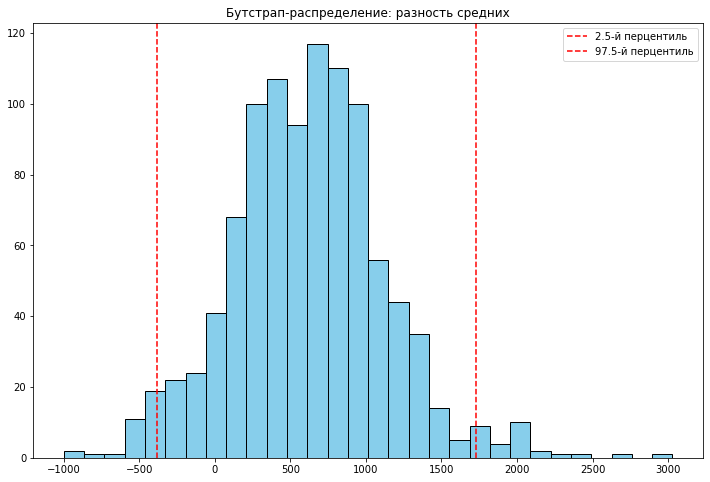

In [149]:
plt.figure(figsize=(12, 8))

# Визуализация
plt.hist(diffs, bins=30, color='skyblue', edgecolor='black')
plt.axvline(ci_lower, color='red', linestyle='--', label='2.5-й перцентиль')
plt.axvline(ci_upper, color='red', linestyle='--', label='97.5-й перцентиль')
plt.title("Бутстрап-распределение: разность средних")
plt.legend()
plt.show()

Разность средних выручки между группами лежит в диапозоне от отрицательной(-500) до положительной (+2000). 0 попадает внутрь интервала, нельзя отвергнуть нулевую гипотезу, разница между группами статистически не значима.

**Вывод** 
- Конверсия и ARPU выросли,
- ARPPU и AOV не значимы статистически,
- разница в общей выручке статистически незначима.

Предоставление бонуса на первую покупку пользователям TikTok привело к статистически значимиму повышению конверсии и ARPU, но не оказало значимого влияния на средний чек, ARPPU и общую выручку. Число платящих выросло, но при этом типичный покупатель в тестовой группе тратит меньше. 
Из-за проведения теста в новогодние каникулы не  полной мере отражает поведение пользователей в обычные месяцы. Рекомендуется повторить тест в нейтральный период для подтверждения устойчивости теста. Но положительная динамика ключевых метрик в такой период свидетельствует о потенциальной эффективности роста. 